# Ookla EDA — Philippines Fixed Broadband & Mobile/Cellular (Combined)

Same structure/methodology as the Thailand combined notebook. Shared setup (geo, province/region reference, GDP/tier context) runs once; Part 1 and Part 2 each run an independent full EDA pass over their own dataset (fixed vs mobile Ookla tiles).

**Data sources:** ADM1 boundaries from geoBoundaries (simplified); population/area/density/GDP per capita from public sources (Wikipedia/PSA/GSO/Singstat) compiled into `data/reference/philippines_reference.csv`. GDP unit: USD, 2023.

Run All top-to-bottom to generate outputs.


### use dataset from this link

# 2023
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=1/2023-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=2/2023-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=3/2023-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=4/2023-10-01_performance_fixed_tiles.parquet

# 2024
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=1/2024-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=2/2024-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=3/2024-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=4/2024-10-01_performance_fixed_tiles.parquet

# 2025
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=1/2025-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=2/2025-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=3/2025-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=4/2025-10-01_performance_fixed_tiles.parquet

### or just place this in cli

```bash
TARGET_DIR="../../data/ookla/raw"
mkdir -p "$TARGET_DIR"

for year in 2023 2024 2025; do
    # Quarter 1 (Jan), Quarter 2 (Apr), Quarter 3 (Jul), Quarter 4 (Oct)
    for q in 1 2 3 4; do
        if [ "$q" -eq 1 ]; then month="01"; fi
        if [ "$q" -eq 2 ]; then month="04"; fi
        if [ "$q" -eq 3 ]; then month="07"; fi
        if [ "$q" -eq 4 ]; then month="10"; fi
        
        URL="https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=${year}/quarter=${q}/${year}-${month}-01_performance_fixed_tiles.parquet"
        echo "Downloading ${year} Q${q}..."
        curl -L "$URL" -o "$TARGET_DIR/${year}-Q${q}_performance_fixed_tiles.parquet"
    done
done
```

### alternative

```bash
aws s3 ls --no-sign-request s3://ookla-open-data/ --recursive
```

### mapping part 

using this as source ```https://github.com/teamookla/ookla-open-data/blob/master/tutorials/python/filter_by_centroids/centroids.ipynb```

In [1]:
# url = "https://raw.githubusercontent.com/apisit/thailand.json/master/thailand.json"

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### load data

In [3]:
    THAILAND_GEOJSON = '../../data/geo/philippines_provinces.geojson'

    PROVINCE_COL = 'name' 

    perf_tiles_url = "../../data/ookla/raw/2023-Q1_performance_fixed_tiles.parquet"

    thailand_provinces_gdf = gpd.read_file(THAILAND_GEOJSON).to_crs(4326)

    # Capture the total bounds of Philippines's boundaries for the bounding box filter
    state_bounds = thailand_provinces_gdf.total_bounds

In [4]:
metric_name = 'avg_d_kbps'

In [5]:
bbox_filters = [('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
                ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0])]

In [6]:
tiles_df = pd.read_parquet(perf_tiles_url,
                           columns=['tile_x', 'tile_y', 'tests', metric_name],
                           filters=bbox_filters
                           )

### Create GeoDataFrame from Centroids

In [7]:
tiles_gdf = gpd.GeoDataFrame(
    tiles_df, 
    geometry=gpd.points_from_xy(tiles_df.tile_x, tiles_df.tile_y), 
    crs="EPSG:4326"
).drop(columns=["tile_x", "tile_y"])

# Drop any rows where we're missing values for the metric
tiles_gdf.dropna(subset=[metric_name], inplace=True)

In [8]:
thailand_tiles_gdf = gpd.sjoin(
    tiles_gdf, 
    thailand_provinces_gdf, 
    how="inner", 
    predicate="intersects"
)[[PROVINCE_COL, 'tests', metric_name]]

In [9]:
# 3. Aggregate the Metric per Province
province_stats = (
    thailand_tiles_gdf.groupby([PROVINCE_COL])
    .apply(
        lambda x: pd.Series(
            {"avg_metric_wt": np.average(x[metric_name], weights=x["tests"])}
        ),
        include_groups=False
    )
    .reset_index()
)

# Convert from kbps to Mbps for standard readability
province_stats['avg_metric_wt_mbps'] = province_stats['avg_metric_wt'] / 1000.0

# 4. Re-merge geometries for mapping
province_data = thailand_provinces_gdf[[PROVINCE_COL, 'geometry']].merge(province_stats, on=PROVINCE_COL)

In [10]:
# 5. Split into buckets and Plot the Map
labels = ["0 to 50", "50 to 100", "100 to 200", "200 to 300", "300+"]
province_data['group'] = pd.cut(
    province_data['avg_metric_wt_mbps'],
    bins=(0, 50, 100, 200, 300, 10000),
    right=False,
    labels=labels
)

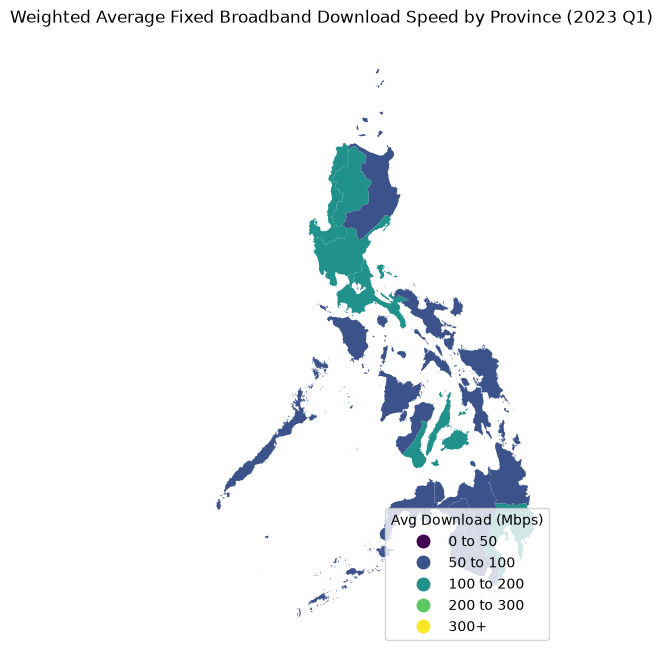

In [11]:
fig, ax = plt.subplots(1, figsize=(10, 8))
province_data.plot("group", ax=ax, legend=True, cmap="viridis", 
                   legend_kwds={'title': "Avg Download (Mbps)", 'loc': 'lower right'})

ax.set_title("Weighted Average Fixed Broadband Download Speed by Province (2023 Q1)")
ax.set_axis_off()

plt.savefig(f'../../outputs/ookla/philippines/08_province_speed_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import pandas as pd
import os

file_path = "../../data/ookla/raw"
files = sorted([f for f in os.listdir(file_path) if f.endswith('.parquet')])
print(f"{len(files)} files, reading first for inspection...")

# Read single file to inspect schema — avoid loading 3.7GB at once
df = pd.read_parquet(os.path.join(file_path, files[0]), engine='pyarrow')

23 files, reading first for inspection...


In [13]:
df.head() 

,quadkey,tile,tile_x,tile_y,avg_d_kbps,avg_u_kbps,avg_lat_ms,avg_lat_down_ms,avg_lat_up_ms,tests,devices
0,0022022300231020,"POLYGON((-178.4619140625 70.9847699889061, -17...",-178.4592,70.9839,87,204,578,3627.0,3312.0,1,1
1,0022133222312322,"POLYGON((-160.02685546875 70.6435894914449, -1...",-160.0241,70.6427,158237,9571,170,517.0,257.0,5,2
2,0022133222330012,"POLYGON((-160.037841796875 70.6399478155463, -...",-160.0351,70.6390,74693,28236,164,590.0,243.0,2,1
3,0022133222330023,"POLYGON((-160.043334960938 70.6363054807905, -...",-160.0406,70.6354,69368,7703,251,546.0,590.0,2,1
4,0022133222330030,"POLYGON((-160.037841796875 70.6381267305321, -...",-160.0351,70.6372,259,260,32,310.0,426.0,1,1


In [14]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6336489 entries, 0 to 6336488
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   quadkey          str    
 1   tile             str    
 2   tile_x           float64
 3   tile_y           float64
 4   avg_d_kbps       int64  
 5   avg_u_kbps       int64  
 6   avg_lat_ms       int64  
 7   avg_lat_down_ms  float64
 8   avg_lat_up_ms    float64
 9   tests            int64  
 10  devices          int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 1.7 GB
None


## Province Reference Data

In [15]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

PROVINCE_REF_PATH = '../../data/reference/philippines_reference.csv'

prov_ref = pd.read_csv(PROVINCE_REF_PATH)
prov_ref['gdp_per_capita_usd_2021'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data

print(f"Provinces loaded: {len(prov_ref)}")
print(f"Regions: {sorted(prov_ref['region'].unique())}")
print()
print(prov_ref[['province_en','region','pop_2024','density_per_km2','gdp_per_capita_thb_2021','internet_tier']].to_string(index=False))


Provinces loaded: 17
Regions: ['Luzon', 'Mindanao', 'Visayas']

        province_en   region  pop_2024  density_per_km2  gdp_per_capita_thb_2021  internet_tier
               ARMM Mindanao   4545486              330                 91028.33              4
       Bicol Region    Luzon   6064426              319                142596.80              4
                CAR    Luzon   1808985               89                295236.64              1
     Cagayan Valley    Luzon   3777608              122                185618.02              3
         Calabarzon    Luzon  16933234              854                259765.51              2
             Caraga Mindanao   2865196              121                187327.47              3
      Central Luzon    Luzon  12989074              510                263326.87              2
    Central Visayas  Visayas   6640875              647                245591.30              2
       Davao Region Mindanao   5389422              245                2

### Population and GDP by Region — Summary

In [16]:
region_summary = (
    prov_ref.groupby('region')
    .agg(
        provinces=('province_en', 'count'),
        total_pop=('pop_2024', 'sum'),
        avg_density=('density_per_km2', 'mean'),
        avg_gdp_per_cap_thb=('gdp_per_capita_thb_2021', 'mean'),
        avg_gdp_per_cap_usd=('gdp_per_capita_usd_2021', 'mean'),
    )
    .sort_values('avg_gdp_per_cap_thb', ascending=False)
    .round(0)
)

region_summary['total_pop_M'] = (region_summary['total_pop'] / 1e6).round(2)
print(region_summary[['provinces','total_pop_M','avg_density','avg_gdp_per_cap_thb','avg_gdp_per_cap_usd']].to_string())


          provinces  total_pop_M  avg_density  avg_gdp_per_cap_thb  avg_gdp_per_cap_usd
region                                                                                 
Luzon             8        64.16       2828.0             284188.0             284188.0
Mindanao          6        27.53        223.0             202606.0             202606.0
Visayas           3        21.03        403.0             196801.0             196801.0


### GDP per Capita vs Population Density — by Region

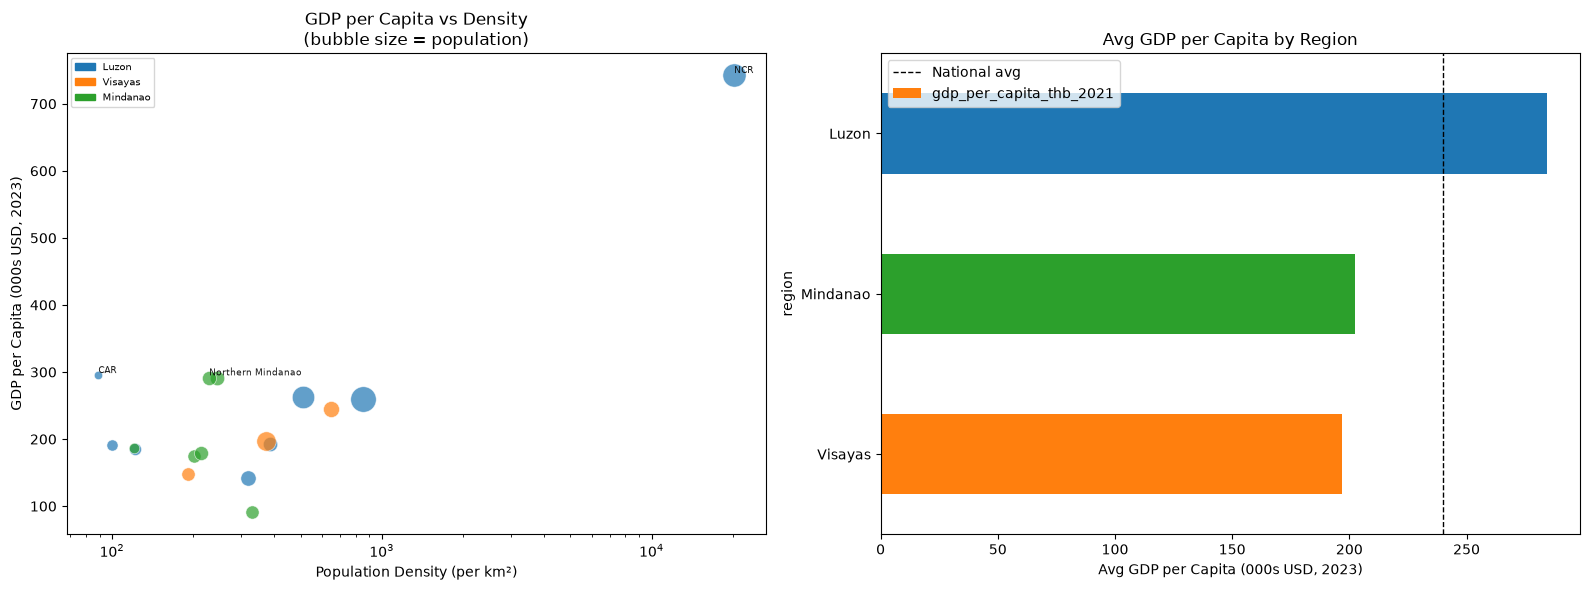

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = {
    'Luzon': '#1f77b4',
    'Visayas': '#ff7f0e',
    'Mindanao': '#2ca02c',
}

for _, row in prov_ref.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000,
                    color=c, alpha=0.7, s=row['pop_2024'] / 50000, edgecolors='white', linewidth=0.5)
    if row['gdp_per_capita_thb_2021'] > prov_ref['gdp_per_capita_thb_2021'].quantile(0.85):
        axes[0].annotate(row['province_en'], (row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000),
                         fontsize=6.5, ha='left', va='bottom', alpha=0.9)

axes[0].set_xlabel('Population Density (per km²)')
axes[0].set_ylabel('GDP per Capita (000s USD, 2023)')
axes[0].set_title('GDP per Capita vs Density\n(bubble size = population)')
axes[0].set_xscale('log')

# Bar chart: avg GDP per region
r_gdp = prov_ref.groupby('region')['gdp_per_capita_thb_2021'].mean().sort_values(ascending=True) / 1000
colors = [region_colors.get(r, 'gray') for r in r_gdp.index]
r_gdp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Avg GDP per Capita (000s USD, 2023)')
axes[1].set_title('Avg GDP per Capita by Region')
axes[1].axvline(prov_ref['gdp_per_capita_thb_2021'].mean() / 1000, color='black', linestyle='--', linewidth=1, label='National avg')
axes[1].legend()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
axes[0].legend(handles=patches, fontsize=7, loc='upper left')

plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/09_gdp_vs_density.png', dpi=150, bbox_inches='tight')
plt.show()


### Internet Tier Distribution — Assumptions Map

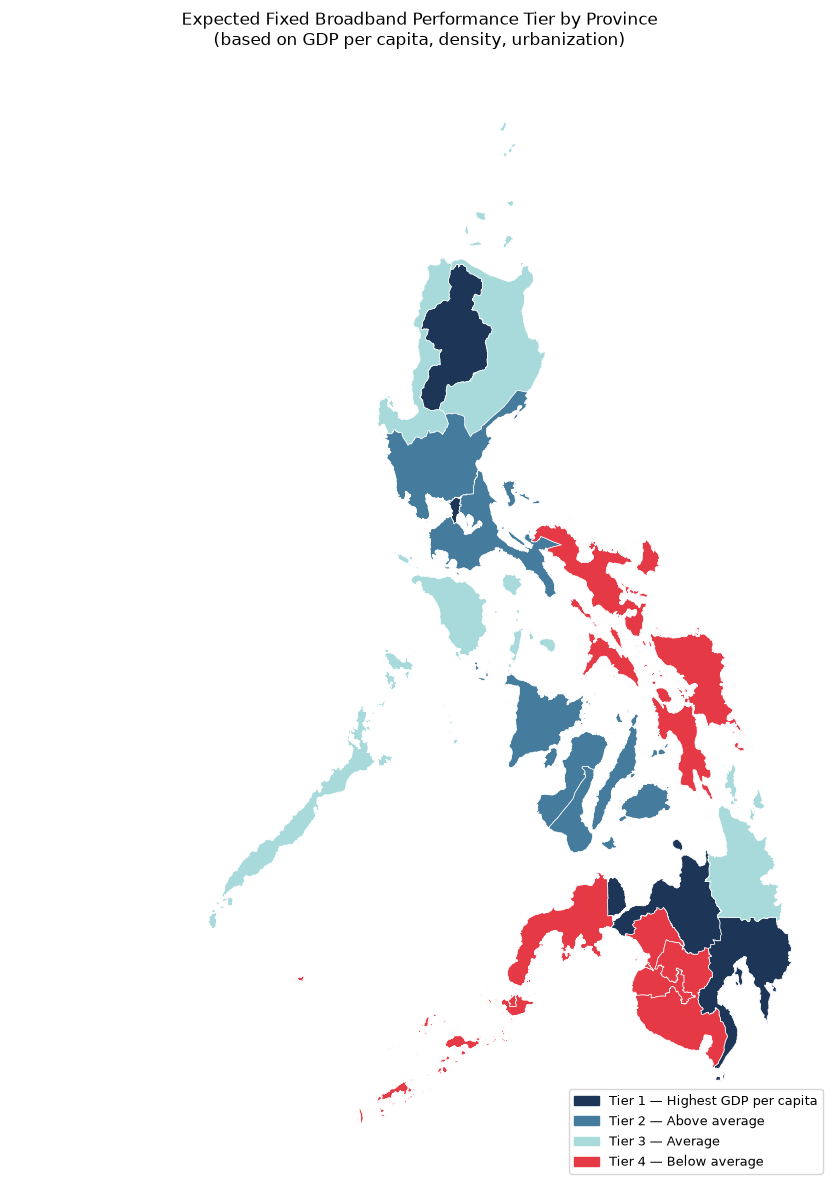

In [18]:
THAILAND_GEOJSON = '../../data/geo/philippines_provinces.geojson'
thailand_gdf = gpd.read_file(THAILAND_GEOJSON).to_crs(4326)

# Merge — GeoJSON uses 'name' column
tier_map = prov_ref[['province_en','internet_tier','gdp_per_capita_thb_2021','region']].copy()

# Manual name alignment between GeoJSON and our CSV
name_map = {}  # no manual alignment needed: geojson 'name' already matches reference csv

geo_with_tier = thailand_gdf.merge(
    tier_map.rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

missing = geo_with_tier[geo_with_tier['internet_tier'].isna()]['name'].tolist()
if missing:
    print("Unmatched provinces (need manual fix):", missing)

tier_colors = {1: '#1d3557', 2: '#457b9d', 3: '#a8dadc', 4: '#e63946'}
geo_with_tier['tier_color'] = geo_with_tier['internet_tier'].map(tier_colors)

fig, ax = plt.subplots(1, figsize=(10, 12))
geo_with_tier.plot(color=geo_with_tier['tier_color'].fillna('lightgray'), ax=ax, edgecolor='white', linewidth=0.5)

patches = [
    mpatches.Patch(color='#1d3557', label='Tier 1 — Highest GDP per capita'),
    mpatches.Patch(color='#457b9d', label='Tier 2 — Above average'),
    mpatches.Patch(color='#a8dadc', label='Tier 3 — Average'),
    mpatches.Patch(color='#e63946', label='Tier 4 — Below average'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Expected Fixed Broadband Performance Tier by Province\n(based on GDP per capita, density, urbanization)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/10_tier_speed_expected.png', dpi=150, bbox_inches='tight')
plt.show()


### Top & Bottom Provinces by GDP per Capita — with Internet Tier

In [19]:
top10 = prov_ref.nlargest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]
bot10 = prov_ref.nsmallest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]

print("=== TOP 10 by GDP per Capita ===")
print(top10.to_string(index=False))
print()
print("=== BOTTOM 10 by GDP per Capita ===")
print(bot10.to_string(index=False))


=== TOP 10 by GDP per Capita ===
      province_en   region  pop_2024  gdp_per_capita_thb_2021  internet_tier
              NCR    Luzon  14001751                742614.53              1
              CAR    Luzon   1808985                295236.64              1
Northern Mindanao Mindanao   5178326                291746.51              1
     Davao Region Mindanao   5389422                290535.65              1
    Central Luzon    Luzon  12989074                263326.87              2
       Calabarzon    Luzon  16933234                259765.51              2
  Central Visayas  Visayas   6640875                245591.30              2
  Western Visayas  Visayas   9766855                196943.14              2
    Ilocos Region    Luzon   5342453                193453.01              3
         Mimaropa    Luzon   3245446                190888.83              3

=== BOTTOM 10 by GDP per Capita ===
        province_en   region  pop_2024  gdp_per_capita_thb_2021  internet_tier
    

---
# Part 1 — Fixed Broadband


## Full EDA — Ookla Fixed Broadband, Philippines (2023 Q1 – 2025 Q4)

### 1. Load & Aggregate All Quarters

In [20]:
import glob, os, warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

DATASET_DIR = '../../data/ookla/raw'
GEOJSON     = '../../data/geo/philippines_provinces.geojson'
PROV_REF    = '../../data/reference/philippines_reference.csv'

# Ookla S3 filename convention: {YEAR}-{MM}-01_performance_fixed_tiles.parquet
# Q1=January(01), Q2=April(04), Q3=July(07), Q4=October(10)
Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)
state_bounds = thailand_gdf.total_bounds
bbox_filters = [
    ('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
    ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0]),
]

COLS = ['tile_x','tile_y','tests','devices','avg_d_kbps','avg_u_kbps','avg_lat_ms']

records = []
files = sorted(glob.glob(os.path.join(DATASET_DIR, '*fixed_tiles*.parquet')))

for fp in files:
    fname   = os.path.basename(fp)
    year    = int(fname[:4])
    quarter = int(fname[6])
    month   = Q_TO_MONTH[quarter]
    # period_start mirrors Ookla's original filename date (first day of the quarter)
    period_start = pd.Timestamp(year=year, month=month, day=1)
    label   = f"{year}-Q{quarter}"

    raw = pd.read_parquet(fp, columns=COLS, filters=bbox_filters)

    tiles_gdf = gpd.GeoDataFrame(
        raw,
        geometry=gpd.points_from_xy(raw.tile_x, raw.tile_y),
        crs='EPSG:4326'
    ).drop(columns=['tile_x','tile_y'])

    joined = gpd.sjoin(tiles_gdf, thailand_gdf[['name','geometry']], how='inner', predicate='intersects')

    agg = (
        joined.groupby('name')
        .apply(lambda g: pd.Series({
            'avg_d_kbps_wt': np.average(g['avg_d_kbps'], weights=g['tests']),
            'avg_u_kbps_wt': np.average(g['avg_u_kbps'], weights=g['tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms'], weights=g['tests']),
            'total_tests'  : g['tests'].sum(),
            'total_devices': g['devices'].sum(),
            'n_tiles'      : len(g),
        }), include_groups=False)
        .reset_index()
    )
    agg['year']         = year
    agg['quarter']      = quarter
    agg['month']        = month
    agg['period_start'] = period_start   # datetime: 2023-01-01, 2023-04-01, ...
    agg['label']        = label
    records.append(agg)
    print(f"  {label} ({period_start.date()}): {len(raw):>8,} raw tiles → {len(agg)} provinces")

master = pd.concat(records, ignore_index=True)
master['avg_d_mbps'] = master['avg_d_kbps_wt'] / 1000
master['avg_u_mbps'] = master['avg_u_kbps_wt'] / 1000
master.drop(columns=['avg_d_kbps_wt','avg_u_kbps_wt'], inplace=True)

# Merge province reference
prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data
master = master.merge(prov_ref.rename(columns={'province_en':'name'}), on='name', how='left')

print(f"\nMaster shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} → {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()}")
print(f"\nperiod_start unique values (matches Ookla filename dates):")
for d in sorted(master['period_start'].unique()):
    print(f"  {pd.Timestamp(d).date()}")


  2023-Q1 (2023-01-01):   93,568 raw tiles → 17 provinces


  2023-Q2 (2023-04-01):   99,490 raw tiles → 17 provinces


  2023-Q3 (2023-07-01):  104,641 raw tiles → 17 provinces


  2023-Q4 (2023-10-01):  106,475 raw tiles → 17 provinces


  2024-Q1 (2024-01-01):  113,780 raw tiles → 17 provinces


...

  2024-Q3 (2024-07-01):  115,546 raw tiles → 17 provinces


  2024-Q4 (2024-10-01):  114,020 raw tiles → 17 provinces


  2025-Q1 (2025-01-01):  115,858 raw tiles → 17 provinces


  2025-Q2 (2025-04-01):  126,060 raw tiles → 17 provinces


  2025-Q4 (2025-10-01):  117,177 raw tiles → 17 provinces

Master shape: (187, 22)
Date range: 2023-01-01 → 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q4']
Provinces:  17

period_start unique values (matches Ookla filename dates):
  2023-01-01
  2023-04-01
  2023-07-01
  2023-10-01
  2024-01-01
  2024-04-01
  2024-07-01
  2024-10-01
  2025-01-01
  2025-04-01
  2025-10-01


In [21]:
# Quality flag per province × quarter
# Ookla: >= 100 tests AND >= 5 tiles → sufficient spatial + sample coverage
master['is_reliable'] = (
    (master['total_tests'] >= 100) &
    (master['n_tiles'] >= 5)
)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")

Reliable province-quarters per label:
label
2023-Q1    17
2023-Q2    17
2023-Q3    17
2023-Q4    17
2024-Q1    17
2024-Q2    17
2024-Q3    17
2024-Q4    17
2025-Q1    17
2025-Q2    17
2025-Q4    17

Overall reliable: 187 / 187 (100.0%)


### 2. Data Quality — Coverage per Province

In [22]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows: {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

# Provinces with zero coverage in any quarter
all_provinces = set(thailand_gdf['name'])
all_labels    = set(master['label'].unique())
coverage_pivot = master.pivot_table(index='name', columns='label', values='total_tests', aggfunc='sum')

missing_cells = [(p, q) for p in all_provinces for q in all_labels
                 if p not in coverage_pivot.index or pd.isna(coverage_pivot.loc[p, q])]
if missing_cells:
    print(f"\nMissing province-quarter combos ({len(missing_cells)}):")
    for p, q in missing_cells:
        print(f"  {p} — {q}")
else:
    print(f"\nAll {expected_n} provinces covered in every quarter.")

# Low-test provinces (< 100 tests in any quarter)
low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
if len(low_test):
    print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} cases:")
    print(low_test.to_string(index=False))
else:
    print("\nNo quarters with < 100 tests.")


Expected rows: 187 | Actual: 187 | Missing: 0

All 17 provinces covered in every quarter.

No quarters with < 100 tests.


In [23]:
# Drop unreliable province-quarters before any stats/plots use master downstream
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")

Filtered to reliable province-quarters: 187 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

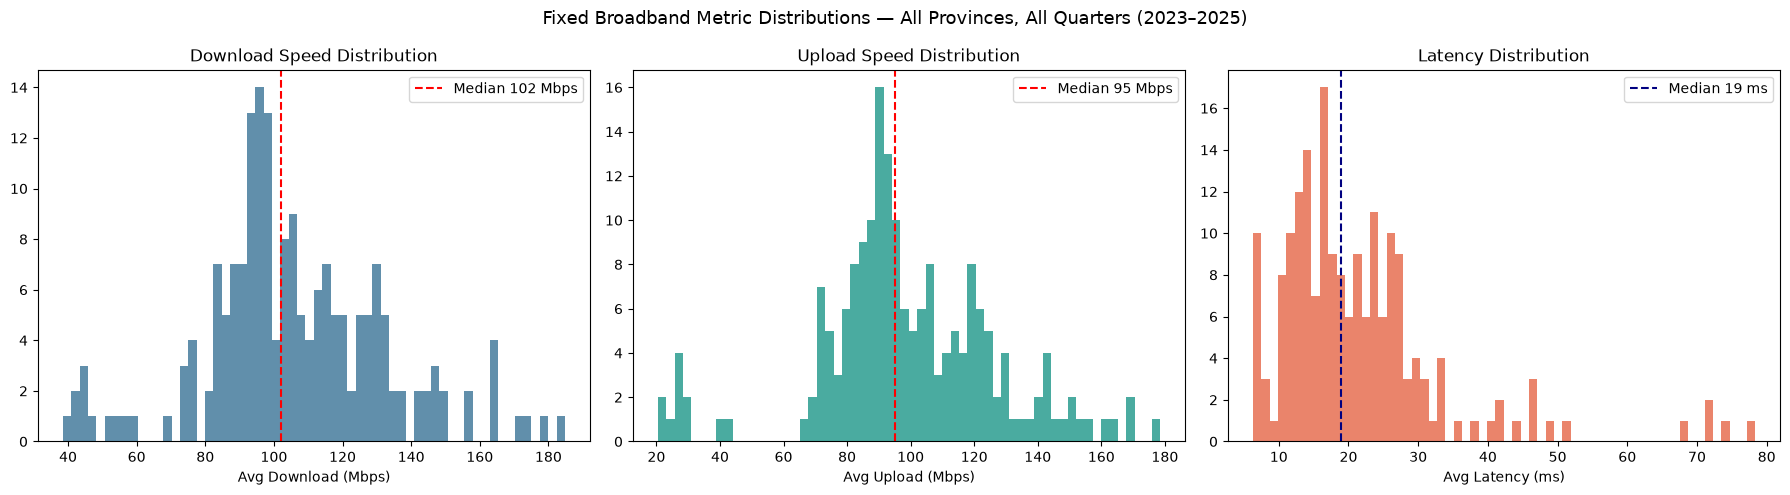

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      187.00      187.00         187.00       187.00
mean       106.08       98.64          21.50    237601.95
std         26.80       28.45          12.33    302594.88
min         38.48       20.44           6.27      9049.00
25%         91.76       85.55          13.56     65486.50
50%        102.18       94.97          18.87    105487.00
75%        121.22      116.38          25.66    217520.50
max        184.80      178.43          78.30   1300587.00


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

plt.suptitle('Fixed Broadband Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))


### 4. Province Ranking — Mean Download Speed (All Quarters)

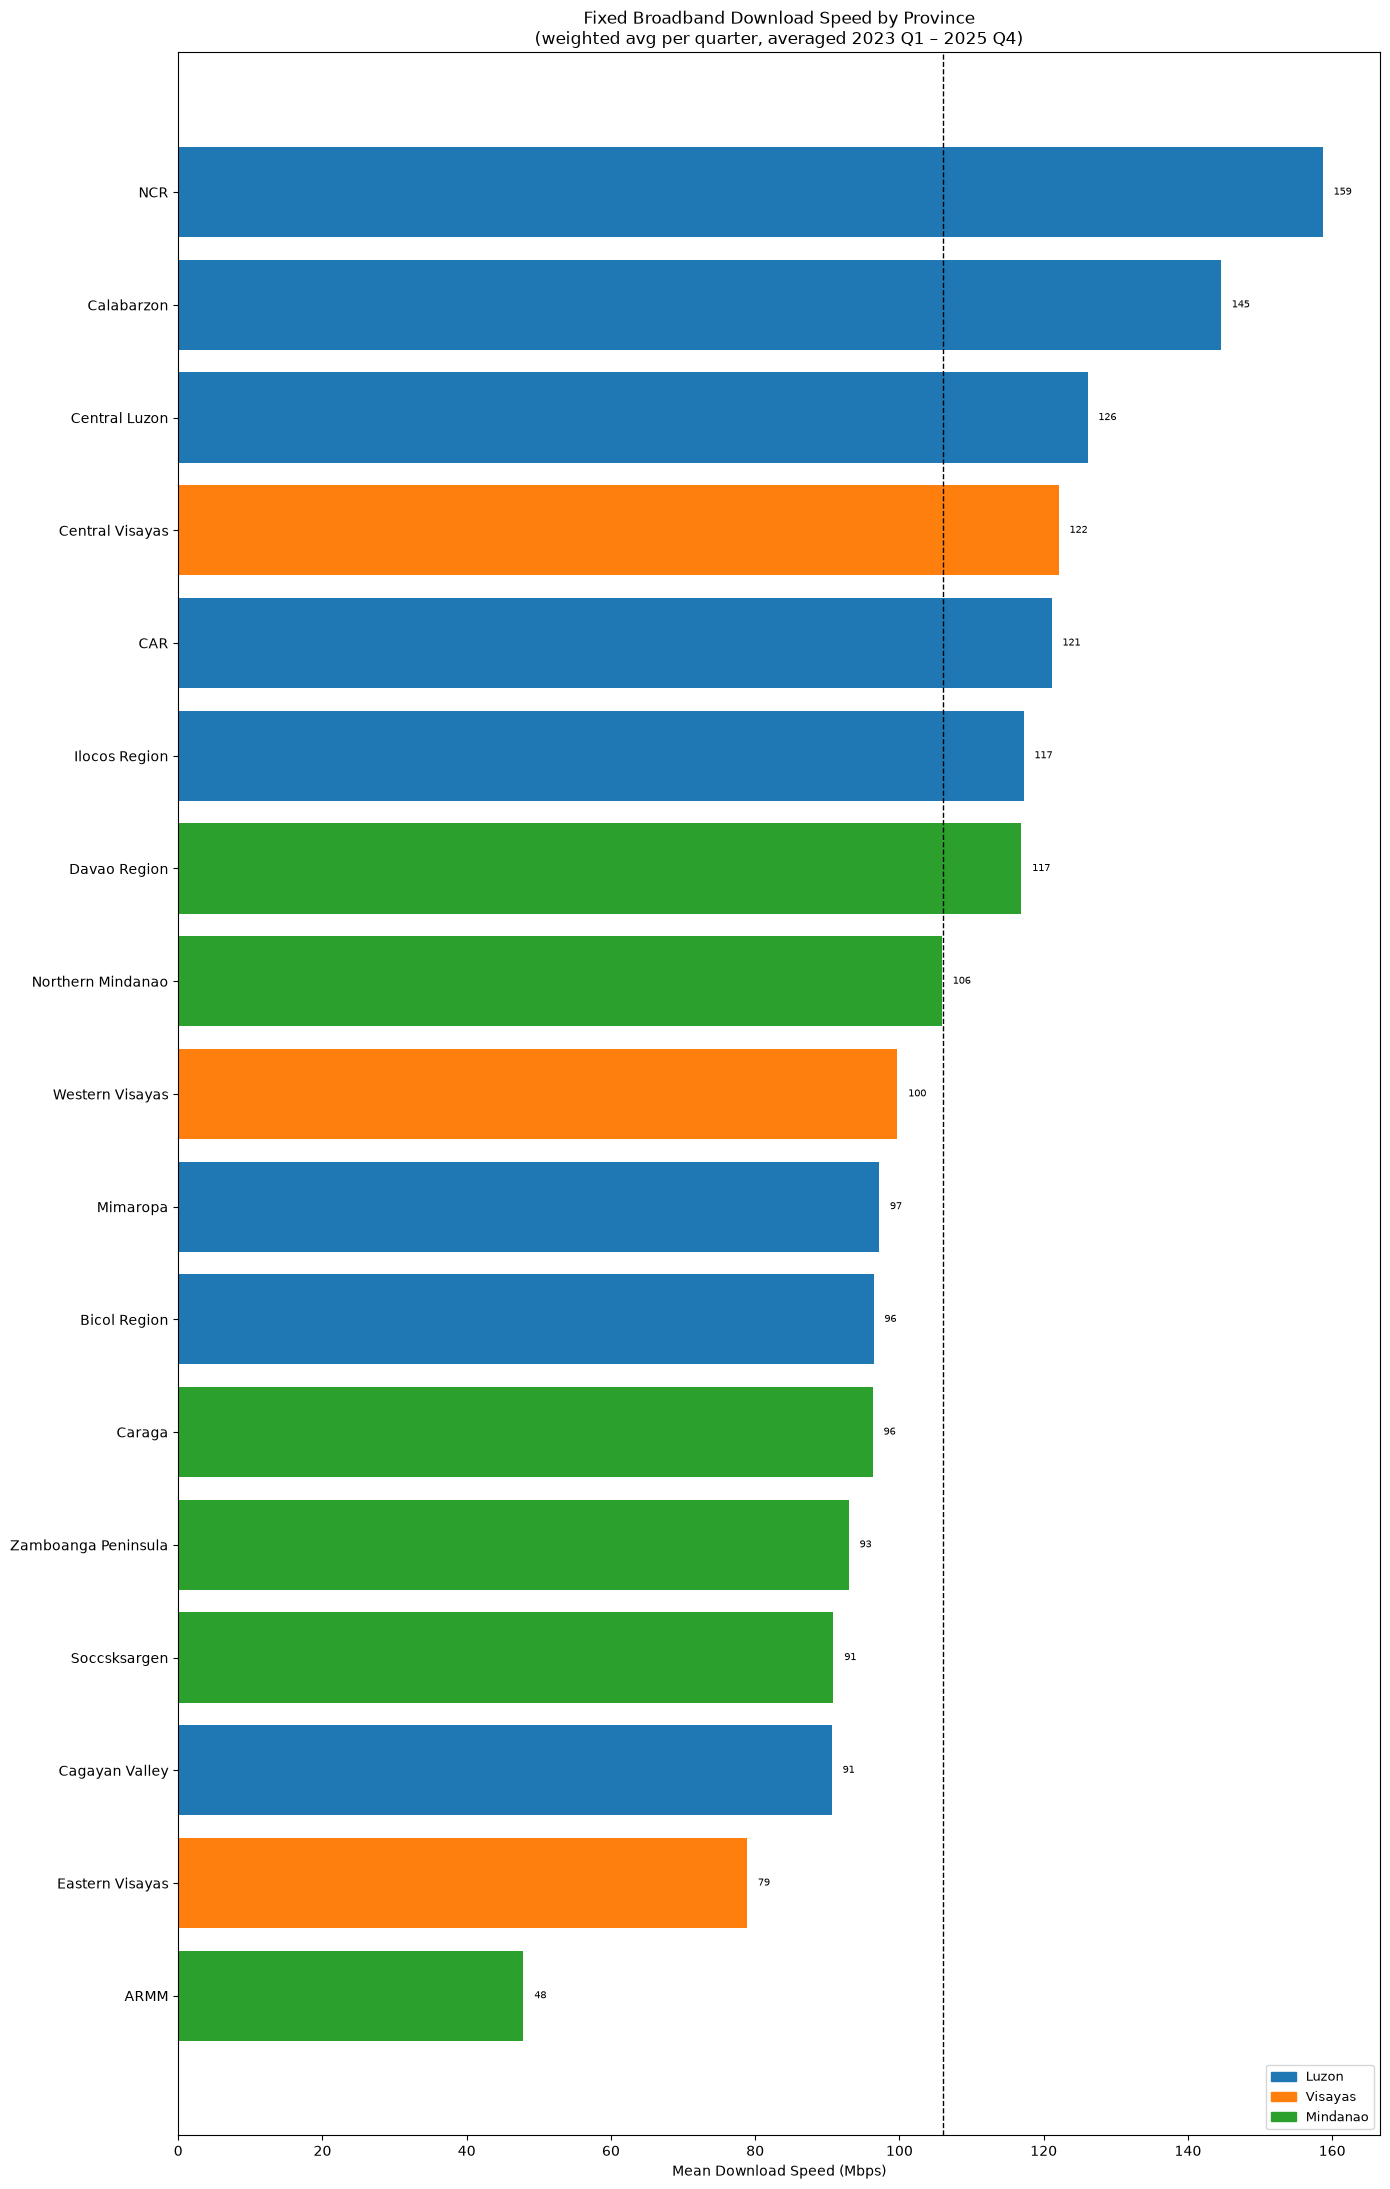

In [25]:
region_colors = {
    'Luzon': '#1f77b4',
    'Visayas': '#ff7f0e',
    'Mindanao': '#2ca02c',
}

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_mean['mean_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('Mean Download Speed (Mbps)')
ax.set_title('Fixed Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.5 Province Ranking — Median Download Speed (All Quarters)

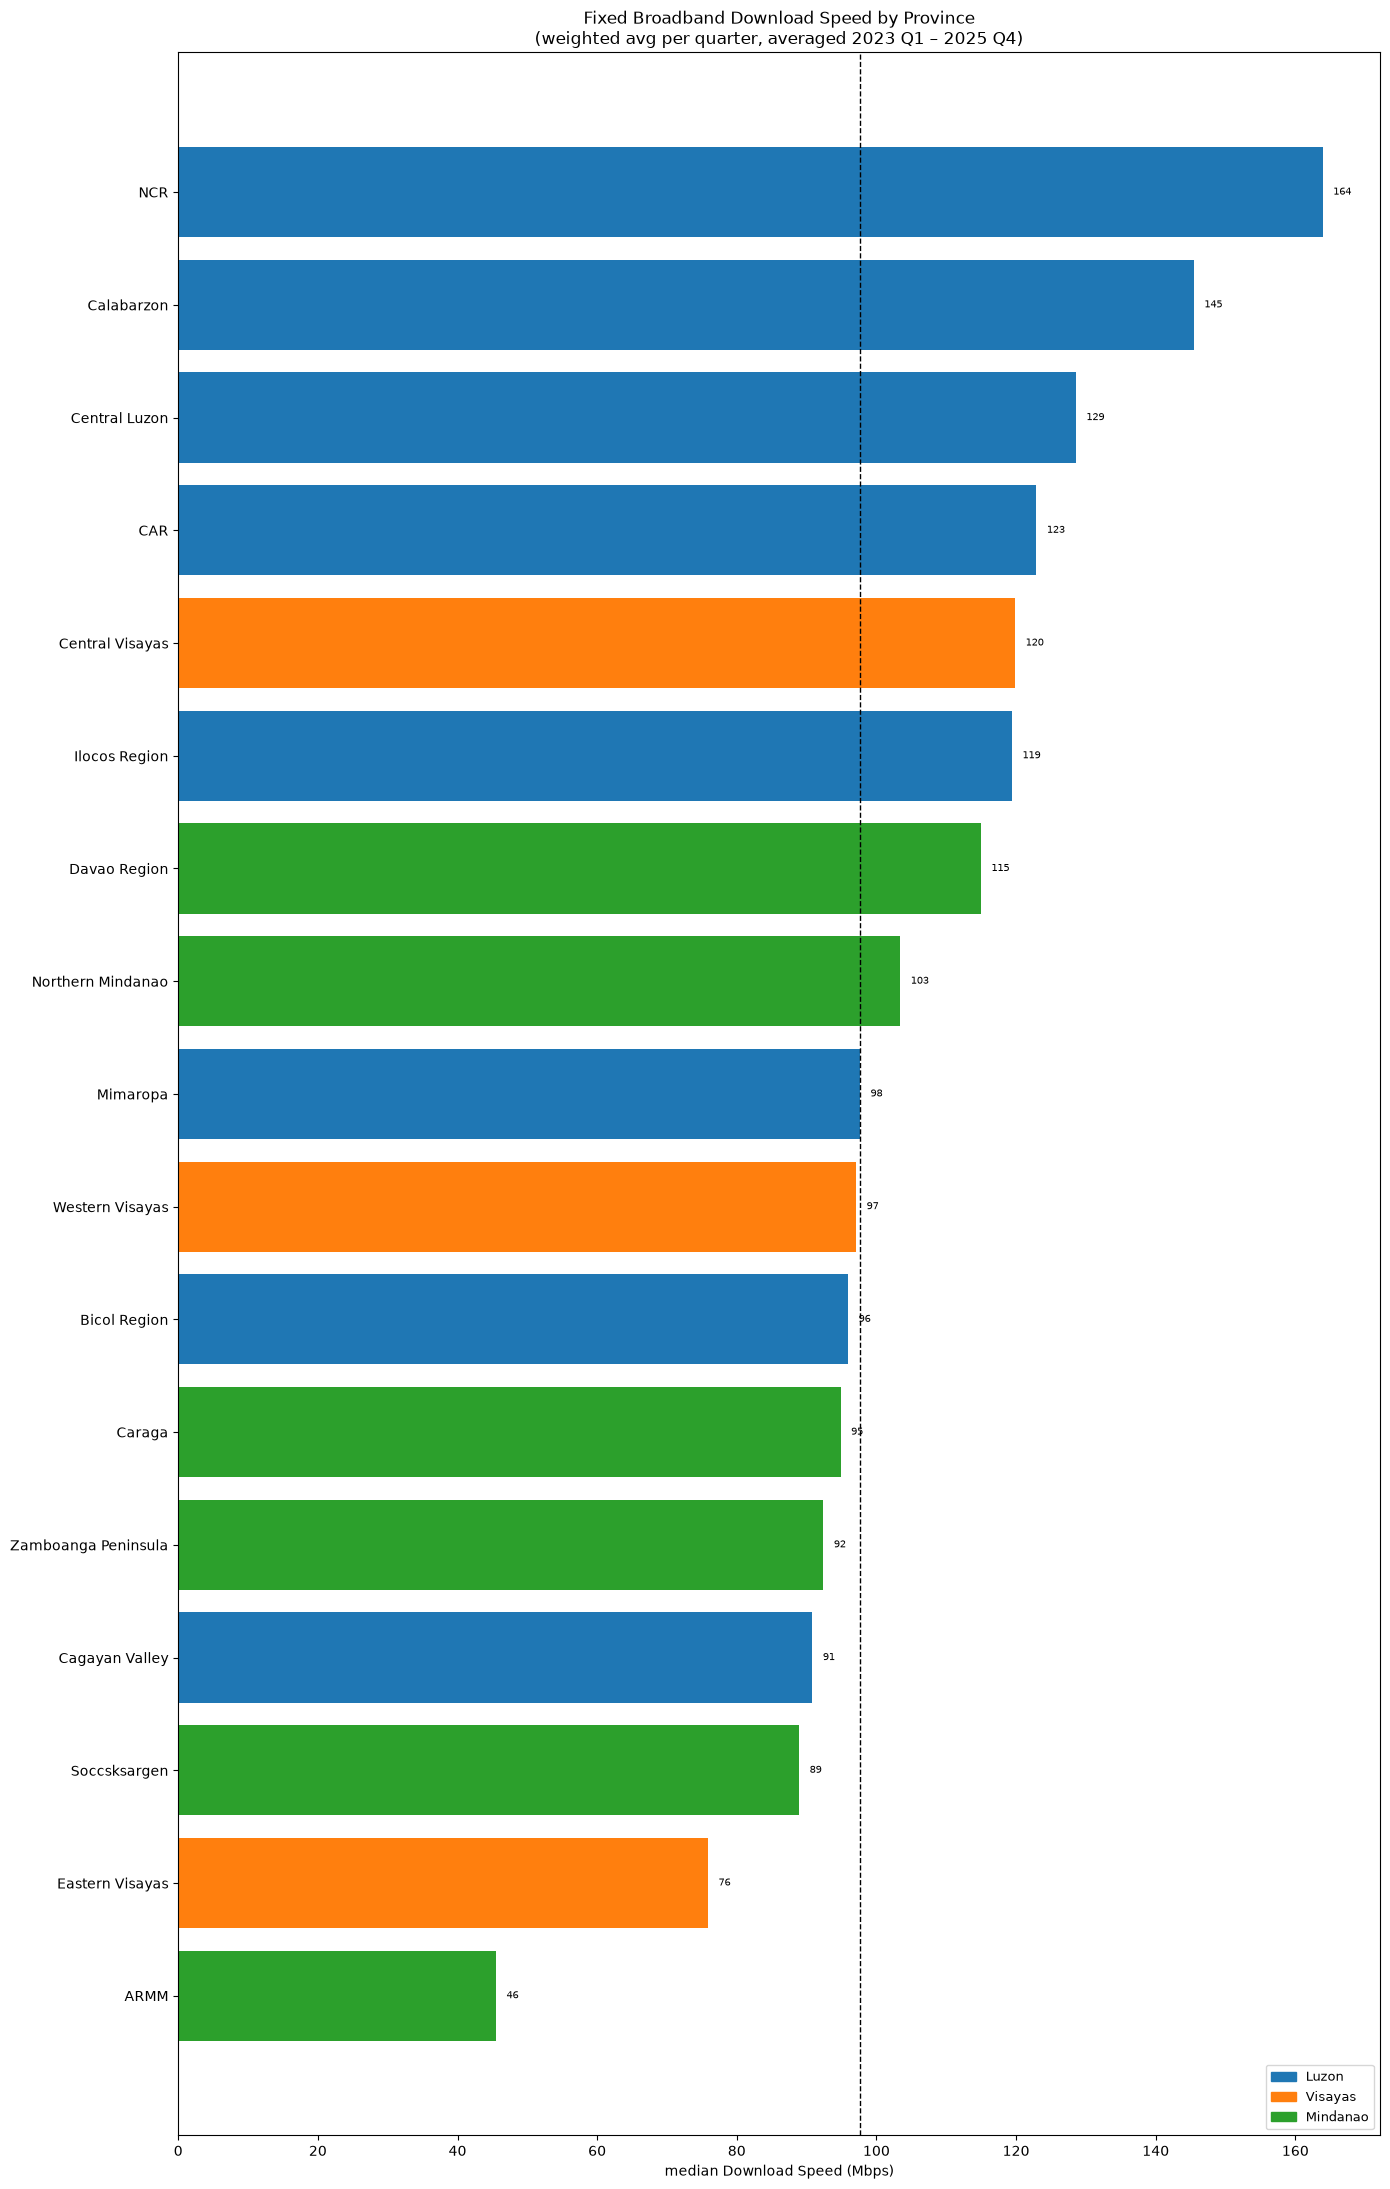

In [26]:
region_colors = {
    'Luzon': '#1f77b4',
    'Visayas': '#ff7f0e',
    'Mindanao': '#2ca02c',
}

prov_median = (
    master.groupby(['name','region'])
    .agg(
        median_dl=('avg_d_mbps','median'),
        median_ul=('avg_u_mbps','median'),
        median_lat=('avg_lat_ms_wt','median'),
        median_tests=('total_tests','median'),
    )
    .reset_index()
    .sort_values('median_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_median['region']]
bars = ax.barh(prov_median['name'], prov_median['median_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_median['median_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_median['median_dl'].median(), color='black', ls='--', lw=1, label=f'National median {prov_median["median_dl"].median():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('median Download Speed (Mbps)')
ax.set_title('Fixed Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/12_province_ranking_median.png', dpi=150, bbox_inches='tight')
plt.show()


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

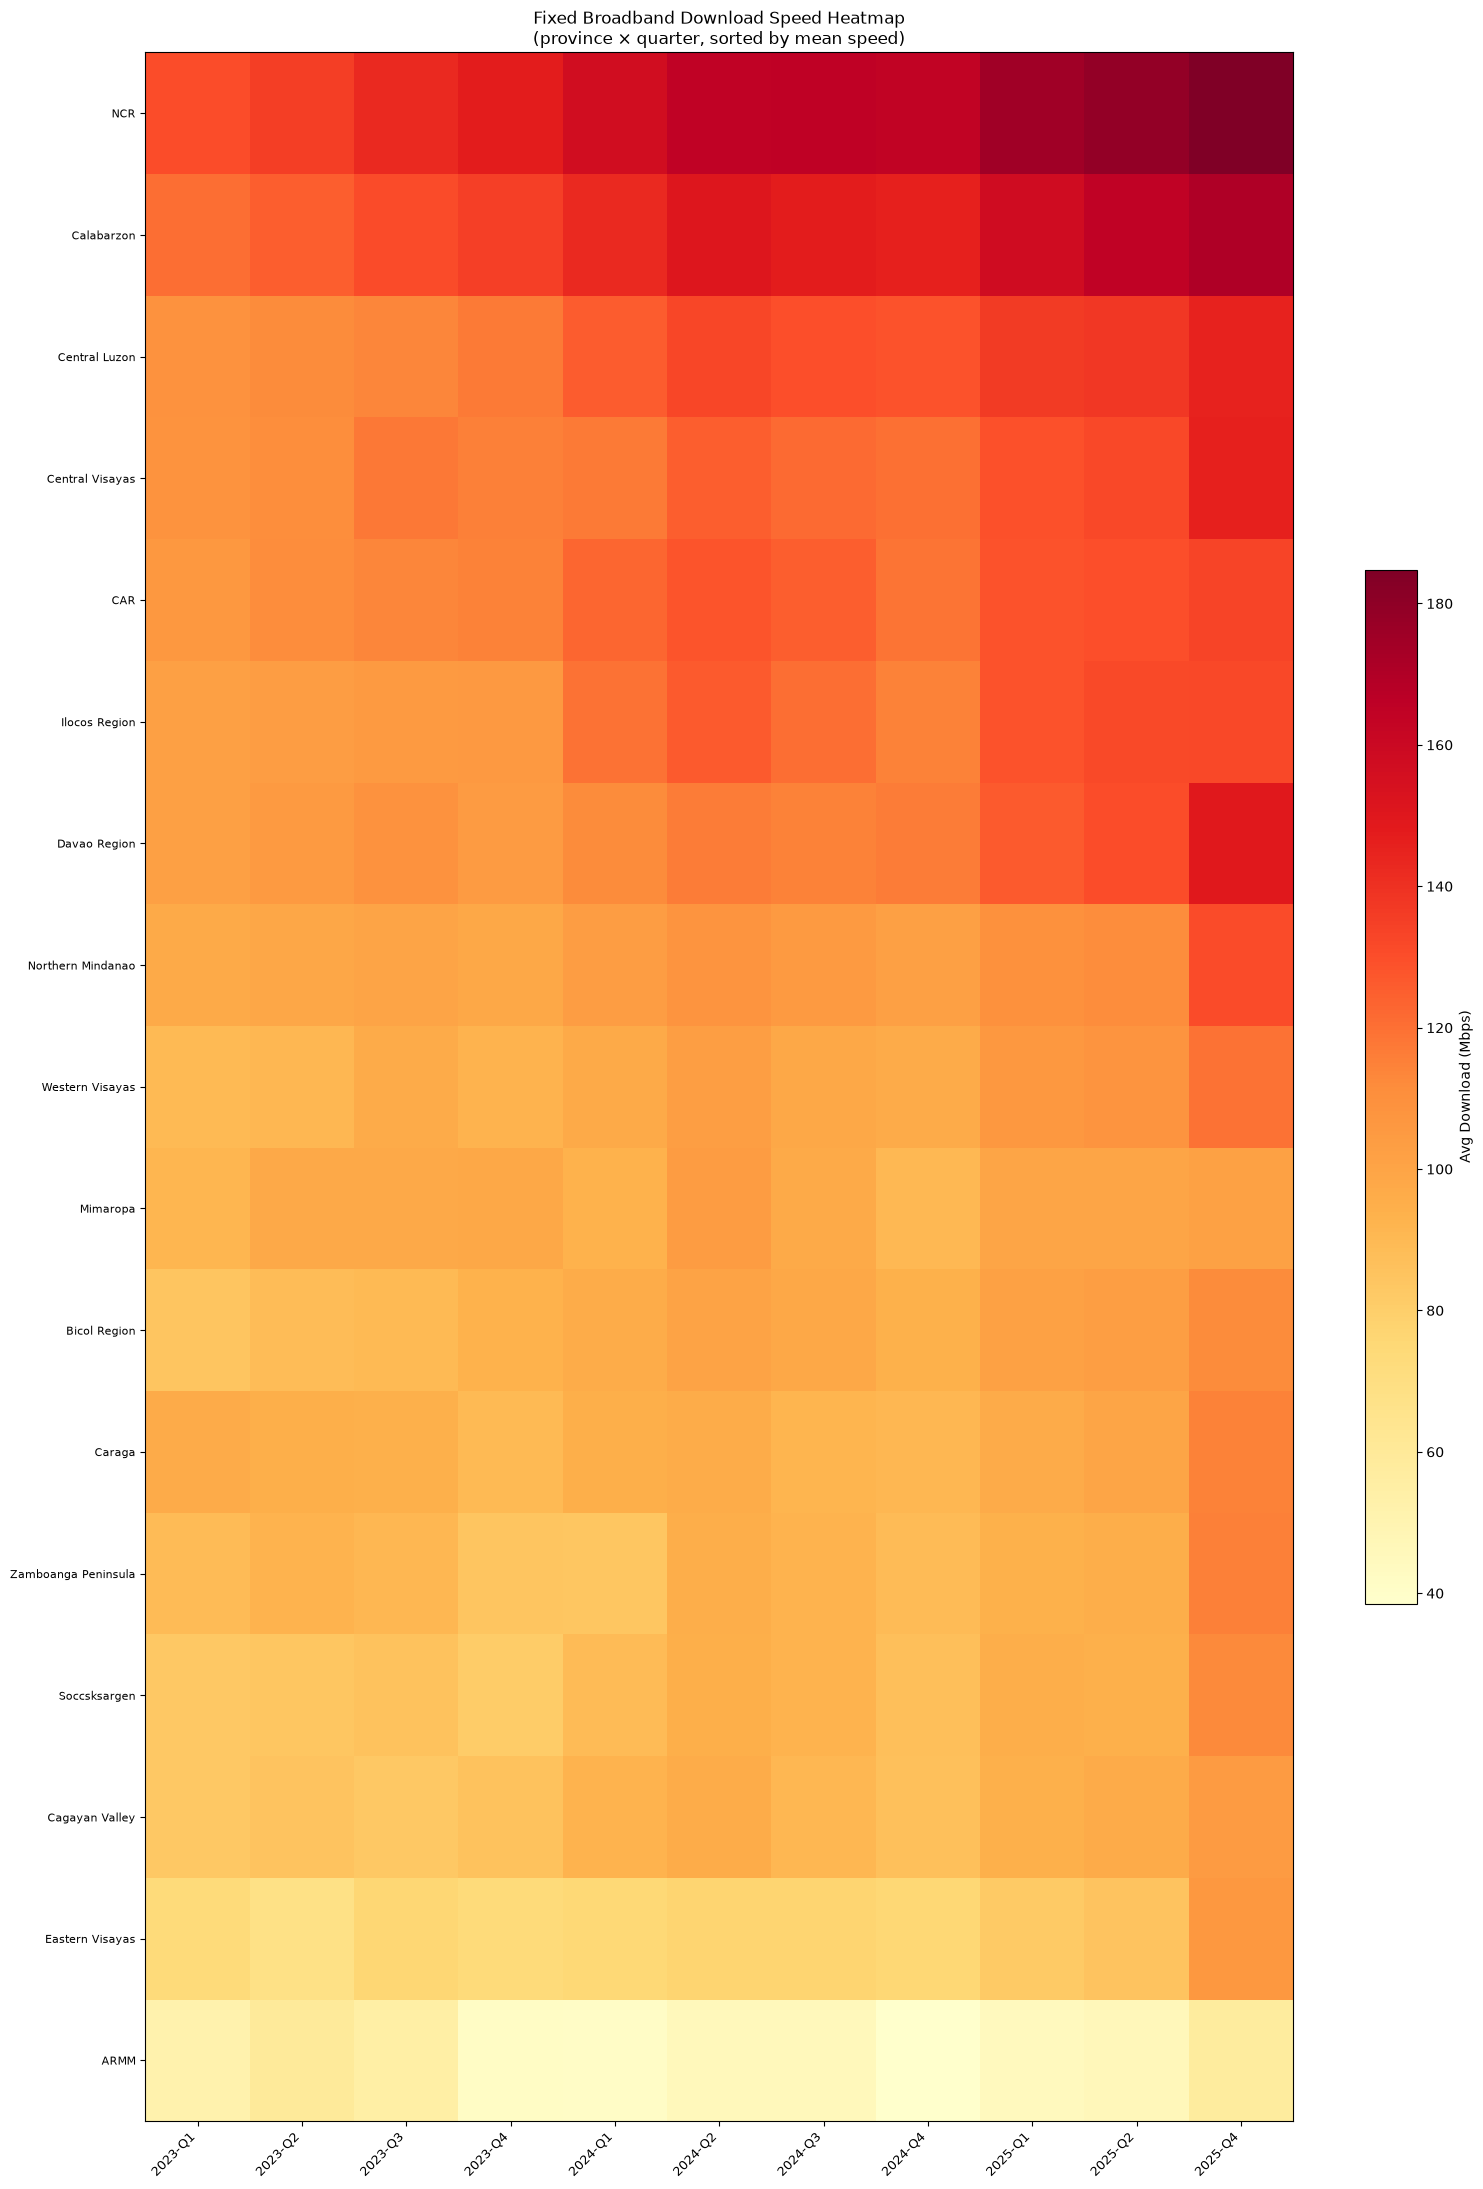

In [27]:
pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
# Format column labels as quarter strings for display
pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
# Sort by mean download speed
pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

fig, ax = plt.subplots(figsize=(16, 22))
im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)

ax.set_xticks(range(len(pivot_dl.columns)))
ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_dl.index)))
ax.set_yticklabels(pivot_dl.index, fontsize=8)
ax.set_title('Fixed Broadband Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()


### 6. Regional Comparison — Download, Upload, Latency

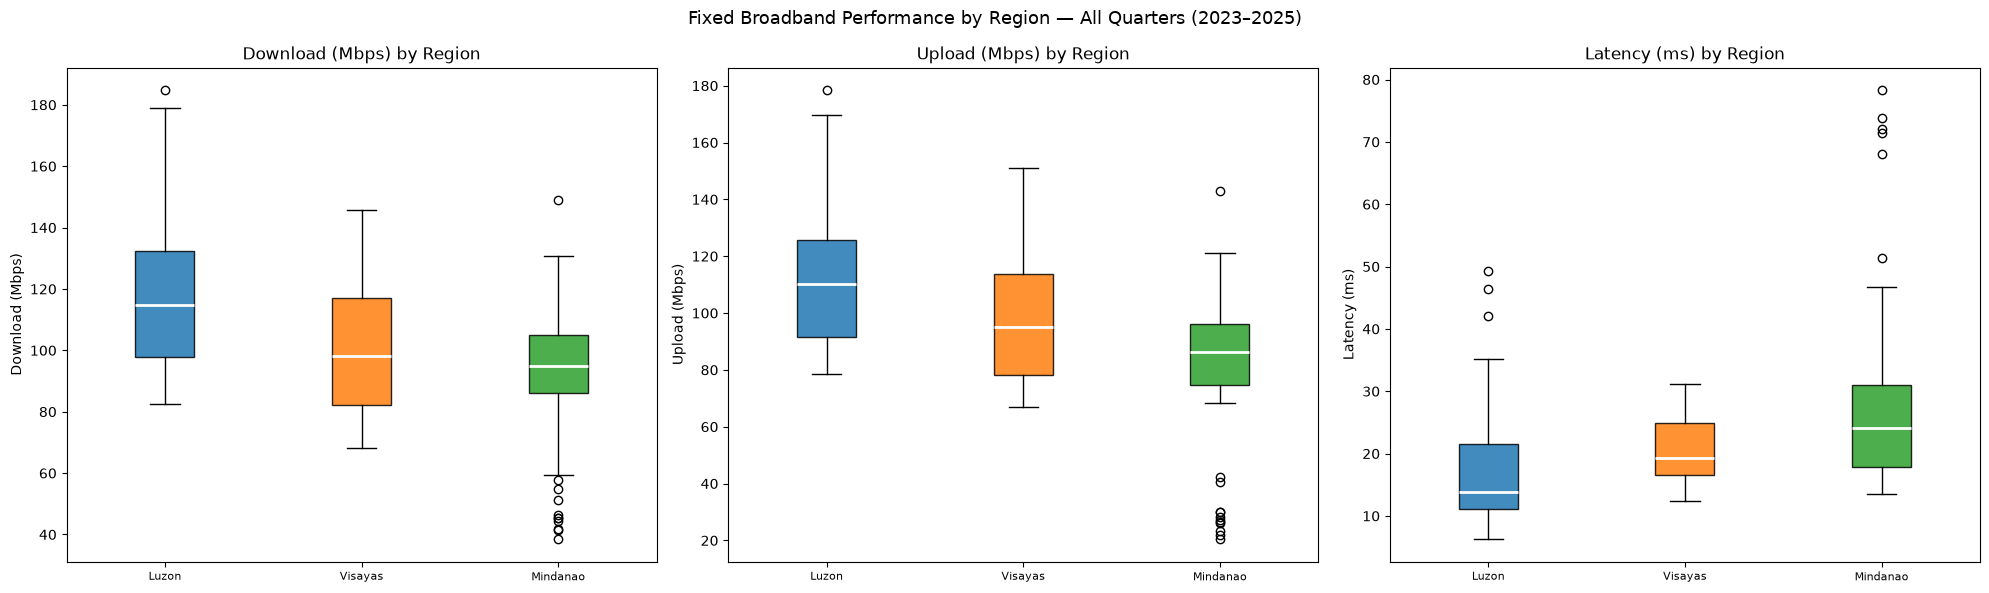

In [28]:
region_order = ['Luzon', 'Visayas', 'Mindanao']
region_data  = [master[master['region']==r]['avg_d_mbps'].dropna().values for r in region_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, label, color_key in [
    (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
    (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
    (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
]:
    data = [master[master['region']==r][metric].dropna().values for r in region_order]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch, region in zip(bp['boxes'], region_order):
        patch.set_facecolor(region_colors[region])
        patch.set_alpha(0.85)
    ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Region')

plt.suptitle('Fixed Broadband Performance by Region — All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

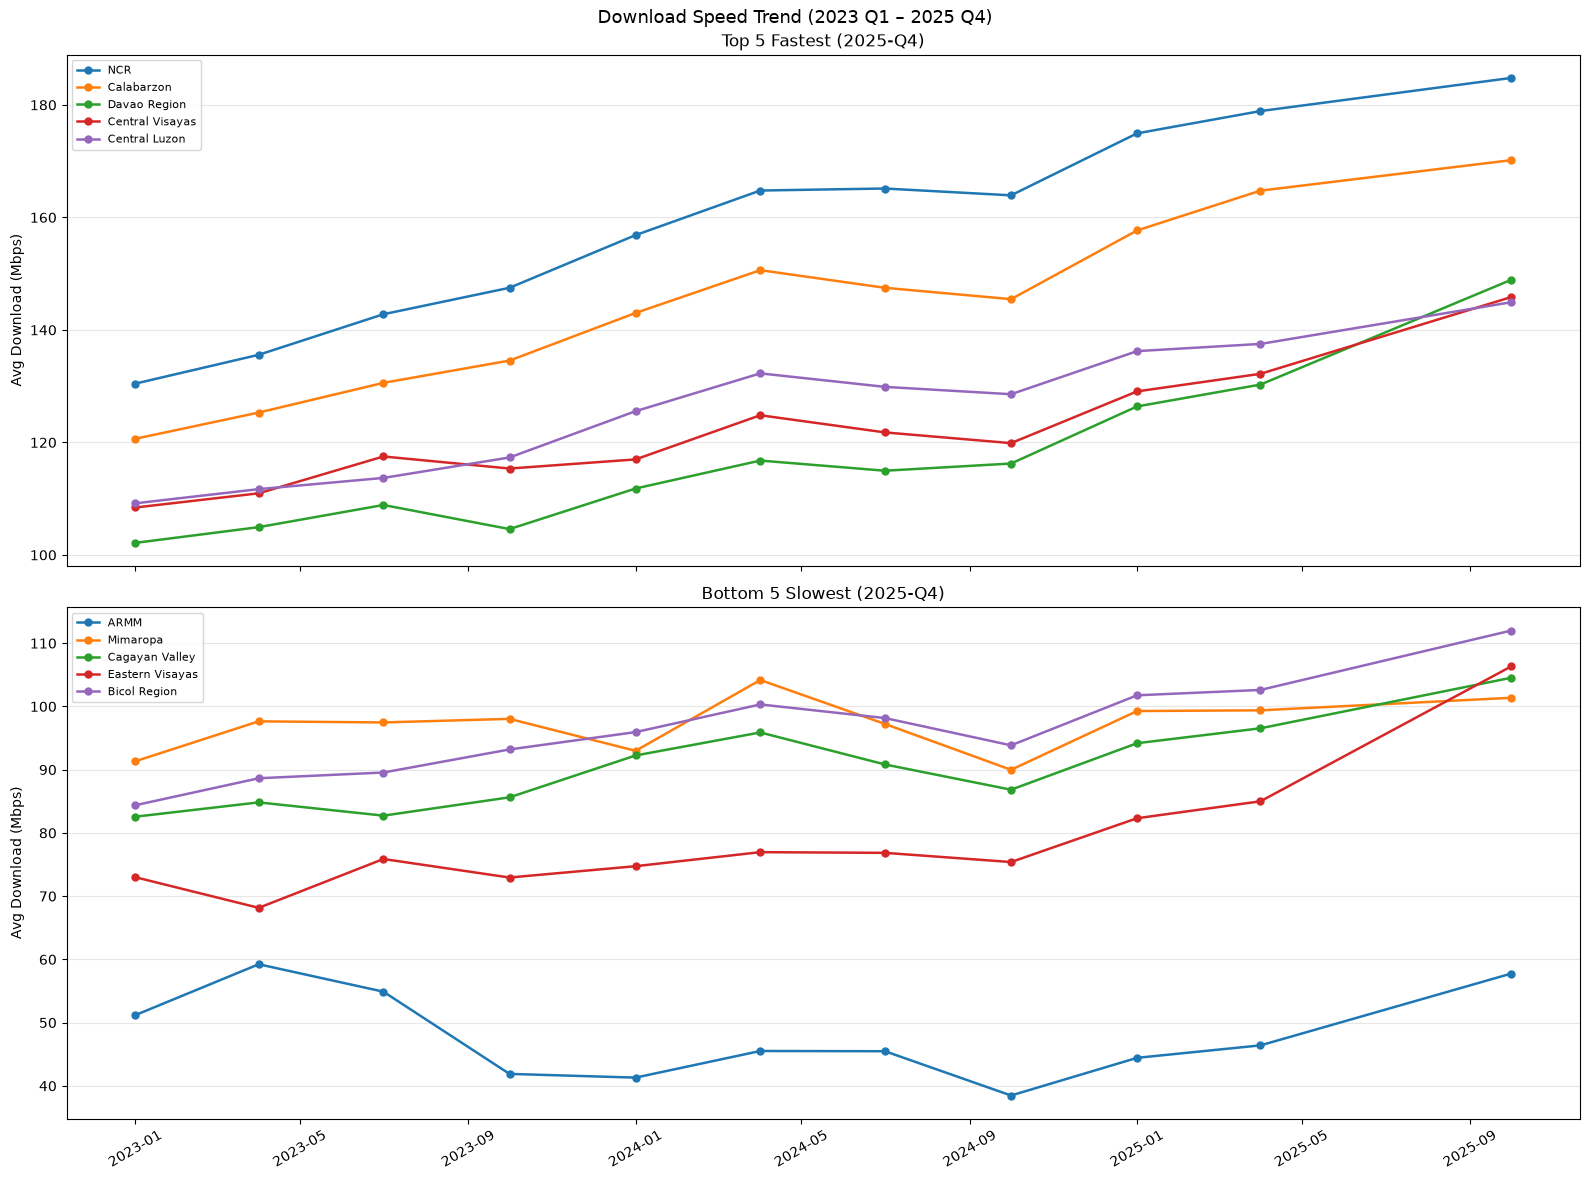

In [29]:
latest_q = master['label'].max()
latest = master[master['label'] == latest_q]
top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

quarter_order = sorted(master['label'].unique())
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

groups = [
    (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
    (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
]

for ax, (title, provinces, base_color) in zip(axes, groups):
    for i, prov in enumerate(provinces):
        df_p = master[master['name']==prov].sort_values('label')
        if df_p.empty: continue
        ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5,
                label=prov, linewidth=1.8)
    ax.set_ylabel('Avg Download (Mbps)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/15_time_series.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

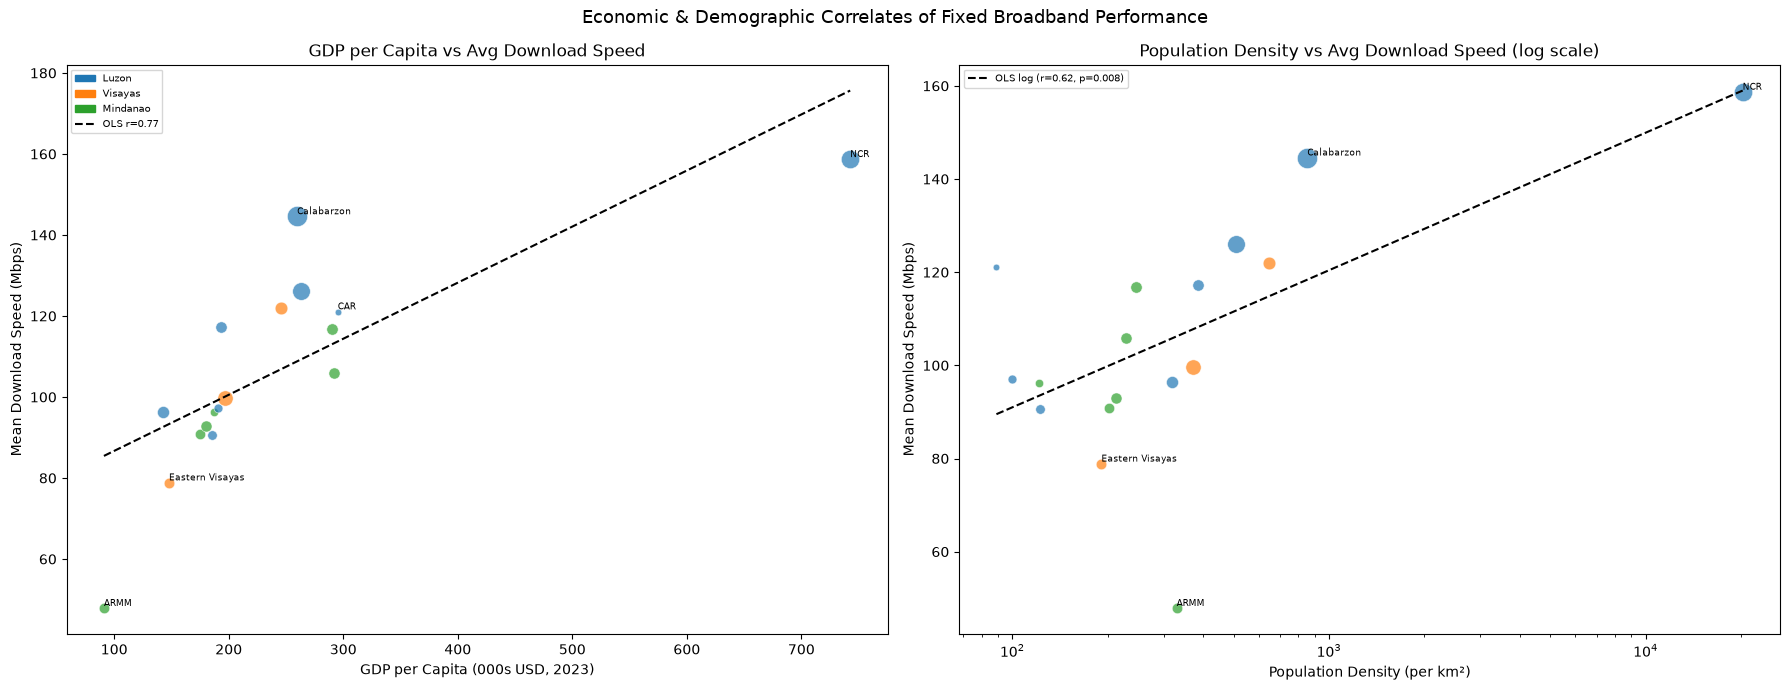

Pearson r (GDP vs download):     0.768  p=0.0003
Pearson r (log density vs download): 0.621  p=0.0078


In [30]:
corr_df = prov_mean.merge(
    prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: GDP vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    # Label outliers
    if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

# OLS trendline
x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
y = corr_df.loc[x.index,'mean_dl']
if x.nunique() > 1:
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
    ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
else:
    r, p = float('nan'), float('nan')
    axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
    ols_handle = []
axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
axes[0].set_ylabel('Mean Download Speed (Mbps)')
axes[0].set_title('GDP per Capita vs Avg Download Speed')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches+ols_handle, fontsize=7)

# Scatter: density vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'],'gray')
    axes[1].scatter(row['density_per_km2'], row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

x2 = corr_df['density_per_km2'].dropna()
y2 = corr_df.loc[x2.index,'mean_dl']
s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
xline2 = np.linspace(x2.min(), x2.max(), 200)
axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
axes[1].set_xlabel('Population Density (per km²)')
axes[1].set_xscale('log')
axes[1].set_ylabel('Mean Download Speed (Mbps)')
axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
axes[1].legend(fontsize=7)

plt.suptitle('Economic & Demographic Correlates of Fixed Broadband Performance', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")


### 8.5 Multivariate Model — GDP + Density + Tier + Region Together


In [31]:
import statsmodels.formula.api as smf

model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
model_df['log_density'] = np.log1p(model_df['density_per_km2'])

terms = []
if model_df['log_gdp'].nunique() > 1:
    terms.append('log_gdp')
if model_df['log_density'].nunique() > 1:
    terms.append('log_density')
if model_df['internet_tier'].nunique() > 1:
    terms.append("C(internet_tier)")
if model_df['region'].nunique() > 1:
    terms.append('C(region)')

formula = 'mean_dl ~ ' + ' + '.join(terms)
mv_model = smf.ols(formula, data=model_df).fit()
print(mv_model.summary())

print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")


                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     14.31
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           0.000323
Time:                        18:55:36   Log-Likelihood:                -57.490
No. Observations:                  17   AIC:                             131.0
Df Residuals:                       9   BIC:                             137.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              -551.23

NDT per tile , facebook , spilt , 

### 9. Upload/Download Ratio — Symmetry Check

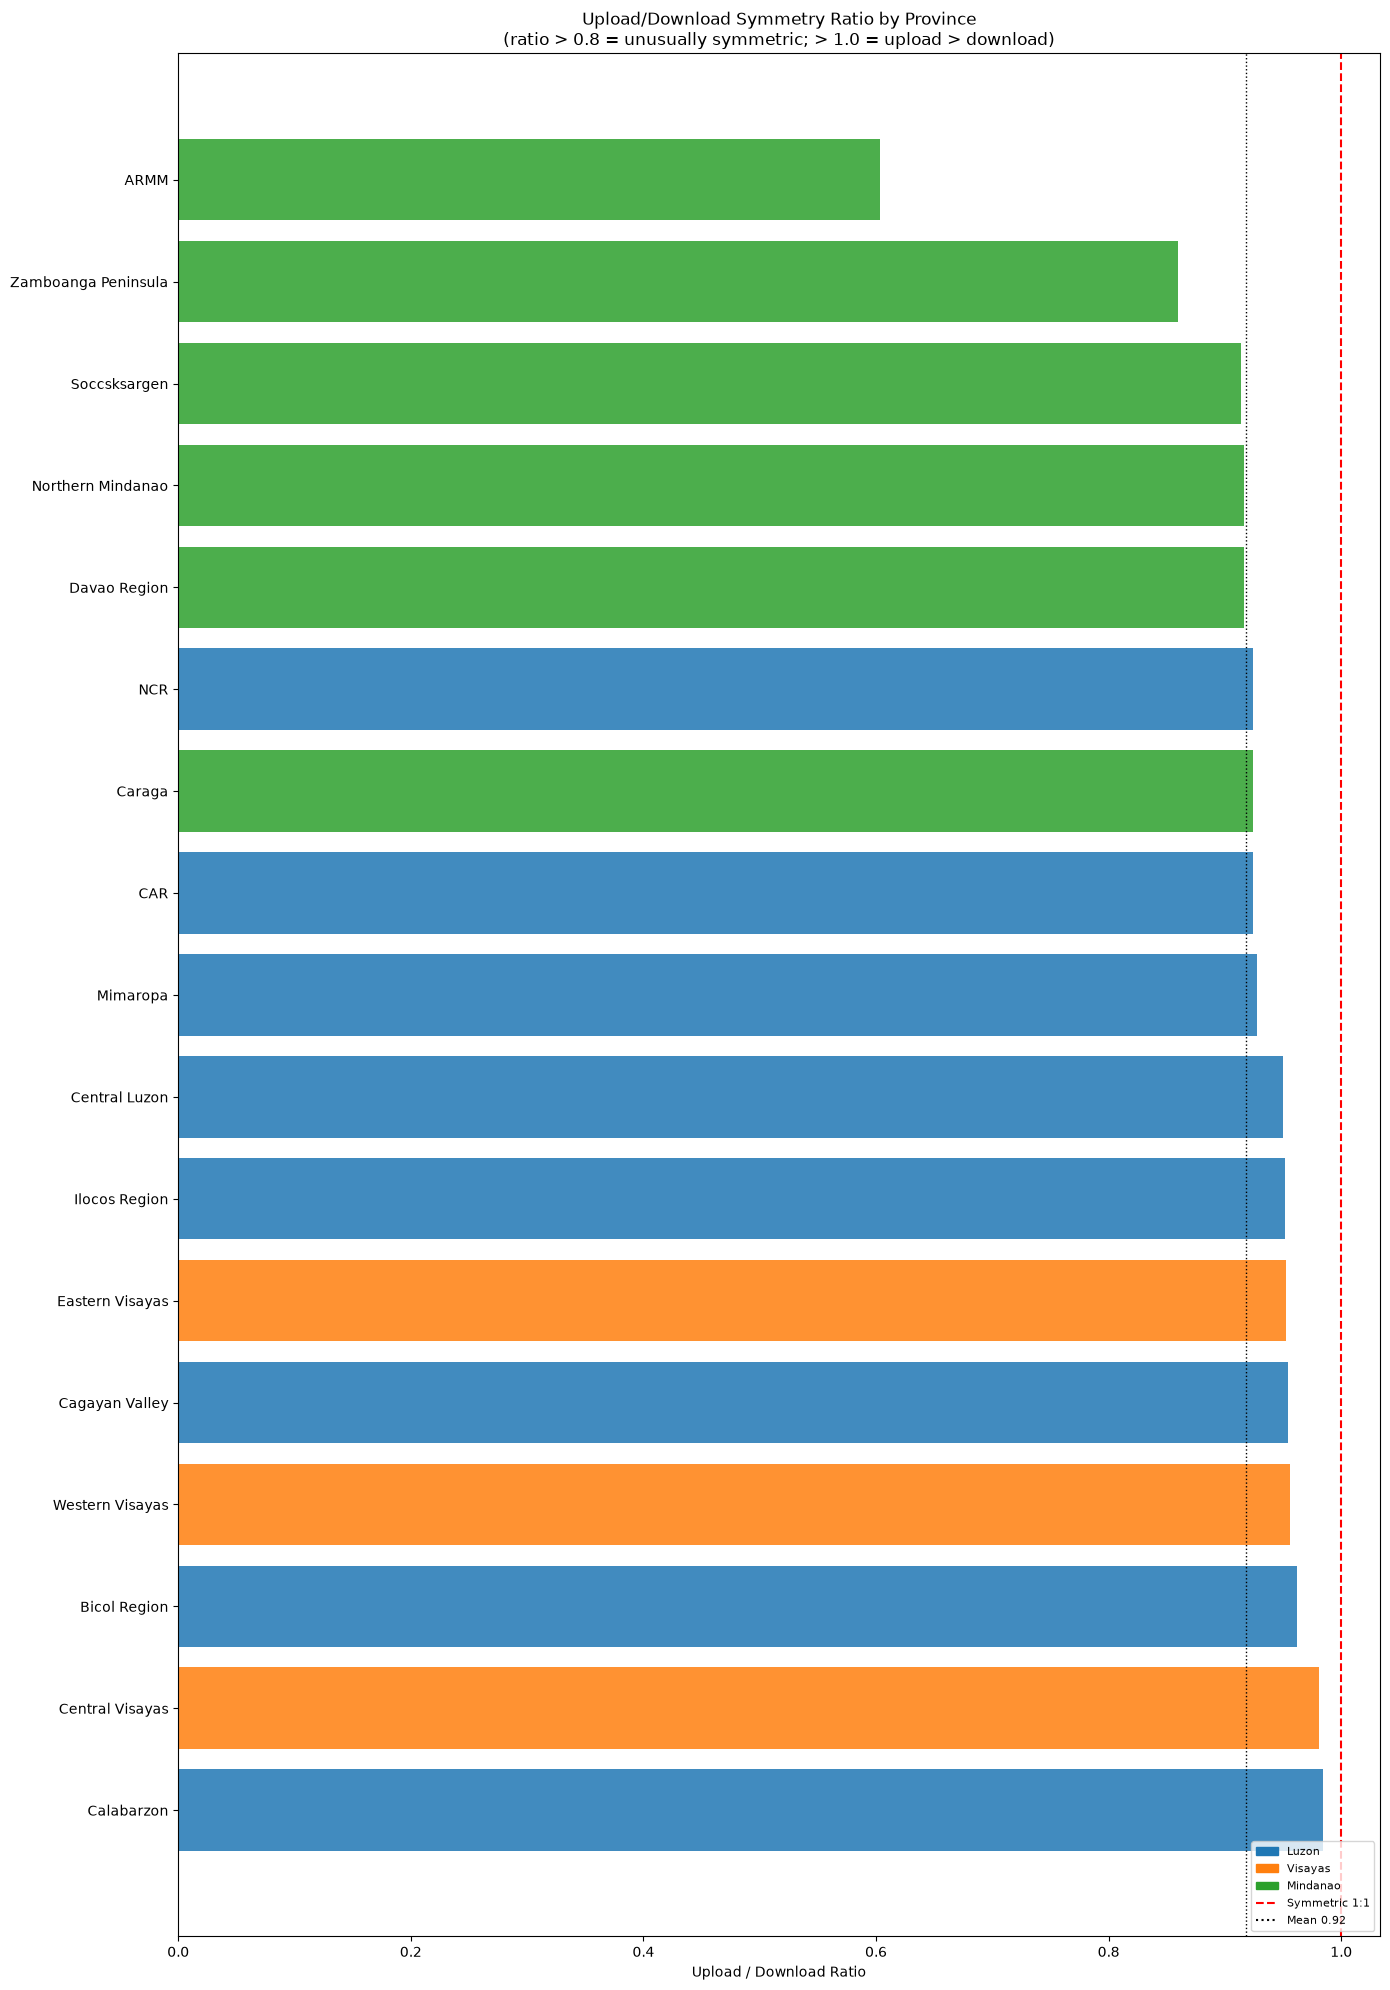

Provinces with UL/DL ratio > 0.8 (16):
               name   region  ul_dl_ratio
         Calabarzon    Luzon     0.984123
    Central Visayas  Visayas     0.981230
       Bicol Region    Luzon     0.961832
    Western Visayas  Visayas     0.955551
     Cagayan Valley    Luzon     0.953900
    Eastern Visayas  Visayas     0.952764
      Ilocos Region    Luzon     0.951557
      Central Luzon    Luzon     0.950030
           Mimaropa    Luzon     0.927925
                CAR    Luzon     0.924509
             Caraga Mindanao     0.924056
                NCR    Luzon     0.923881
       Davao Region Mindanao     0.916162
  Northern Mindanao Mindanao     0.916128
       Soccsksargen Mindanao     0.913678
Zamboanga Peninsula Mindanao     0.859912


In [32]:
master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']

ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
ax.set_xlabel('Upload / Download Ratio')
ax.set_title('Upload/Download Symmetry Ratio by Province\n(ratio > 0.8 = unusually symmetric; > 1.0 = upload > download)')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[
    plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
    plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
], fontsize=8, loc='lower right')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
plt.show()

divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.8]
print(f"Provinces with UL/DL ratio > 0.8 ({len(divergent_ratio)}):")
print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))


### 10. Anomaly Detection — Province Flags

In [33]:
# === ANOMALY DETECTION (recalibrated from actual data) ===
# National mean UL/DL ratio = 0.852 → flag only clear outliers (z-score based)
# Tier medians are compressed: T1=282, T2=247, T3=246, T4=229 Mbps
# Thresholds set based on observed distributions

from scipy import stats
import numpy as np

master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
        mean_ratio=('ul_dl_ratio','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=False)
)
prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

tier_speed   = prov_mean.groupby('tier')['mean_dl'].median()
national_std = prov_mean['mean_dl'].std()


# infastructure mod

### 12. Full Province Summary Table

In [34]:
summary = prov_mean.merge(
    prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
    on='name', how='left'
).copy()

summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
summary = summary.sort_values('mean_dl', ascending=False).round(2)

print(summary[[
    'name','region','internet_tier',
    'mean_dl','mean_ul','mean_lat',
    'ul_dl_ratio','mean_tests',
    'gdp_per_capita_thb_2021'
]].to_string(index=False))

               name   region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
                NCR    Luzon              1   158.70   146.89      7.00         0.92  1133928.64                742614.53
         Calabarzon    Luzon              2   144.57   142.22     10.83         0.98   835261.82                259765.51
      Central Luzon    Luzon              2   126.08   119.78     12.40         0.95   495337.45                263326.87
    Central Visayas  Visayas              2   122.08   119.95     15.07         0.98   332316.82                245591.30
                CAR    Luzon              1   121.10   111.97     14.58         0.92    61139.09                295236.64
      Ilocos Region    Luzon              3   117.22   111.54     12.39         0.95   112437.91                193453.01
       Davao Region Mindanao              1   116.91   107.36     17.28         0.92   157934.45                290535.65
  Northern Mindanao Mind

### 13. UL/DL Symmetry — Fiber Penetration Evidence

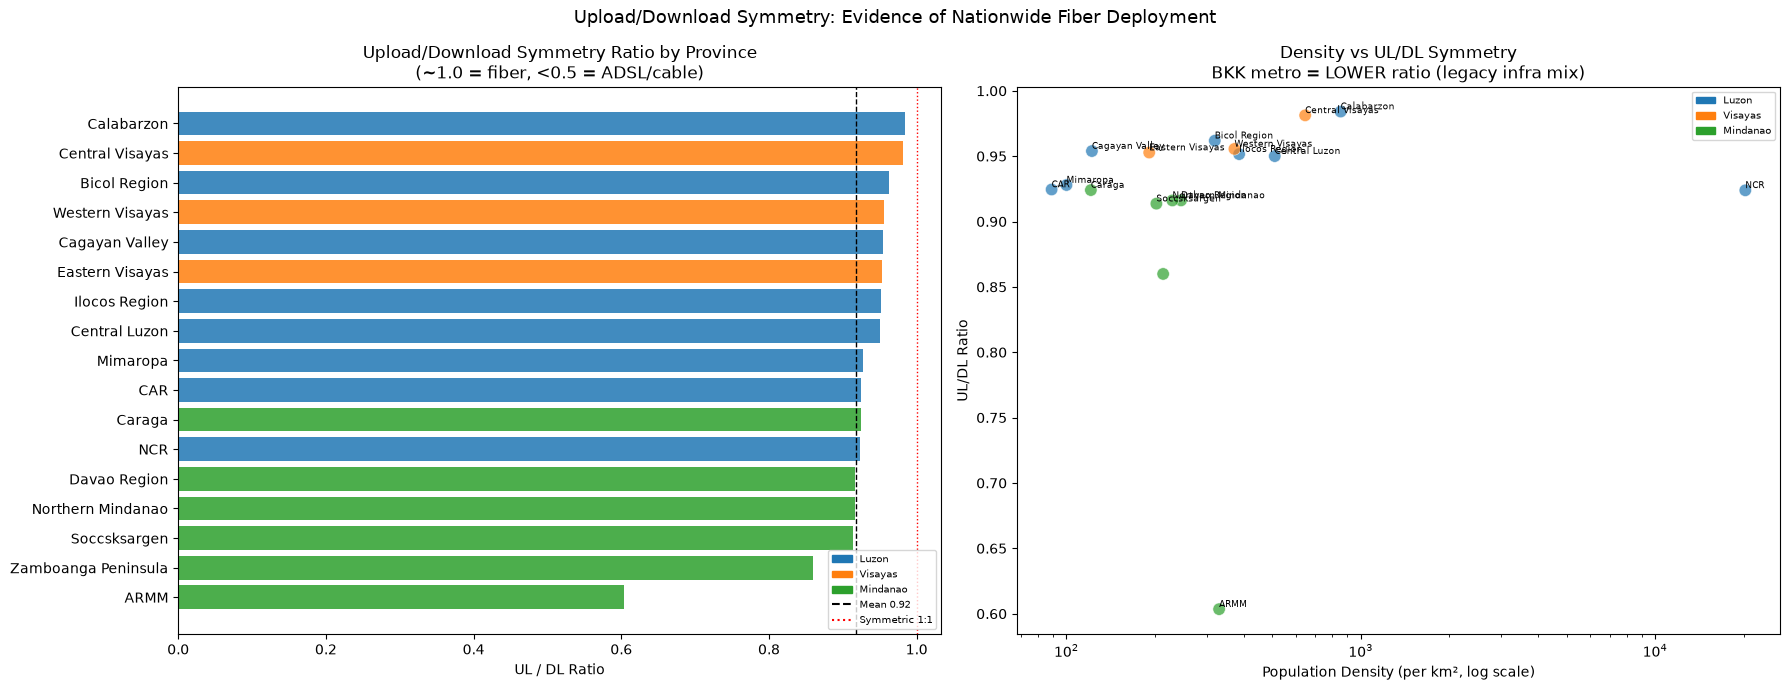

Provinces ratio > 0.90: 15 (near-perfect fiber)
Provinces ratio > 0.80: 16 out of 17
Luzon min ratio: 0.924
Mindanao max ratio: 0.924


In [35]:
# Near-symmetric UL/DL often indicates fiber (GPON/FTTH ~1:1) vs legacy copper (ADSL ~0.1-0.2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1,
                label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
axes[0].set_xlabel('UL / DL Ratio')
axes[0].set_title('Upload/Download Symmetry Ratio by Province\n(~1.0 = fiber, <0.5 = ADSL/cable)')
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches + [
    plt.Line2D([0],[0],color='black',ls='--',label=f'Mean {prov_mean["mean_ratio"].mean():.2f}'),
    plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
], fontsize=7, loc='lower right')

axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                prov_mean['mean_ratio'].values,
                c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                s=80, alpha=0.7, edgecolors='white', lw=0.5)
for _, row in prov_mean.iterrows():
    if row['mean_ratio'] > 0.91 or row['mean_ratio'] < 0.81 or row['mean_dl'] > 300:
        density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
        if len(density):
            axes[1].annotate(row['name'], (density[0], row['mean_ratio']),
                             fontsize=6.5, ha='left', va='bottom')
axes[1].set_xscale('log')
axes[1].set_xlabel('Population Density (per km², log scale)')
axes[1].set_ylabel('UL/DL Ratio')
axes[1].set_title('Density vs UL/DL Symmetry\nBKK metro = LOWER ratio (legacy infra mix)')
axes[1].legend(handles=patches, fontsize=7)

plt.suptitle('Upload/Download Symmetry: Evidence of Nationwide Fiber Deployment', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

_top_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmax(), 'region']
_bot_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmin(), 'region']
print(f"Provinces ratio > 0.90: {(prov_mean['mean_ratio'] > 0.90).sum()} (near-perfect fiber)")
print(f"Provinces ratio > 0.80: {(prov_mean['mean_ratio'] > 0.80).sum()} out of {len(prov_mean)}")
print(f"{_top_region} min ratio: {prov_mean[prov_mean['region']==_top_region]['mean_ratio'].min():.3f}")
print(f"{_bot_region} max ratio: {prov_mean[prov_mean['region']==_bot_region]['mean_ratio'].max():.3f}")


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

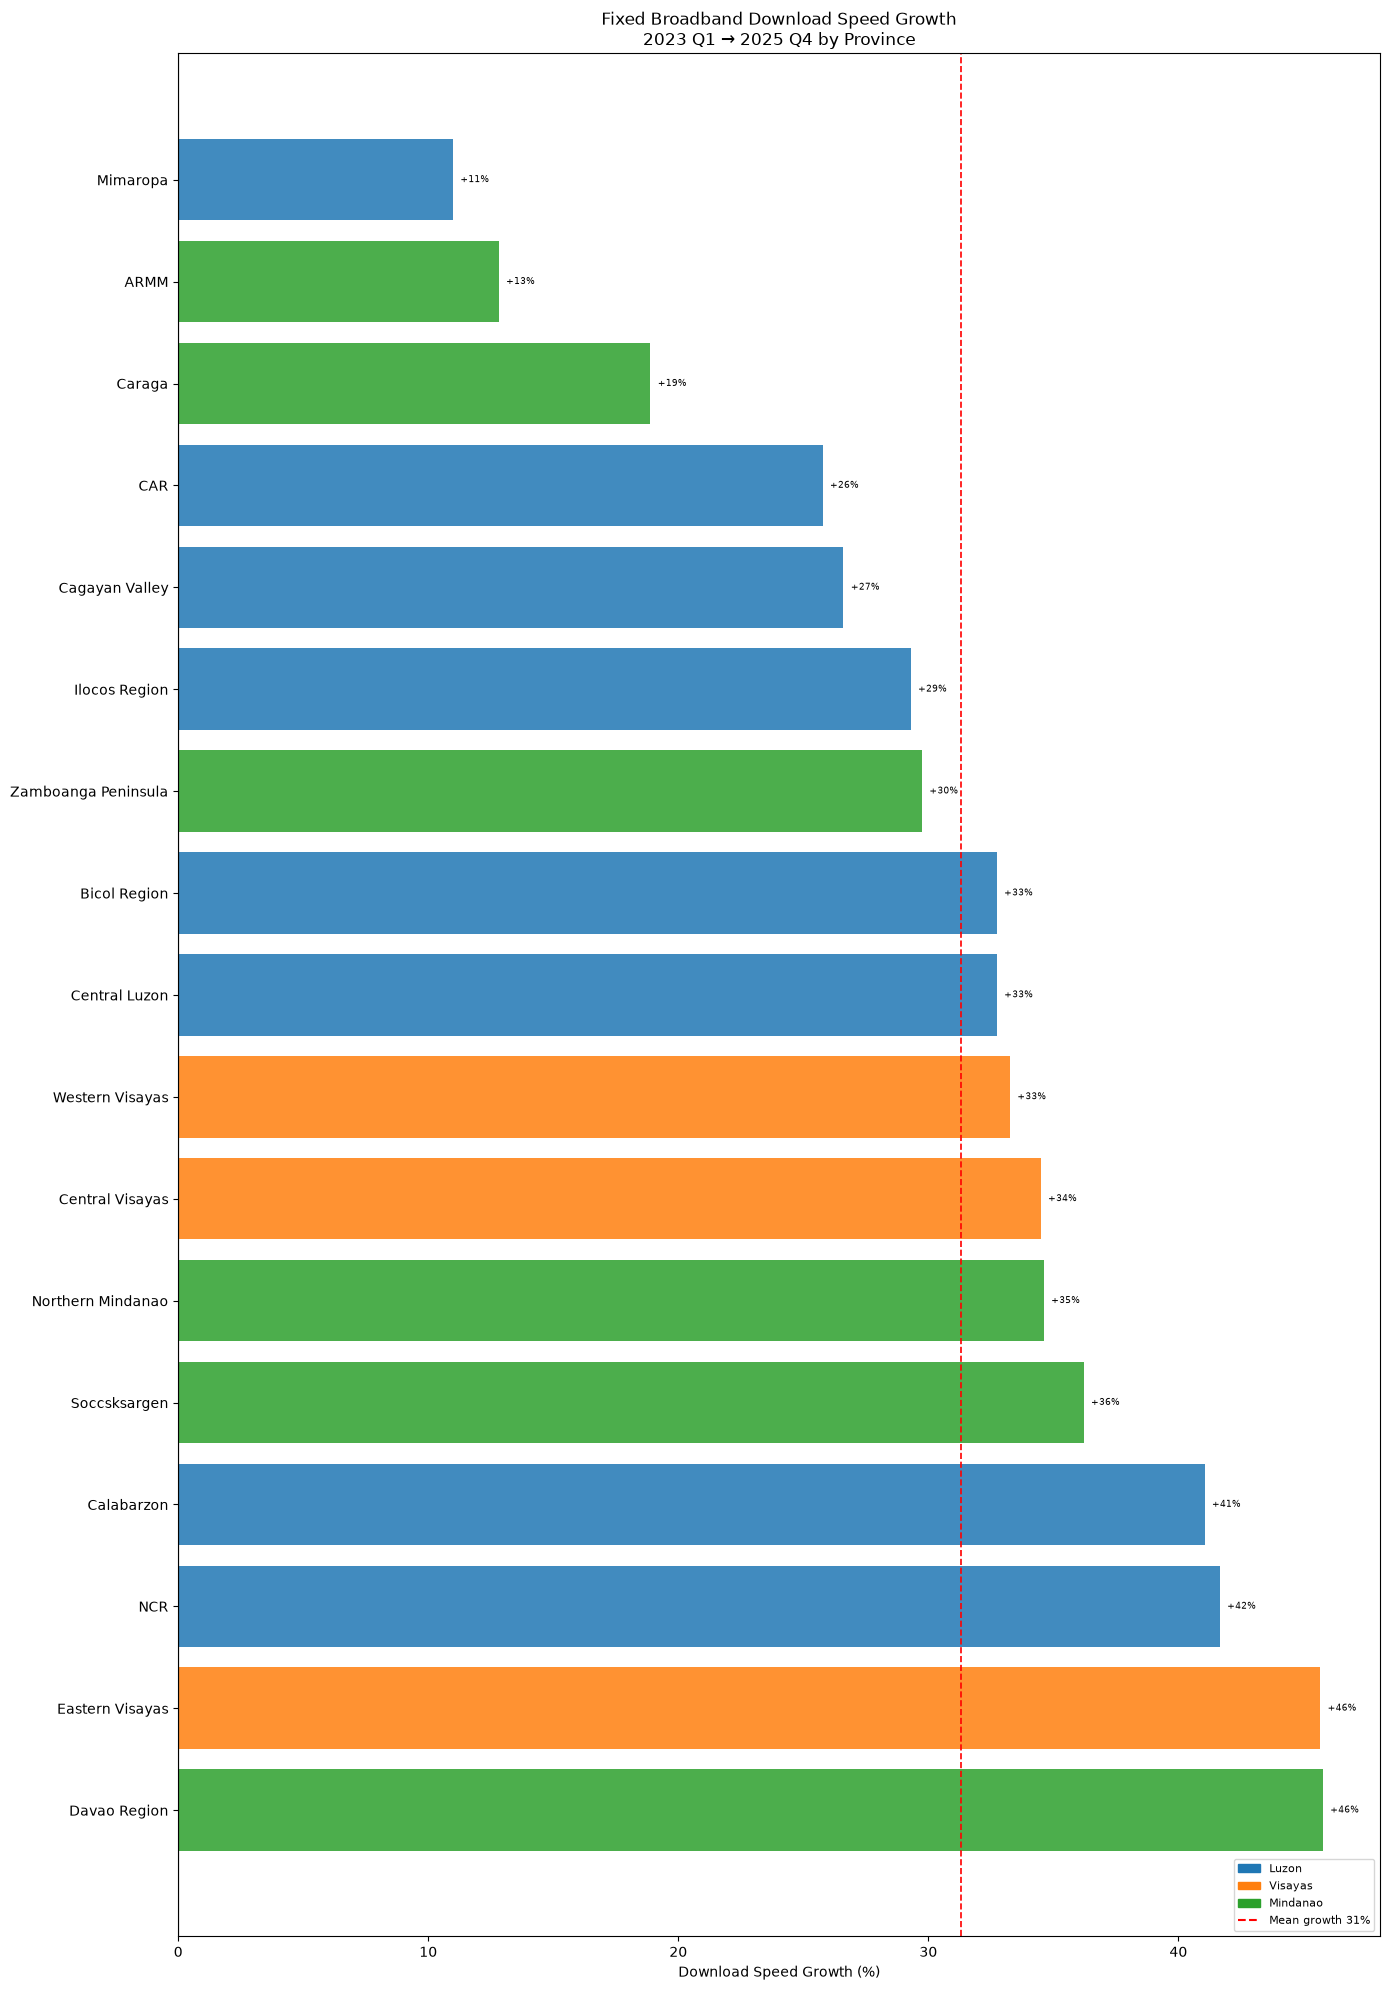

Top 10 fastest growing provinces:
             name   region  internet_tier  pct_growth
     Davao Region Mindanao              1   45.774676
  Eastern Visayas  Visayas              4   45.672216
              NCR    Luzon              1   41.653061
       Calabarzon    Luzon              2   41.044967
     Soccsksargen Mindanao              4   36.207524
Northern Mindanao Mindanao              1   34.615515
  Central Visayas  Visayas              2   34.490458
  Western Visayas  Visayas              2   33.261227
    Central Luzon    Luzon              2   32.735467
     Bicol Region    Luzon              4   32.731808

Bottom 5 (slowest growth or decline):
          name   region  internet_tier  pct_growth
      Mimaropa    Luzon              3   10.985353
          ARMM Mindanao              4   12.814503
        Caraga Mindanao              3   18.883200
           CAR    Luzon              1   25.768655
Cagayan Valley    Luzon              3   26.604232


In [36]:
first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

growth_df = growth.reset_index()
growth_df.columns = ['name','pct_growth']
growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in growth_df['region']]
bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2,
           label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
for bar, val in zip(bars, growth_df['pct_growth']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', fontsize=6.5)
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f'Mean growth {growth_df["pct_growth"].mean():.0f}%')],
          fontsize=8, loc='lower right')
ax.set_xlabel('Download Speed Growth (%)')
ax.set_title('Fixed Broadband Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/20_density_vs_speed.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 fastest growing provinces:")
print(growth_df.nlargest(10,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))
print("\nBottom 5 (slowest growth or decline):")
print(growth_df.nsmallest(5,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))


### 15. Deep Dive — The Divergent Ones

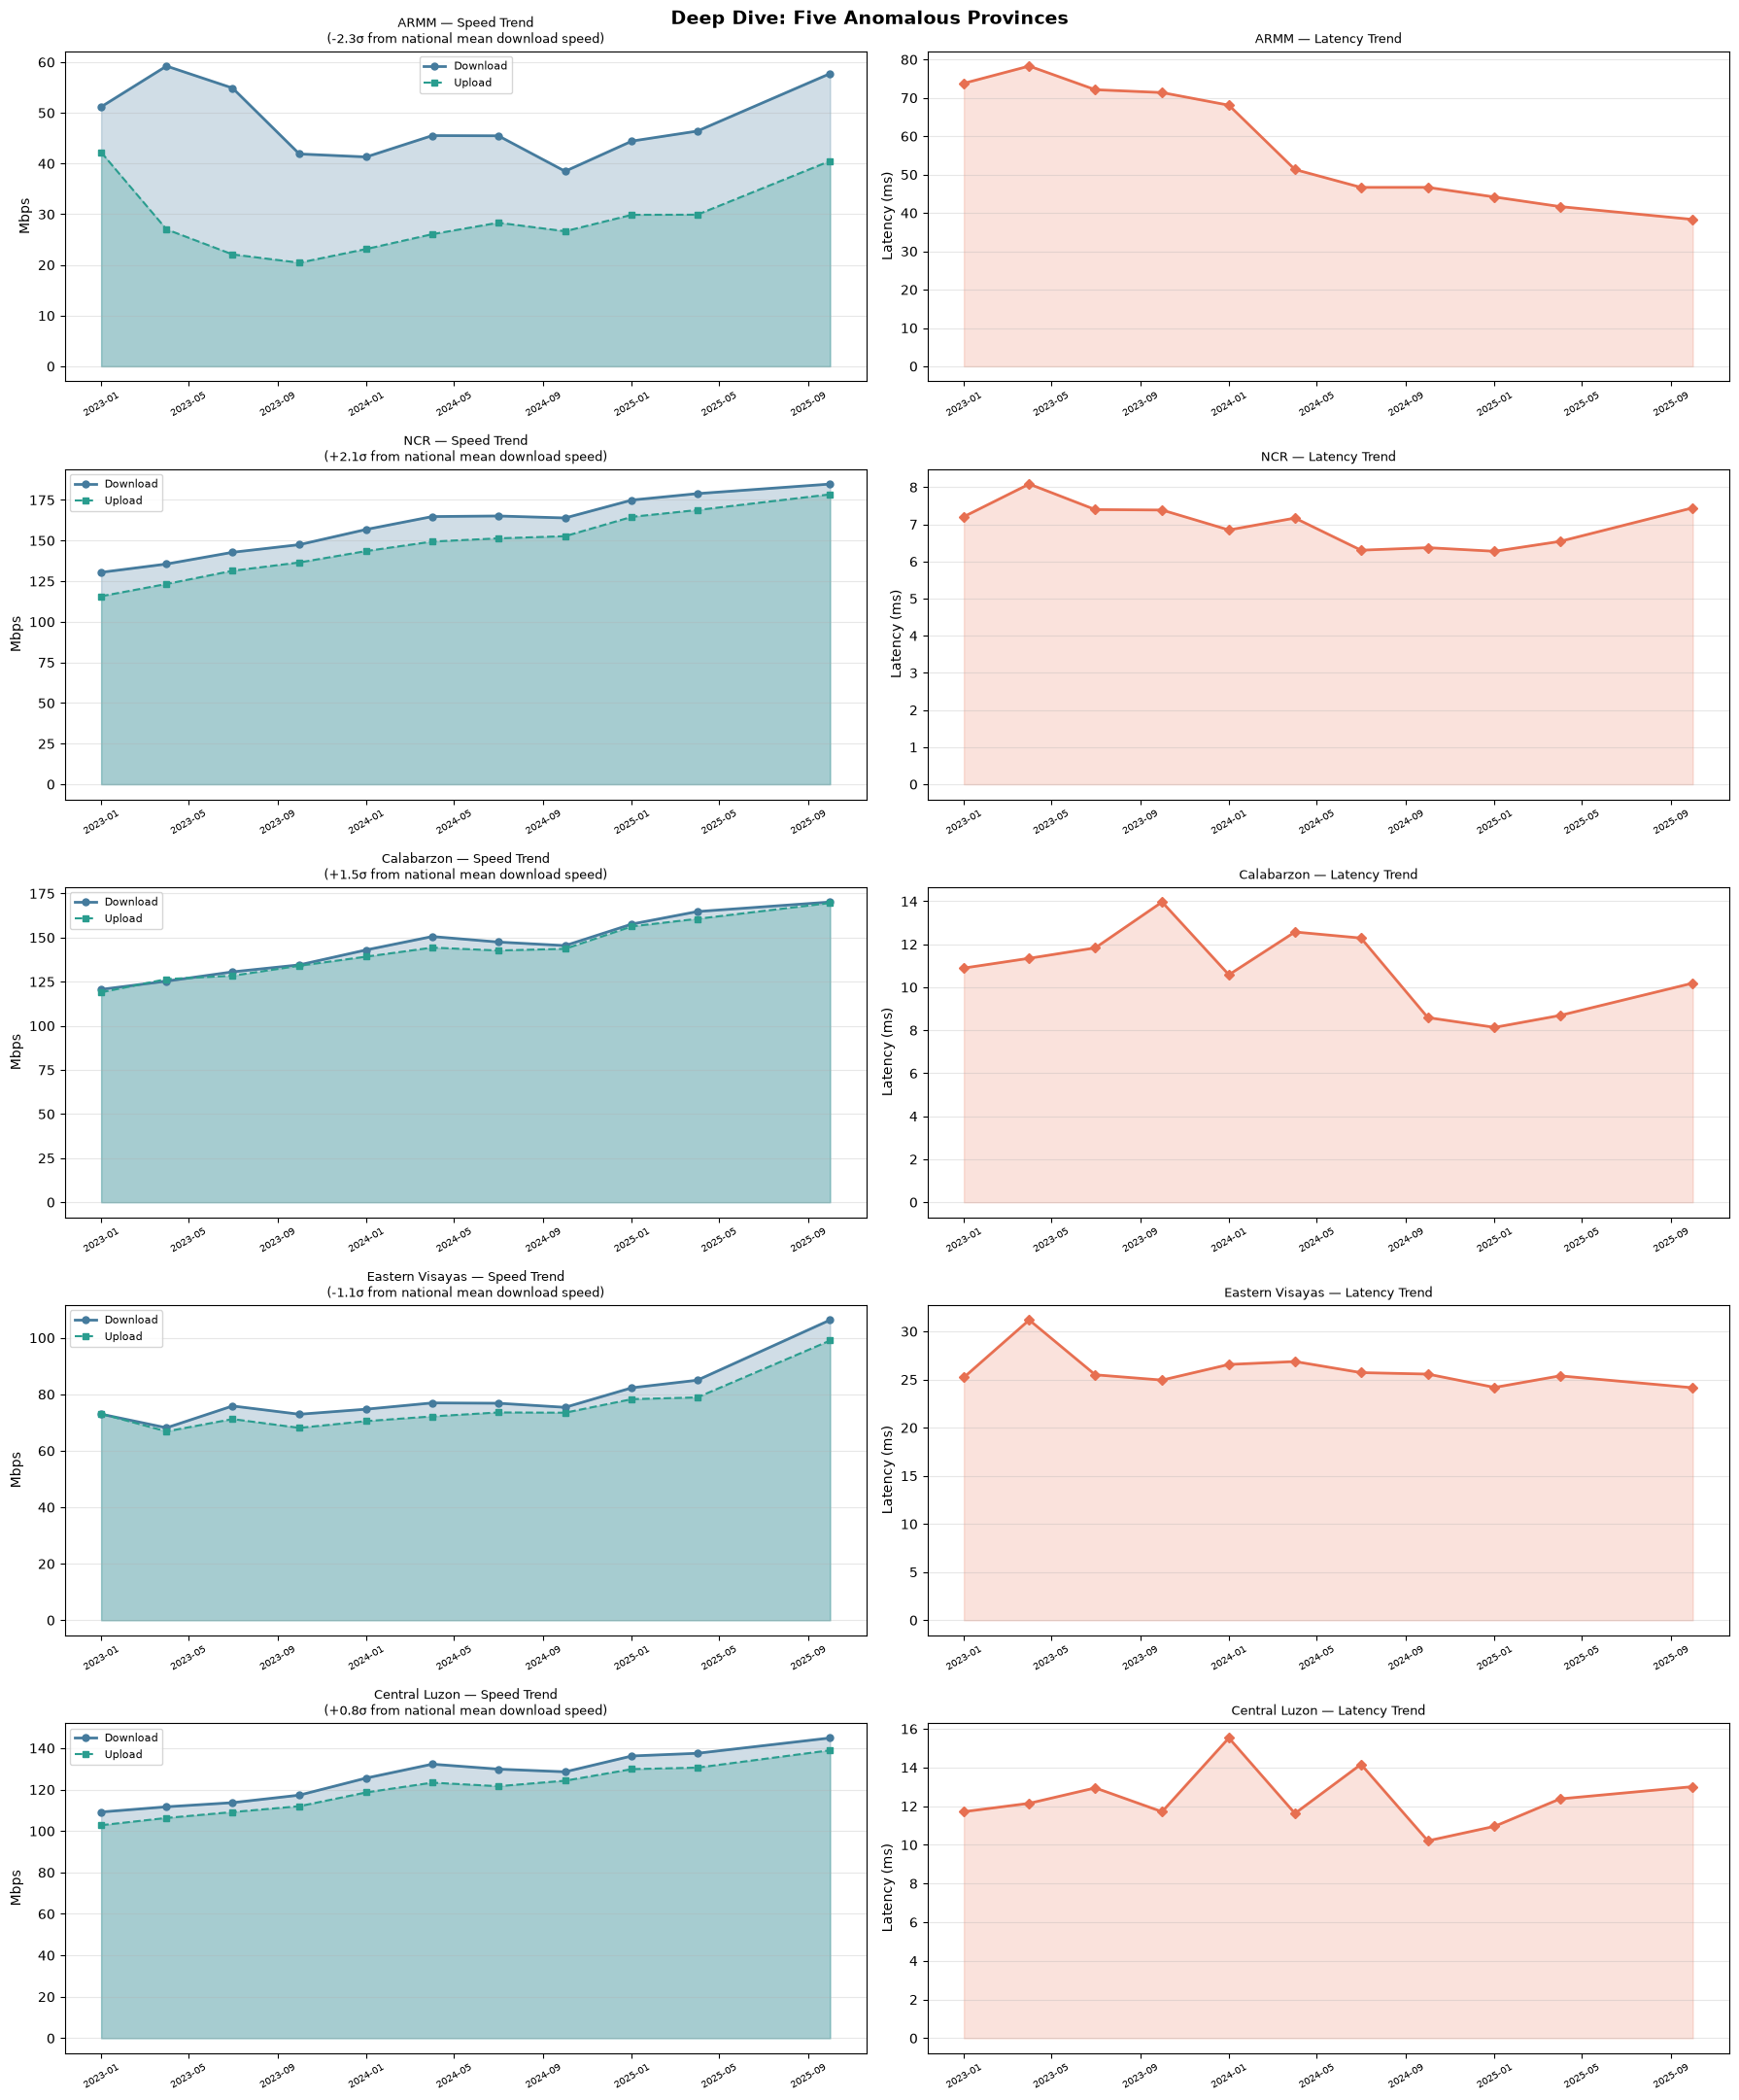

In [37]:
# Focus on the 5 most extreme performers (data-driven selection, no anomaly flags)
_pm = prov_mean.copy()
_pm['z'] = (_pm['mean_dl'] - _pm['mean_dl'].mean()) / _pm['mean_dl'].std()
_top_divergent_df = _pm.reindex(_pm['z'].abs().sort_values(ascending=False).index).head(5)
DIVERGENT = {
    row['name']: f"{row['z']:+.1f}σ from national mean download speed"
    for _, row in _top_divergent_df.iterrows()
}

fig, axes = plt.subplots(len(DIVERGENT), 2, figsize=(18, 22))

quarter_order = sorted(master['label'].unique())

for ax_row, (prov, note) in zip(axes, DIVERGENT.items()):
    df_p = master[master['name']==prov].sort_values('label')
    
    # Download + upload trend
    ax_row[0].fill_between(df_p['period_start'], df_p['avg_d_mbps'], alpha=0.25, color='#457b9d')
    ax_row[0].plot(df_p['period_start'], df_p['avg_d_mbps'], 'o-', color='#457b9d', label='Download', lw=2, markersize=5)
    ax_row[0].fill_between(df_p['period_start'], df_p['avg_u_mbps'], alpha=0.25, color='#2a9d8f')
    ax_row[0].plot(df_p['period_start'], df_p['avg_u_mbps'], 's--', color='#2a9d8f', label='Upload', lw=1.5, markersize=4)
    ax_row[0].set_title(f'{prov} — Speed Trend\n({note})', fontsize=9)
    ax_row[0].set_ylabel('Mbps'); ax_row[0].legend(fontsize=8); ax_row[0].grid(axis='y', alpha=0.3)
    ax_row[0].tick_params(axis='x', rotation=30, labelsize=7)
    
    # Latency trend
    ax_row[1].plot(df_p['period_start'], df_p['avg_lat_ms_wt'], 'D-', color='#e76f51', lw=2, markersize=5)
    ax_row[1].fill_between(df_p['period_start'], df_p['avg_lat_ms_wt'], alpha=0.2, color='#e76f51')
    ax_row[1].set_title(f'{prov} — Latency Trend', fontsize=9)
    ax_row[1].set_ylabel('Latency (ms)'); ax_row[1].grid(axis='y', alpha=0.3)
    ax_row[1].tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Deep Dive: Five Anomalous Provinces', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/21_deep_dive_divergent.png', dpi=150, bbox_inches='tight')
plt.show()


### 16. EDA Key Findings Summary

## Key Findings from EDA

---

In [38]:
from scipy import stats as scipy_stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

_DATA_ROOT = '/home/chissanupun/Desktop/Code/lab/cnc/ds/internet-measurement/data'

# Fallback: load master and prov_ref if not already in scope
if 'master' not in dir() or master is None:
    master = pd.read_parquet(f'{_DATA_ROOT}/ookla/processed/master_province_quarterly.parquet')
    print("Loaded master from processed parquet")
if 'prov_ref' not in dir() or prov_ref is None:
    prov_ref = pd.read_csv(f'{_DATA_ROOT}/reference/province_reference.csv')
    print("Loaded prov_ref from CSV")

# ── Build per-province summary (self-contained) ────────────────────────────────
divergent_df = (
    master.groupby(['name', 'region'])
    .agg(
        mean_dl=('avg_d_mbps', 'mean'),
        mean_ul=('avg_u_mbps', 'mean'),
        mean_lat=('avg_lat_ms_wt', 'mean'),
        mean_tests=('total_tests', 'mean'),
    )
    .reset_index()
)

# Temporal instability: std of quarterly download speed
temp_std = master.groupby('name')['avg_d_mbps'].std().rename('std_dl')
divergent_df = divergent_df.merge(temp_std, on='name', how='left')
divergent_df['cv_dl'] = divergent_df['std_dl'] / divergent_df['mean_dl']

# Merge reference cols
divergent_df = divergent_df.merge(
    prov_ref[['province_en','pop_2024','density_per_km2',
              'gdp_per_capita_thb_2021','internet_tier','area_km2']]
    .rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

divergent_df['ul_dl_ratio']        = divergent_df['mean_ul'] / divergent_df['mean_dl']
divergent_df['tests_per_1000_pop'] = divergent_df['mean_tests'] / divergent_df['pop_2024'] * 1_000

print(f"Provinces in analysis: {len(divergent_df)}")
print(divergent_df[['name','region','internet_tier','mean_dl','ul_dl_ratio','tests_per_1000_pop']].head(5).to_string(index=False))


Provinces in analysis: 17
          name   region  internet_tier    mean_dl  ul_dl_ratio  tests_per_1000_pop
          ARMM Mindanao              4  47.871272     0.600585            6.031418
  Bicol Region    Luzon              4  96.402879     0.960495           22.767440
           CAR    Luzon              1 121.096134     0.924621           33.797456
Cagayan Valley    Luzon              3  90.619934     0.953003           18.287956
    Calabarzon    Luzon              2 144.573994     0.983745           49.326775


In [39]:
# ── Dimension 1: Tier residual ─────────────────────────────────────────────────
tier_med = divergent_df.groupby('internet_tier')['mean_dl'].median()
divergent_df['tier_expected']   = divergent_df['internet_tier'].map(tier_med)
divergent_df['tier_residual']   = (divergent_df['mean_dl'] - divergent_df['tier_expected']) / divergent_df['tier_expected']
divergent_df['tier_residual_z'] = (divergent_df['tier_residual'] - divergent_df['tier_residual'].mean()) / divergent_df['tier_residual'].std()

# ── Dimension 2: GDP residual (OLS on log-GDP) ─────────────────────────────────
log_gdp = np.log(divergent_df['gdp_per_capita_thb_2021'])
if log_gdp.nunique() > 1:
    slope_g, int_g, r_g, p_g, _ = scipy_stats.linregress(log_gdp, divergent_df['mean_dl'])
    divergent_df['gdp_expected']   = int_g + slope_g * log_gdp
    divergent_df['gdp_residual']   = divergent_df['mean_dl'] - divergent_df['gdp_expected']
    divergent_df['gdp_residual_z'] = scipy_stats.zscore(divergent_df['gdp_residual'])
else:
    # GDP per capita uniform across regions (e.g. Singapore: national-only data) — dimension contributes nothing
    slope_g, int_g, r_g, p_g = 0.0, divergent_df['mean_dl'].mean(), float('nan'), float('nan')
    divergent_df['gdp_expected']   = int_g
    divergent_df['gdp_residual']   = 0.0
    divergent_df['gdp_residual_z'] = 0.0

# ── Dimension 3: Density residual (OLS on log-density) ────────────────────────
log_den = np.log1p(divergent_df['density_per_km2'])
slope_d, int_d, r_d, p_d, _ = scipy_stats.linregress(log_den, divergent_df['mean_dl'])
divergent_df['den_expected']   = int_d + slope_d * log_den
divergent_df['den_residual_z'] = scipy_stats.zscore(divergent_df['mean_dl'] - divergent_df['den_expected'])

# ── Dimension 4: Regional z-score (speed within region) ───────────────────────
divergent_df['regional_z'] = divergent_df.groupby('region')['mean_dl'].transform(
    lambda x: scipy_stats.zscore(x) if len(x) > 1 else pd.Series(np.zeros(len(x)), index=x.index)
)

# ── Dimension 5: UL/DL ratio z-score ──────────────────────────────────────────
divergent_df['ratio_z'] = scipy_stats.zscore(divergent_df['ul_dl_ratio'])

# ── Dimension 6: Within-region latency z-score ────────────────────────────────
divergent_df['lat_regional_z'] = divergent_df.groupby('region')['mean_lat'].transform(
    lambda x: scipy_stats.zscore(x) if len(x) > 1 else pd.Series(np.zeros(len(x)), index=x.index)
)

# ── Dimension 7: Coverage z-score (tests per 1000 pop) ────────────────────────
divergent_df['coverage_z'] = scipy_stats.zscore(divergent_df['tests_per_1000_pop'])

# ── Composite divergence score (sum of absolute z-scores) ──────────────────────
divergent_df['divergence_score'] = (
    np.abs(divergent_df['tier_residual_z']) +
    np.abs(divergent_df['gdp_residual_z']) +
    np.abs(divergent_df['den_residual_z']) +
    np.abs(divergent_df['regional_z']) +
    np.abs(divergent_df['ratio_z']) +
    np.abs(divergent_df['lat_regional_z']) +
    np.abs(divergent_df['coverage_z'])
)

print(f"GDP-speed OLS:     r = {r_g:.3f}, slope = {slope_g:.2f} Mbps per log-unit GDP")
print(f"Density-speed OLS: r = {r_d:.3f}, slope = {slope_d:.2f} Mbps per log-unit density")
print()
print("Top 15 divergentest provinces:")
cols = ['name','region','internet_tier','mean_dl','divergence_score',
        'gdp_residual_z','den_residual_z','regional_z','ratio_z','lat_regional_z','coverage_z']
print(divergent_df.nlargest(15,'divergence_score')[cols].to_string(index=False))


GDP-speed OLS:     r = 0.889, slope = 51.56 Mbps per log-unit GDP
Density-speed OLS: r = 0.621, slope = 12.83 Mbps per log-unit density

Top 15 divergentest provinces:
               name   region  internet_tier    mean_dl  divergence_score  gdp_residual_z  den_residual_z  regional_z   ratio_z  lat_regional_z  coverage_z
               ARMM Mindanao              4  47.871272         16.048267       -1.208129       -3.003350   -2.040224 -3.767076        2.096504   -1.270614
                NCR    Luzon              1 158.695259          9.066621       -0.978990       -0.015383    1.758574  0.094728       -1.229049    3.008844
         Calabarzon    Luzon              2 144.573994          8.779266        2.552201        1.347280    1.133267  0.785047       -0.748262    1.201332
    Eastern Visayas  Visayas              4  78.869958          5.729309       -0.680340       -1.048298   -1.210168  0.400588        1.319806   -0.372026
    Central Visayas  Visayas              2 122.075940   

### 18. Tier vs Actual Speed — Expectation Gap

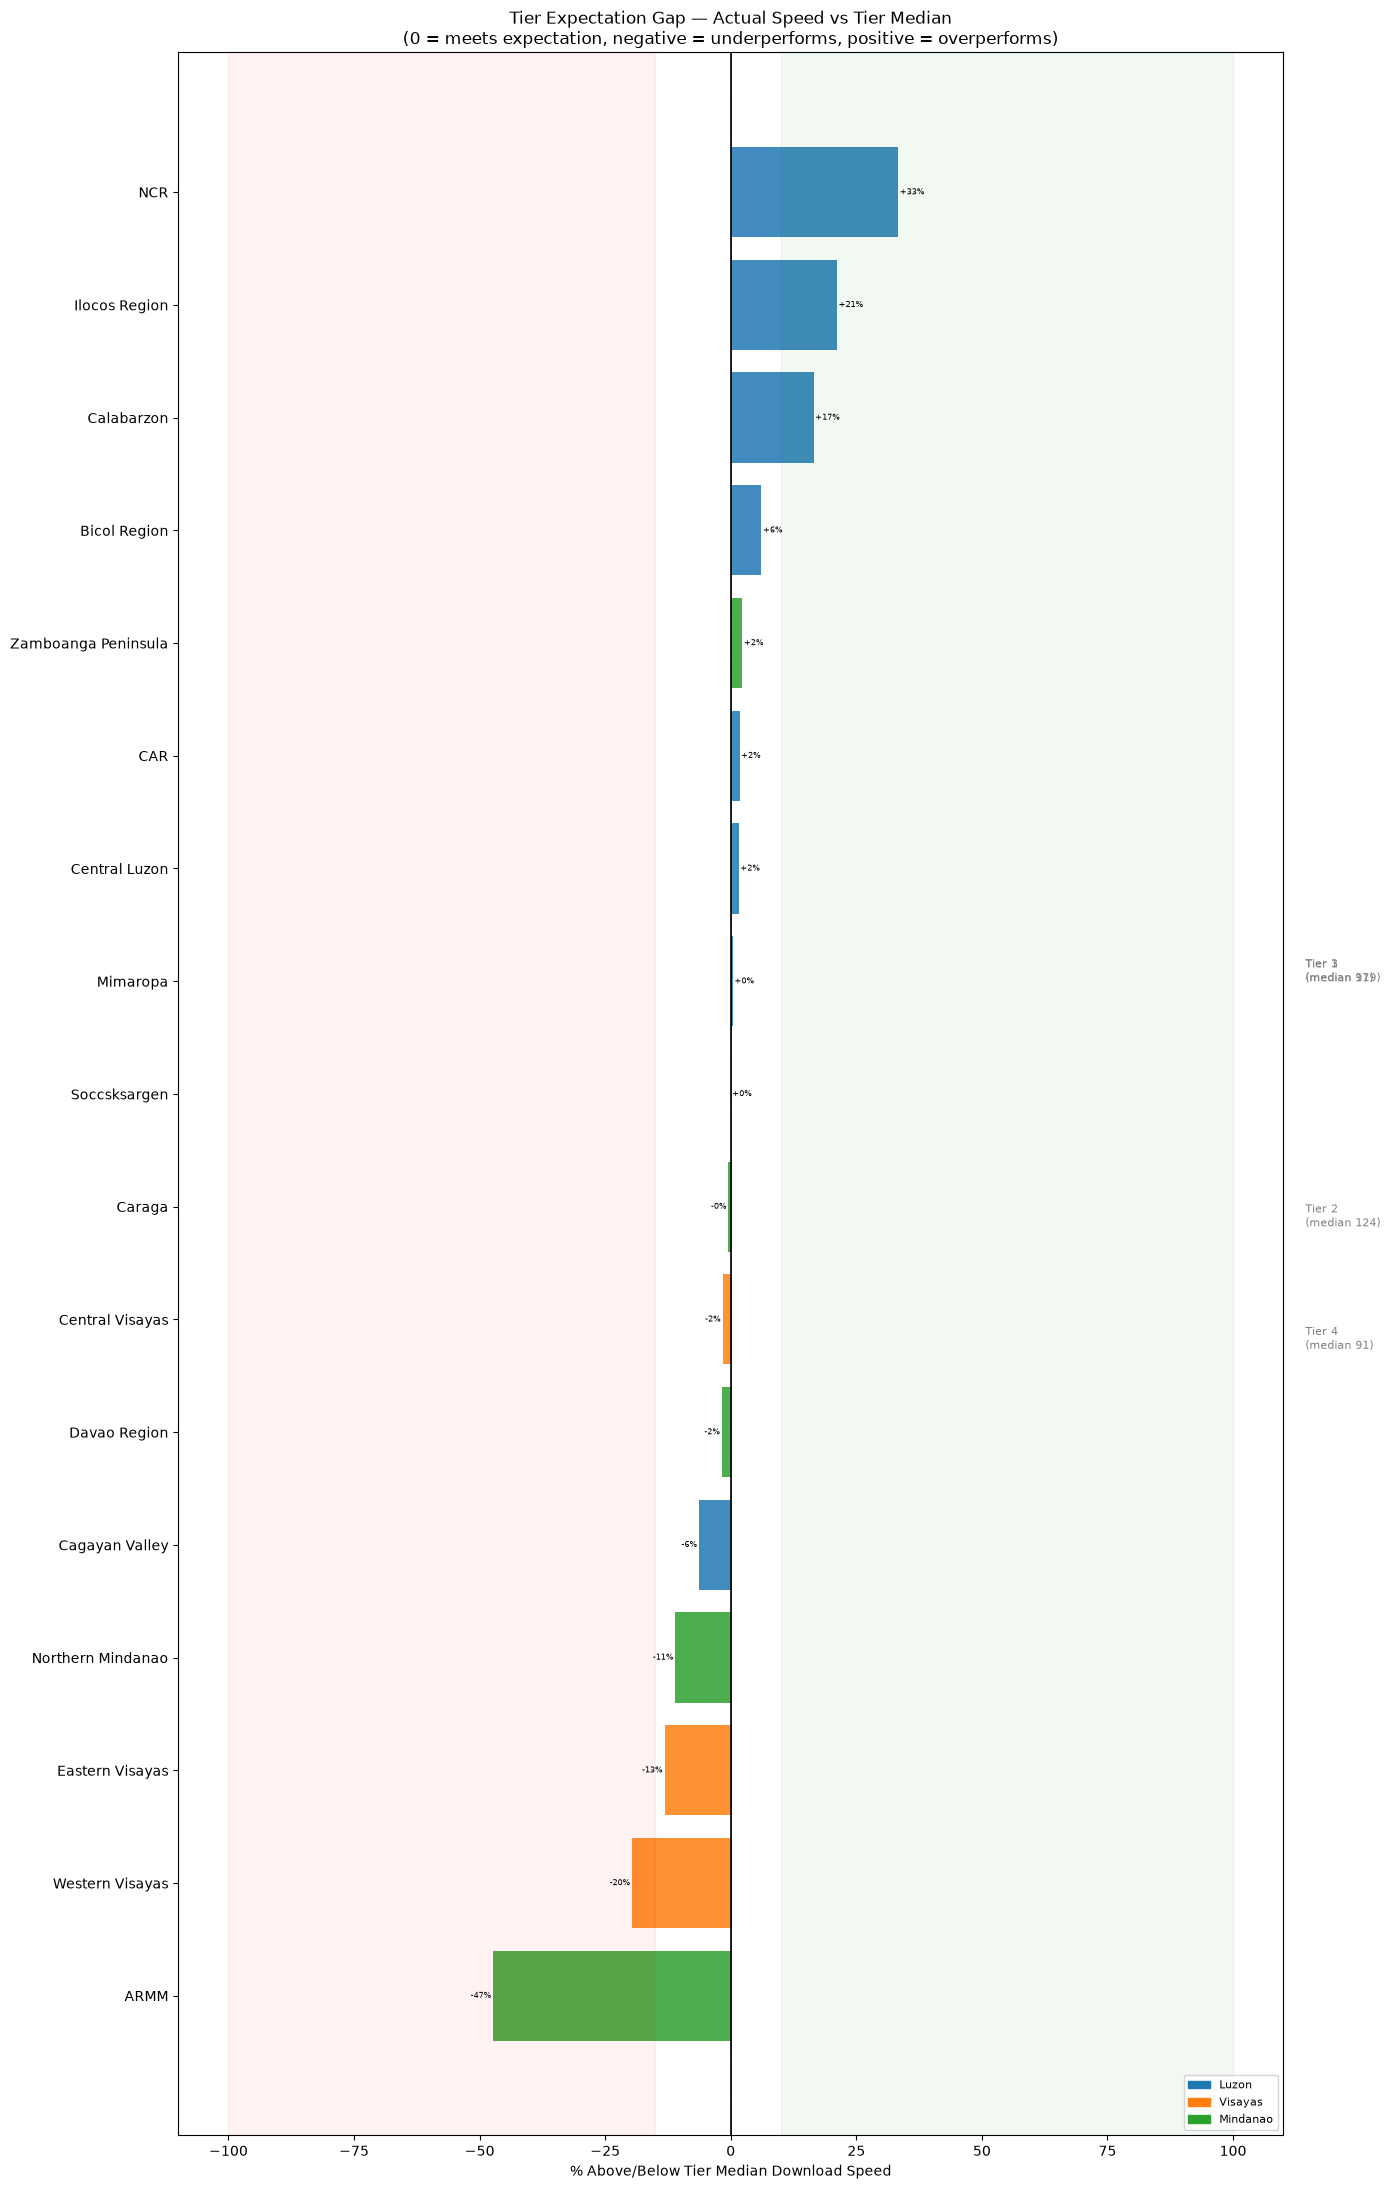

Biggest underperformers vs tier expectation:
             name  internet_tier    mean_dl  tier_expected  tier_residual
             ARMM              4  47.871272      90.846705      -0.473054
  Western Visayas              2  99.714761     124.075985      -0.196341
  Eastern Visayas              4  78.869958      90.846705      -0.131835
Northern Mindanao              1 105.883838     119.001001      -0.110227
   Cagayan Valley              3  90.619934      96.733008      -0.063195
     Davao Region              1 116.905867     119.001001      -0.017606
  Central Visayas              2 122.075940     124.075985      -0.016120
           Caraga              3  96.294185      96.733008      -0.004536

Biggest overperformers vs tier expectation:
               name  internet_tier    mean_dl  tier_expected  tier_residual
                NCR              1 158.695259     119.001001       0.333562
      Ilocos Region              3 117.215790      96.733008       0.211746
         Calabar

In [40]:
# Show each province's % deviation from its tier median
tier_gap = divergent_df[['name','region','internet_tier','mean_dl','tier_expected','tier_residual']].copy()
tier_gap = tier_gap.sort_values('tier_residual')

fig, ax = plt.subplots(figsize=(14, 22))

region_colors = {
    'Luzon': '#1f77b4',
    'Visayas': '#ff7f0e',
    'Mindanao': '#2ca02c',
}

colors = [region_colors.get(r, 'gray') for r in tier_gap['region']]
bars = ax.barh(tier_gap['name'], tier_gap['tier_residual'] * 100, color=colors, alpha=0.85)

# Tier median reference lines
ax.axvline(0, color='black', lw=1.2, label='Tier median (expected)')

# Annotate bars
for bar, val in zip(bars, tier_gap['tier_residual']):
    x = bar.get_width()
    ax.text(x + (0.3 if x >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
            f'{val*100:+.0f}%', va='center', ha='left' if x >= 0 else 'right', fontsize=6)

# Tier grouping lines
tier_boundaries = tier_gap.groupby('internet_tier').apply(lambda g: (g.index.min(), g.index.max()))
for t in sorted(tier_gap['internet_tier'].unique()):
    grp = tier_gap[tier_gap['internet_tier'] == t]
    median = tier_med[t]
    ax.axvline(0, color='black', lw=0.4, ls='--', alpha=0.4)

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, fontsize=8, loc='lower right')
ax.set_xlabel('% Above/Below Tier Median Download Speed')
ax.set_title('Tier Expectation Gap — Actual Speed vs Tier Median\n'
             '(0 = meets expectation, negative = underperforms, positive = overperforms)', fontsize=12)
ax.axvspan(-100, -15, alpha=0.05, color='red', label='Strong underperform')
ax.axvspan(10, 100, alpha=0.05, color='green')

# Annotate Tier brackets on y-axis
for t in sorted(tier_gap['internet_tier'].unique()):
    grp_idx = tier_gap[tier_gap['internet_tier']==t].index
    grp_pos = [list(tier_gap.index).index(i) for i in grp_idx]
    if grp_pos:
        mid = (min(grp_pos) + max(grp_pos)) / 2
        ax.annotate(f'Tier {t}\n(median {tier_med[t]:.0f})', xy=(1.02, mid/len(tier_gap)),
                    xycoords='axes fraction', va='center', fontsize=8, color='gray')

plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/22_tier_expectation_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Biggest underperformers vs tier expectation:")
print(tier_gap.nsmallest(8,'tier_residual')[['name','internet_tier','mean_dl','tier_expected','tier_residual']].to_string(index=False))
print()
print("Biggest overperformers vs tier expectation:")
print(tier_gap.nlargest(8,'tier_residual')[['name','internet_tier','mean_dl','tier_expected','tier_residual']].to_string(index=False))


### 19. GDP per Capita vs Download Speed — Who Breaks the Rule?

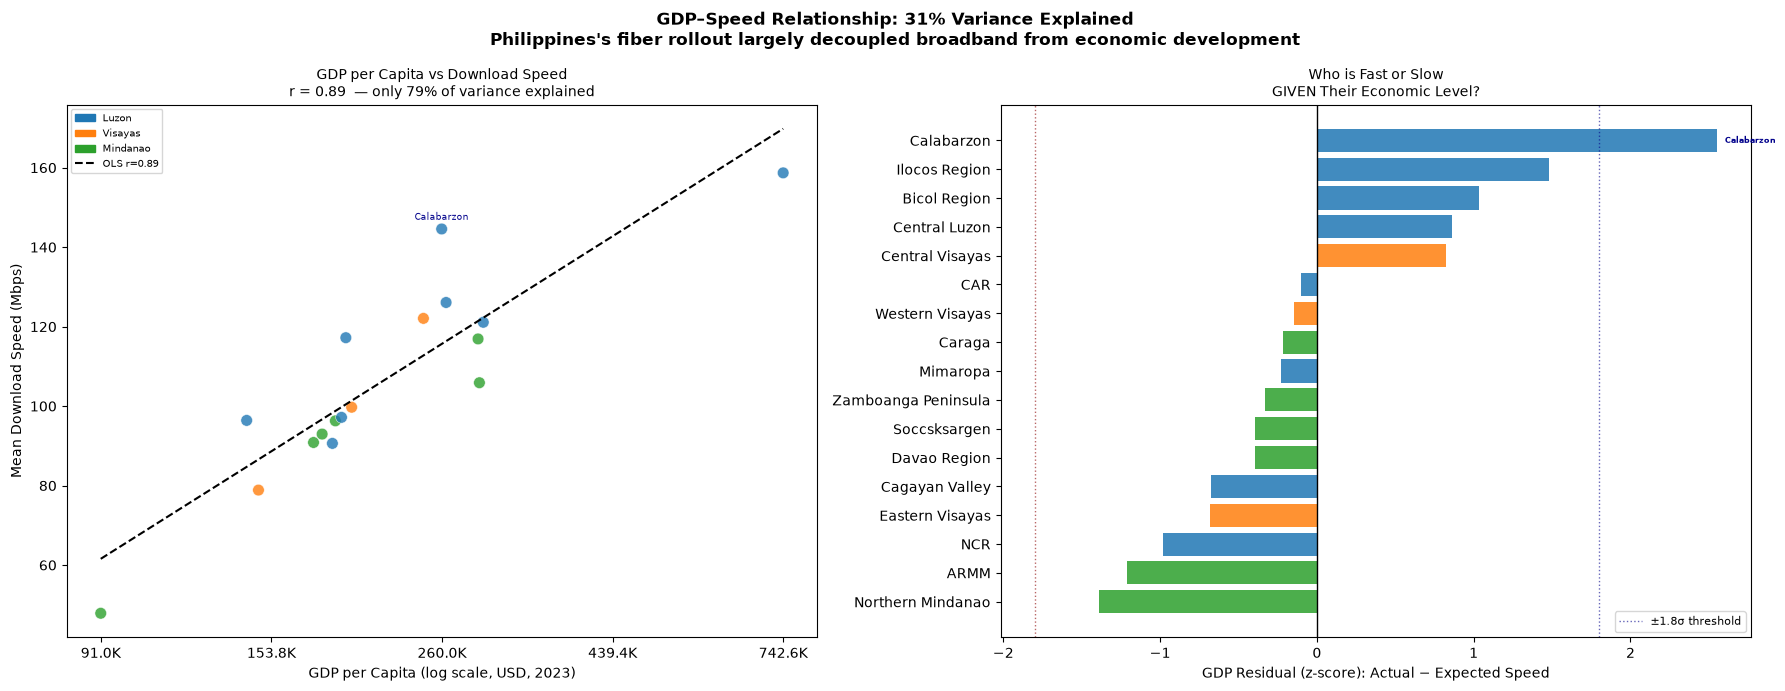

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: GDP scatter ──────────────────────────────────────────────────────────
ax = axes[0]
gdp_vals = divergent_df['gdp_per_capita_thb_2021']
colors_scatter = [region_colors.get(r, 'gray') for r in divergent_df['region']]

sc = ax.scatter(np.log(gdp_vals), divergent_df['mean_dl'],
                c=colors_scatter, s=70, alpha=0.8, edgecolors='white', lw=0.4)

# OLS line
x_fit = np.linspace(np.log(gdp_vals.min()), np.log(gdp_vals.max()), 200)
ax.plot(x_fit, int_g + slope_g * x_fit, 'k--', lw=1.5,
        label=f'OLS fit  r={r_g:.2f}')

# Label big residuals
threshold = 1.8
for _, row in divergent_df.iterrows():
    if abs(row['gdp_residual_z']) > threshold:
        ax.annotate(row['name'],
                    (np.log(row['gdp_per_capita_thb_2021']), row['mean_dl']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    color='darkred' if row['gdp_residual_z'] < 0 else 'darkblue')

ax.set_xlabel('GDP per Capita (log scale, USD, 2023)')
ax.set_ylabel('Mean Download Speed (Mbps)')
ax.set_title(f'GDP per Capita vs Download Speed\nr = {r_g:.2f}  — only {r_g**2*100:.0f}% of variance explained',
             fontsize=10)

# x-tick labels spaced across the actual data range (log scale)
_tick_vals = np.geomspace(gdp_vals.min(), gdp_vals.max(), 5)
ax.set_xticks(np.log(_tick_vals))
ax.set_xticklabels([f'{v/1000:.1f}K' if v >= 1000 else f'{v:.0f}' for v in _tick_vals])

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',label=f'OLS r={r_g:.2f}')],
          fontsize=7)

# ── Right: residual bar chart ──────────────────────────────────────────────────
ax2 = axes[1]
resid_sorted = divergent_df.sort_values('gdp_residual_z')
cols2 = [region_colors.get(r, 'gray') for r in resid_sorted['region']]
bars2 = ax2.barh(resid_sorted['name'], resid_sorted['gdp_residual_z'], color=cols2, alpha=0.85)
ax2.axvline(0, color='black', lw=1)
ax2.axvline(1.8, color='darkblue', ls=':', lw=1, alpha=0.6, label='±1.8σ threshold')
ax2.axvline(-1.8, color='darkred', ls=':', lw=1, alpha=0.6)
ax2.set_xlabel('GDP Residual (z-score): Actual − Expected Speed')
ax2.set_title('Who is Fast or Slow\nGIVEN Their Economic Level?', fontsize=10)
ax2.legend(fontsize=8)
# Add province labels for outliers
for bar, (_, row) in zip(bars2, resid_sorted.iterrows()):
    if abs(row['gdp_residual_z']) > 1.8:
        x = bar.get_width()
        ax2.text(x + (0.05 if x >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                 row['name'], va='center', ha='left' if x >= 0 else 'right', fontsize=5.5,
                 color='darkblue' if x > 0 else 'darkred', fontweight='bold')

plt.suptitle('GDP–Speed Relationship: 31% Variance Explained\n'
             'Philippines\'s fiber rollout largely decoupled broadband from economic development',
             fontsize=12, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/23_gdp_residual_bar.png', dpi=150, bbox_inches='tight')
plt.show()


### 20. Population Density vs Speed — Greenfield Fiber Effect

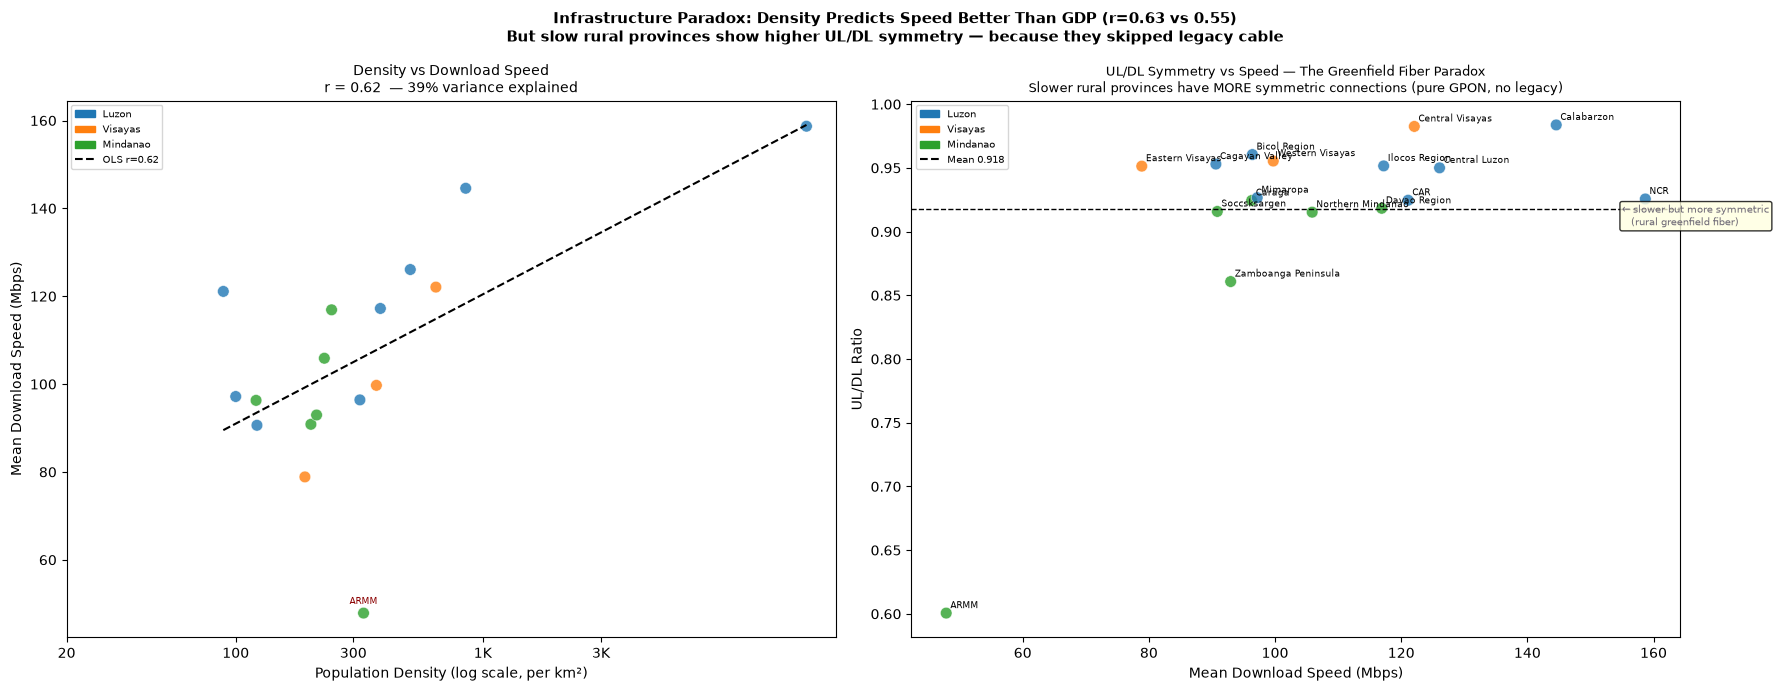

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Density scatter ──────────────────────────────────────────────────────
ax = axes[0]
den_vals = divergent_df['density_per_km2']
colors_s = [region_colors.get(r, 'gray') for r in divergent_df['region']]

ax.scatter(np.log1p(den_vals), divergent_df['mean_dl'],
           c=colors_s, s=70, alpha=0.8, edgecolors='white', lw=0.4)

x_fit2 = np.linspace(np.log1p(den_vals.min()), np.log1p(den_vals.max()), 200)
ax.plot(x_fit2, int_d + slope_d * x_fit2, 'k--', lw=1.5, label=f'OLS r={r_d:.2f}')

for _, row in divergent_df.iterrows():
    if abs(row['den_residual_z']) > 2.0:
        ax.annotate(row['name'],
                    (np.log1p(row['density_per_km2']), row['mean_dl']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    color='darkred' if row['den_residual_z'] < 0 else 'darkblue')

xticks_den = np.log1p([20, 100, 300, 1000, 3000])
ax.set_xticks(xticks_den)
ax.set_xticklabels(['20','100','300','1K','3K'])
ax.set_xlabel('Population Density (log scale, per km²)')
ax.set_ylabel('Mean Download Speed (Mbps)')
ax.set_title(f'Density vs Download Speed\nr = {r_d:.2f}  — {r_d**2*100:.0f}% variance explained', fontsize=10)
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',label=f'OLS r={r_d:.2f}')],
          fontsize=7)

# ── Right: UL/DL ratio vs DL speed — the "greenfield fiber paradox" ───────────
ax2 = axes[1]
ax2.scatter(divergent_df['mean_dl'], divergent_df['ul_dl_ratio'],
            c=colors_s, s=70, alpha=0.8, edgecolors='white', lw=0.4)

for _, row in divergent_df.iterrows():
    if row['ul_dl_ratio'] > 0.91 or row['ul_dl_ratio'] < 0.80 or row['mean_dl'] < 170:
        ax2.annotate(row['name'], (row['mean_dl'], row['ul_dl_ratio']),
                     fontsize=6.5, ha='left', va='bottom',
                     xytext=(3, 2), textcoords='offset points')

ax2.axhline(divergent_df['ul_dl_ratio'].mean(), color='black', ls='--', lw=1,
            label=f"Mean ratio {divergent_df['ul_dl_ratio'].mean():.3f}")
ax2.set_xlabel('Mean Download Speed (Mbps)')
ax2.set_ylabel('UL/DL Ratio')
ax2.set_title('UL/DL Symmetry vs Speed — The Greenfield Fiber Paradox\n'
              'Slower rural provinces have MORE symmetric connections (pure GPON, no legacy)', fontsize=9)
ax2.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',
           label=f'Mean {divergent_df["ul_dl_ratio"].mean():.3f}')], fontsize=7)

# Add trend arrow annotation
ax2.annotate('← slower but more symmetric\n   (rural greenfield fiber)',
             xy=(155, 0.905), fontsize=7.5, color='#6d6875',
             bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))
ax2.annotate('faster but less symmetric →\n(urban legacy cable mix)',
             xy=(285, 0.800), fontsize=7.5, color='#e63946',
             bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))

plt.suptitle('Infrastructure Paradox: Density Predicts Speed Better Than GDP (r=0.63 vs 0.55)\n'
             'But slow rural provinces show higher UL/DL symmetry — because they skipped legacy cable',
             fontsize=11, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/24_uldl_greenfield.png', dpi=150, bbox_inches='tight')
plt.show()


### 21. Ookla Coverage — Tests per 1,000 Population

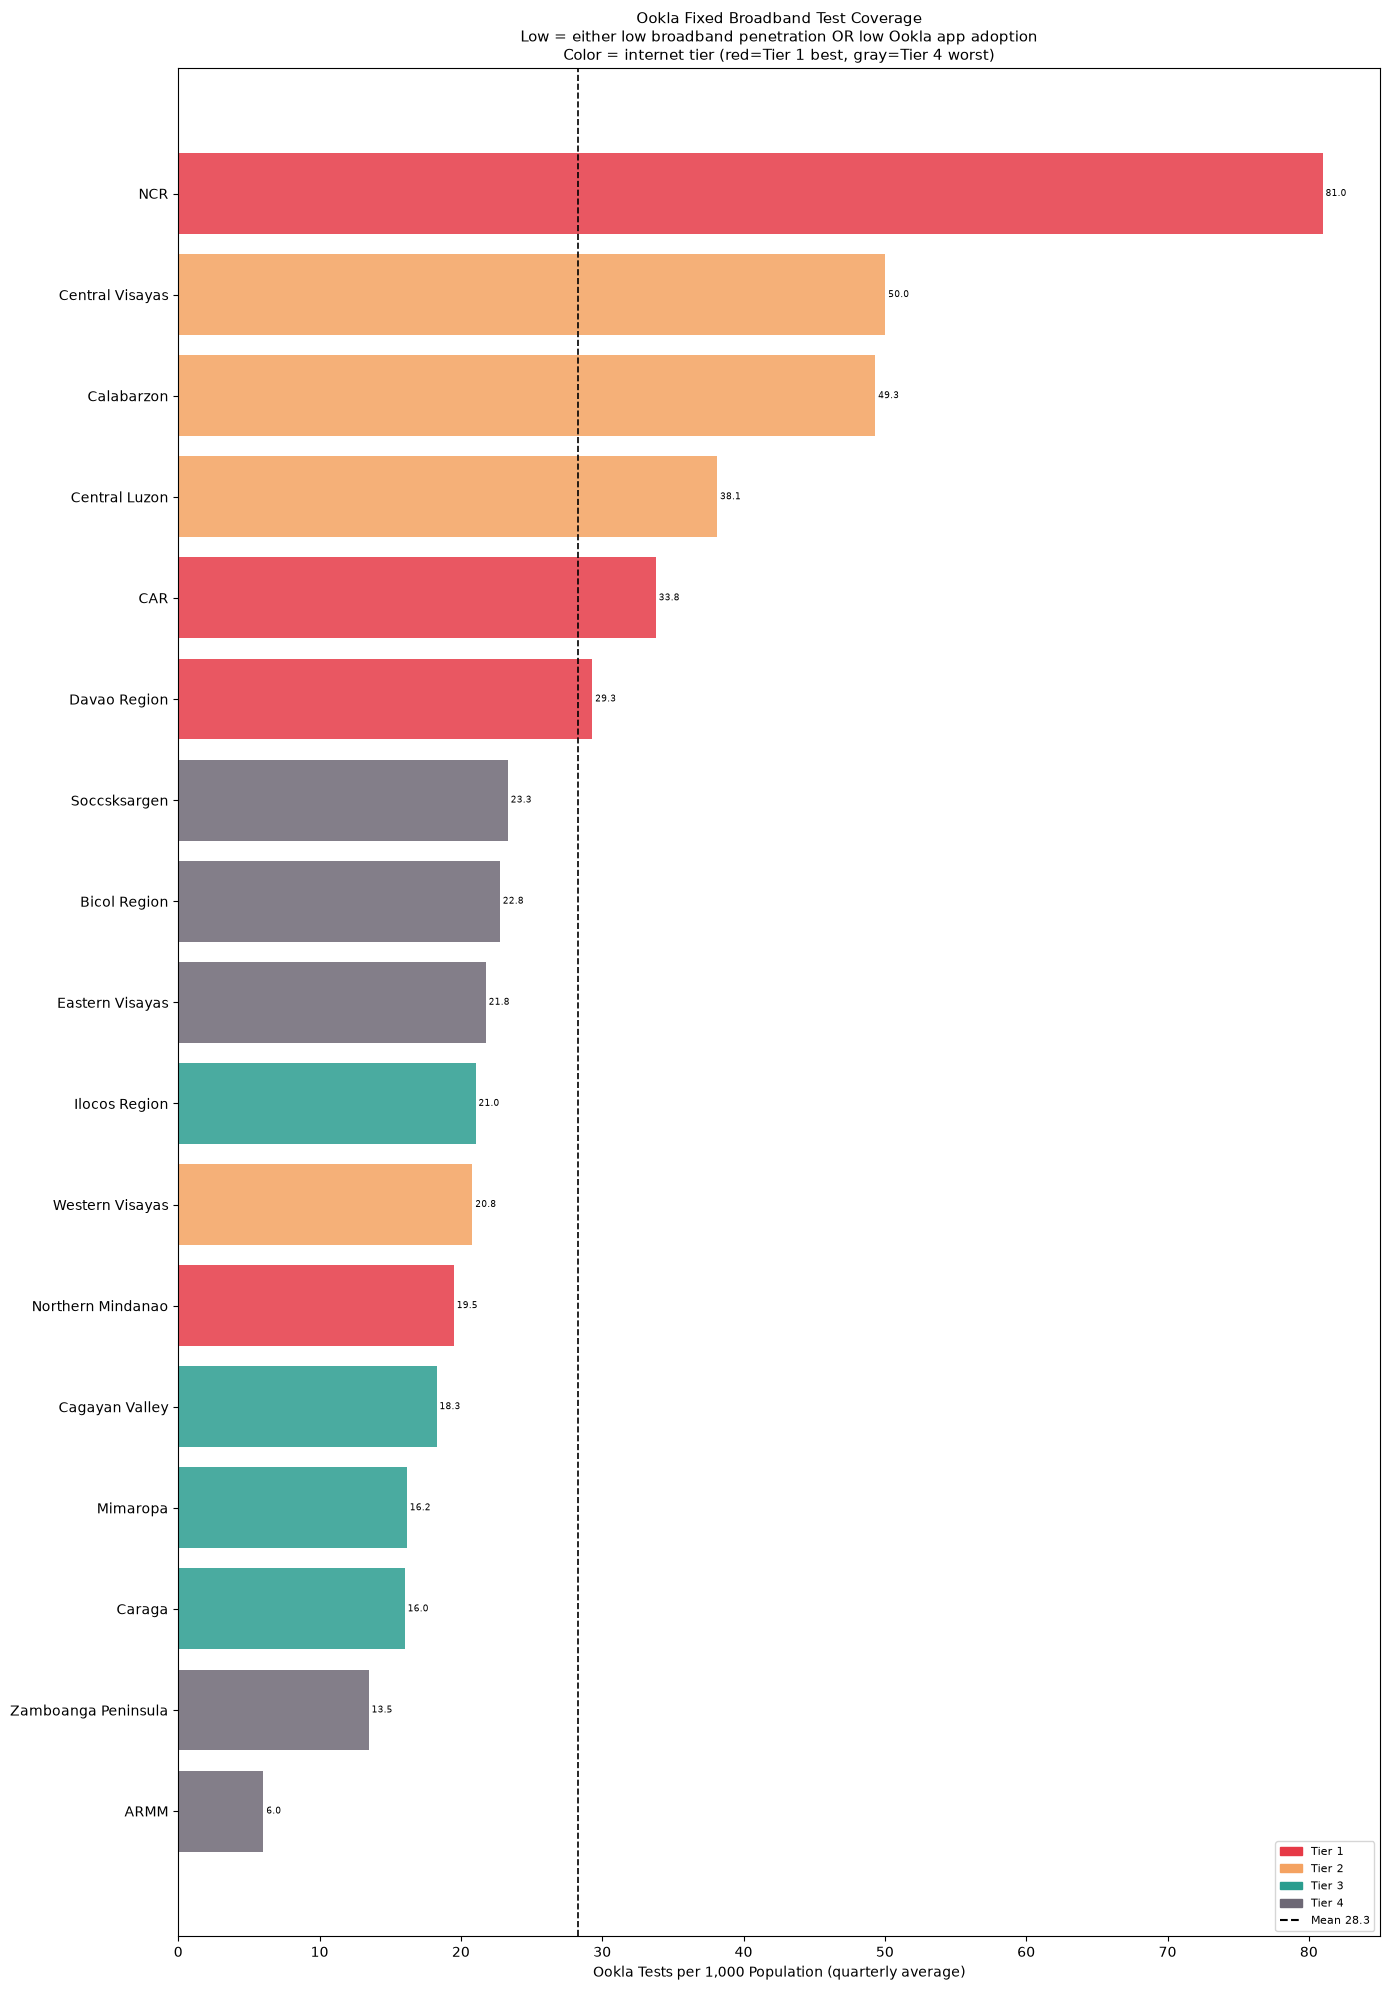

Top coverage (tests per 1000 pop):
           name   region  internet_tier  tests_per_1000_pop   mean_tests  pop_2024
            NCR    Luzon              1           80.984774 1.133929e+06  14001751
Central Visayas  Visayas              2           50.041119 3.323168e+05   6640875
     Calabarzon    Luzon              2           49.326775 8.352618e+05  16933234
  Central Luzon    Luzon              2           38.134932 4.953375e+05  12989074
            CAR    Luzon              1           33.797456 6.113909e+04   1808985
   Davao Region Mindanao              1           29.304526 1.579345e+05   5389422
   Soccsksargen Mindanao              4           23.328468 1.041097e+05   4462776
   Bicol Region    Luzon              4           22.767440 1.380715e+05   6064426

Bottom coverage:
               name   region  internet_tier  tests_per_1000_pop    mean_tests  pop_2024
               ARMM Mindanao              4            6.031418  27415.727273   4545486
Zamboanga Peninsula Mind

In [43]:
# Tests per 1000 pop = proxy for (broadband penetration × Ookla app adoption × tech-savviness)
cov = divergent_df.sort_values('tests_per_1000_pop')
tier_palette = {1:'#e63946', 2:'#f4a261', 3:'#2a9d8f', 4:'#6d6875'}
colors_cov = [tier_palette.get(int(t), 'gray') for t in cov['internet_tier']]

fig, ax = plt.subplots(figsize=(14, 20))
bars = ax.barh(cov['name'], cov['tests_per_1000_pop'], color=colors_cov, alpha=0.85)
ax.axvline(divergent_df['tests_per_1000_pop'].mean(), color='black', ls='--', lw=1.2,
           label=f"National mean {divergent_df['tests_per_1000_pop'].mean():.1f}")

for bar, val in zip(bars, cov['tests_per_1000_pop']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=6.2)

patches_t = [mpatches.Patch(color=v, label=f'Tier {k}') for k, v in tier_palette.items()]
ax.legend(handles=patches_t + [plt.Line2D([0],[0],color='black',ls='--',
           label=f'Mean {divergent_df["tests_per_1000_pop"].mean():.1f}')], fontsize=8)
ax.set_xlabel('Ookla Tests per 1,000 Population (quarterly average)')
ax.set_title('Ookla Fixed Broadband Test Coverage\n'
             'Low = either low broadband penetration OR low Ookla app adoption\n'
             'Color = internet tier (red=Tier 1 best, gray=Tier 4 worst)', fontsize=11)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/25_test_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top coverage (tests per 1000 pop):")
print(divergent_df.nlargest(8,'tests_per_1000_pop')[
    ['name','region','internet_tier','tests_per_1000_pop','mean_tests','pop_2024']
].to_string(index=False))
print()
print("Bottom coverage:")
print(divergent_df.nsmallest(10,'tests_per_1000_pop')[
    ['name','region','internet_tier','tests_per_1000_pop','mean_tests','pop_2024']
].to_string(index=False))


### 22. Composite Divergence Leaderboard — Top 20 Anomalous Provinces

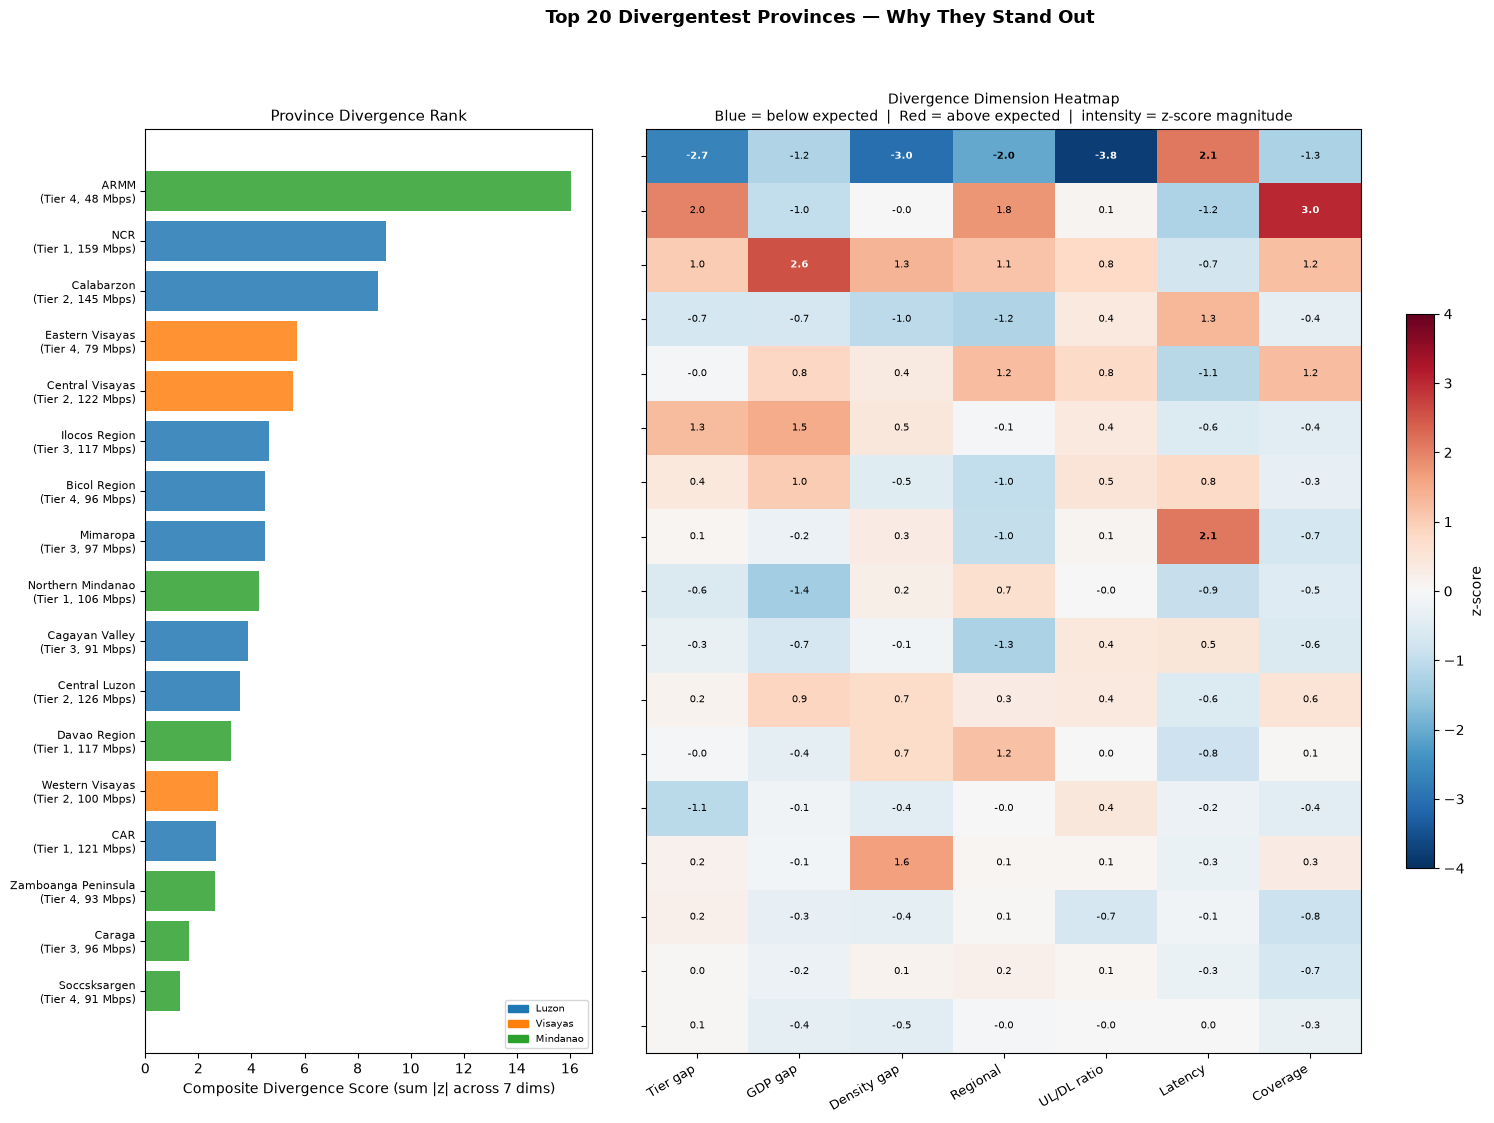


Full leaderboard table:
               name   region  internet_tier    mean_dl  divergence_score     GDP-z     Den-z     Reg-z   Ratio-z     Lat-z     Cov-z
               ARMM Mindanao              4  47.871272         16.048267 -1.208129 -3.003350 -2.040224 -3.767076  2.096504 -1.270614
                NCR    Luzon              1 158.695259          9.066621 -0.978990 -0.015383  1.758574  0.094728 -1.229049  3.008844
         Calabarzon    Luzon              2 144.573994          8.779266  2.552201  1.347280  1.133267  0.785047 -0.748262  1.201332
    Eastern Visayas  Visayas              4  78.869958          5.729309 -0.680340 -1.048298 -1.210168  0.400588  1.319806 -0.372026
    Central Visayas  Visayas              2 122.075940          5.579256  0.823114  0.372354  1.238819  0.771016 -1.099885  1.242118
      Ilocos Region    Luzon              3 117.215790          4.668405  1.479645  0.462539 -0.078187  0.402999 -0.551892 -0.413350
       Bicol Region    Luzon              4 

In [44]:
TOP_N = min(20, len(divergent_df))
dims = ['tier_residual_z','gdp_residual_z','den_residual_z','regional_z',
        'ratio_z','lat_regional_z','coverage_z']
dim_labels = ['Tier gap','GDP gap','Density gap','Regional','UL/DL ratio','Latency','Coverage']

top20 = divergent_df.nlargest(TOP_N, 'divergence_score').copy().reset_index(drop=True)

fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 2], wspace=0.08)

region_colors = {
    'Luzon': '#1f77b4',
    'Visayas': '#ff7f0e',
    'Mindanao': '#2ca02c',
}

# ── Left: Composite score bar ──────────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[0])
colors_bar = [region_colors.get(r, 'gray') for r in top20['region']]
y_pos = np.arange(TOP_N)
ax_bar.barh(y_pos, top20['divergence_score'], color=colors_bar, alpha=0.85)
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(
    [f"{row['name']}\n(Tier {int(row['internet_tier'])}, {row['mean_dl']:.0f} Mbps)"
     for _, row in top20.iterrows()],
    fontsize=8
)
ax_bar.set_xlabel('Composite Divergence Score (sum |z| across 7 dims)')
ax_bar.set_title('Province Divergence Rank', fontsize=11)
ax_bar.invert_yaxis()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax_bar.legend(handles=patches, fontsize=7, loc='lower right')

# ── Right: Heatmap of dimension z-scores ──────────────────────────────────────
ax_heat = fig.add_subplot(gs[1])
heat_data = top20[dims].values.astype(float)

im = ax_heat.imshow(heat_data, cmap='RdBu_r', aspect='auto', vmin=-4, vmax=4)
ax_heat.set_xticks(np.arange(len(dim_labels)))
ax_heat.set_xticklabels(dim_labels, rotation=30, ha='right', fontsize=9)
ax_heat.set_yticks(np.arange(TOP_N))
ax_heat.set_yticklabels([''] * TOP_N)

for i in range(TOP_N):
    for j in range(len(dims)):
        val = heat_data[i, j]
        txt_color = 'white' if abs(val) > 2.5 else 'black'
        ax_heat.text(j, i, f'{val:.1f}', ha='center', va='center',
                     fontsize=7, color=txt_color,
                     fontweight='bold' if abs(val) > 2 else 'normal')

ax_heat.set_title(
    'Divergence Dimension Heatmap\n'
    'Blue = below expected  |  Red = above expected  |  intensity = z-score magnitude',
    fontsize=10
)
plt.colorbar(im, ax=ax_heat, label='z-score', shrink=0.6)

plt.suptitle('Top 20 Divergentest Provinces — Why They Stand Out', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/26_divergence_top20.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFull leaderboard table:")
print(top20[['name','region','internet_tier','mean_dl','divergence_score',
             'gdp_residual_z','den_residual_z','regional_z','ratio_z','lat_regional_z','coverage_z']]
      .rename(columns={'gdp_residual_z':'GDP-z','den_residual_z':'Den-z','regional_z':'Reg-z',
                       'ratio_z':'Ratio-z','lat_regional_z':'Lat-z','coverage_z':'Cov-z'})
      .to_string(index=False))


### 23. Province Divergence Map

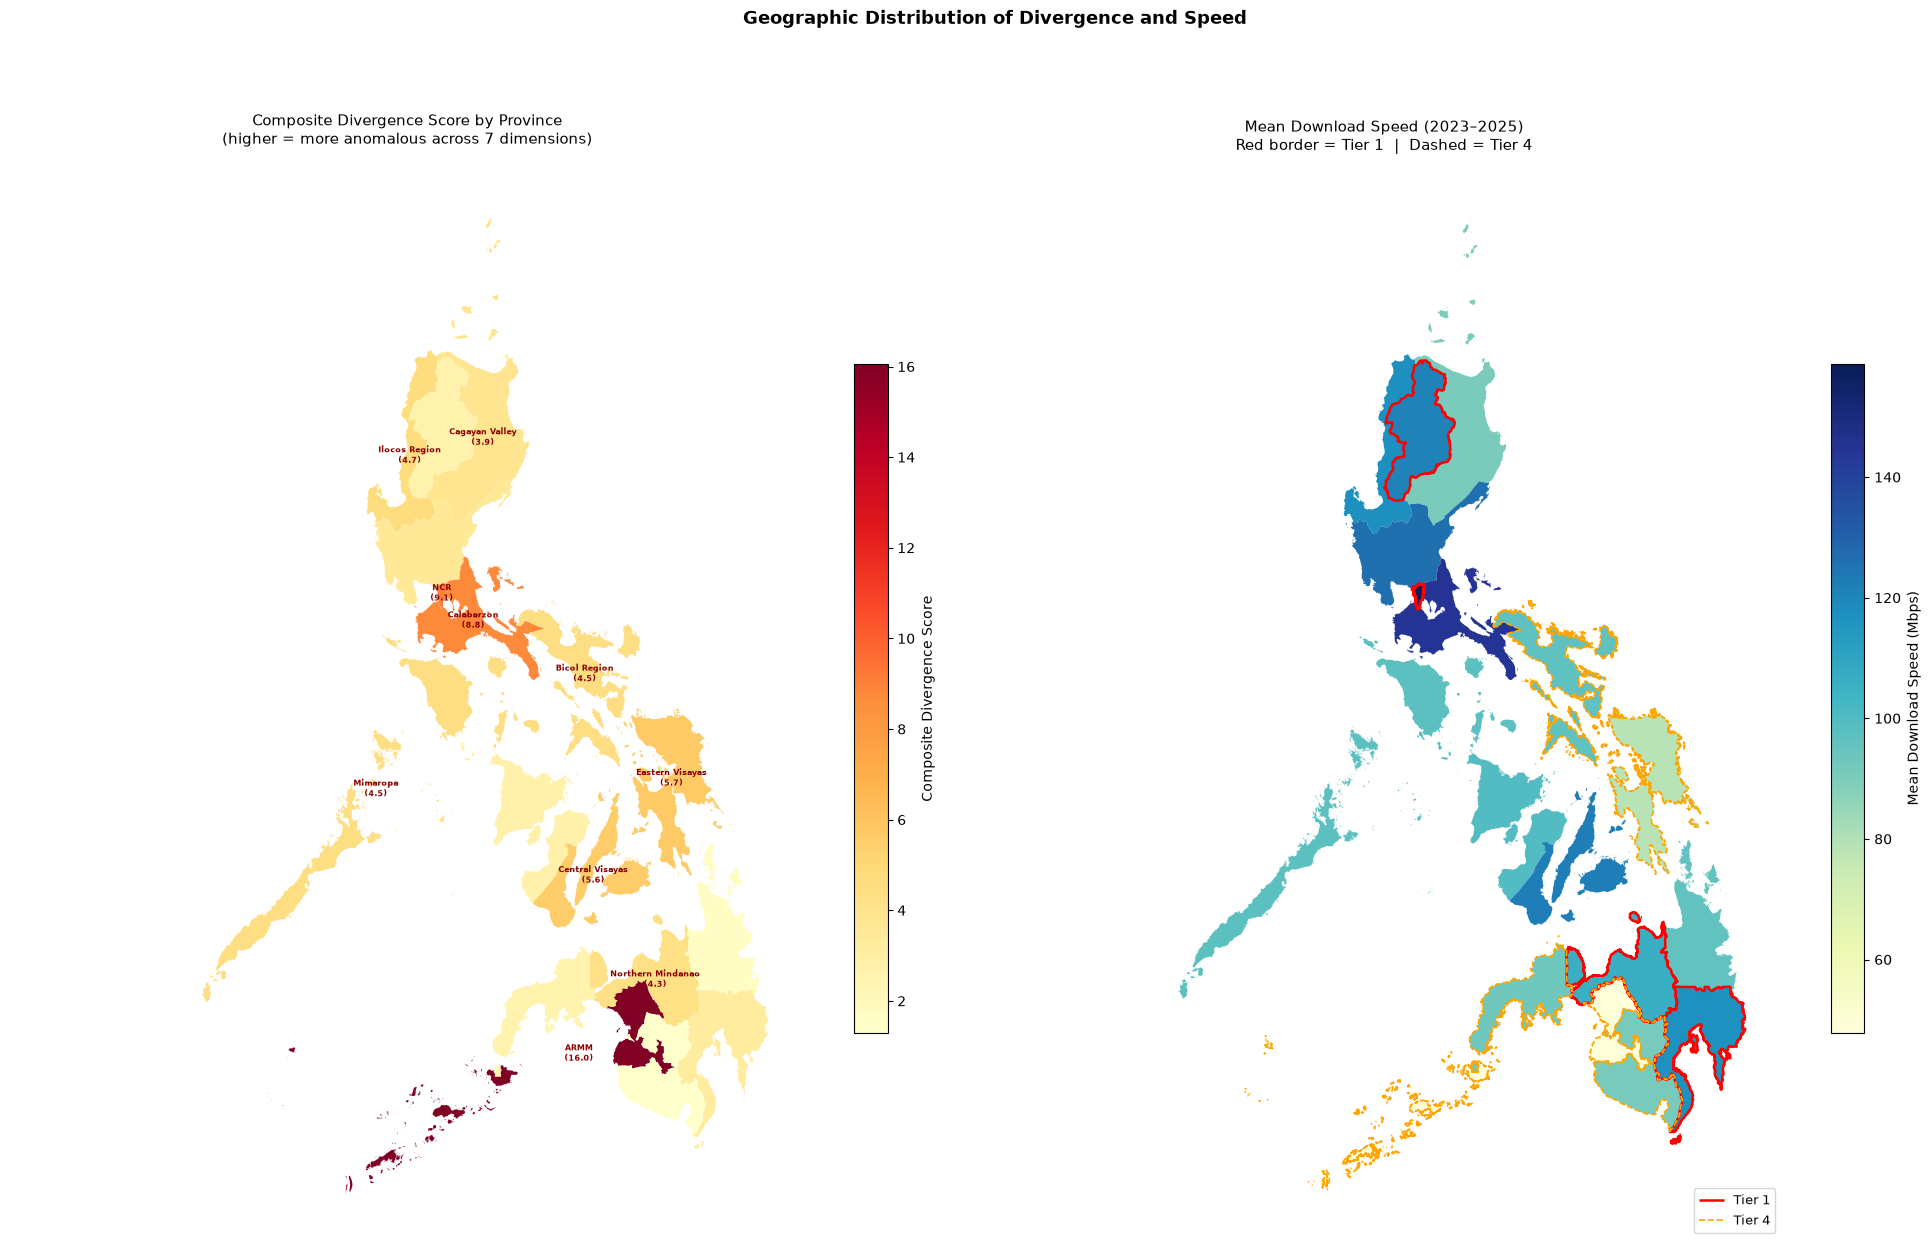

In [45]:
_GEOJSON = '../../data/geo/philippines_provinces.geojson'

# Load GeoDataFrame with correct path (fallback if earlier cells used old path)
try:
    if 'thailand_gdf' not in dir() or thailand_gdf is None:
        raise NameError
    _ = thailand_gdf.shape  # verify it's valid
except (NameError, Exception):
    thailand_gdf = gpd.read_file(_GEOJSON).to_crs(4326)
    print("Loaded thailand_gdf from correct project path")

geo_divergent = thailand_gdf.copy()
geo_divergent = geo_divergent.merge(
    divergent_df[['name','divergence_score','mean_dl','internet_tier']],
    on='name', how='left'
)
geo_divergent['divergence_score'] = geo_divergent['divergence_score'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

# ── Left: divergence score choropleth ──────────────────────────────────────────
ax1 = axes[0]
geo_divergent.plot('divergence_score', ax=ax1, cmap='YlOrRd',
               legend=True, missing_kwds={'color':'lightgray'},
               legend_kwds={'label':'Composite Divergence Score','shrink':0.5})

top10_names = divergent_df.nlargest(10, 'divergence_score')['name'].values
for _, row in geo_divergent.iterrows():
    if row['name'] in top10_names:
        c = row.geometry.centroid
        score = row['divergence_score']
        ax1.annotate(f"{row['name']}\n({score:.1f})",
                     (c.x, c.y), ha='center', va='center',
                     fontsize=5.5, color='darkred', fontweight='bold')

ax1.set_title('Composite Divergence Score by Province\n(higher = more anomalous across 7 dimensions)',
              fontsize=11)
ax1.set_axis_off()

# ── Right: download speed choropleth with tier overlay ────────────────────────
ax2 = axes[1]
geo_divergent.plot('mean_dl', ax=ax2, cmap='YlGnBu',
               legend=True, missing_kwds={'color':'lightgray'},
               legend_kwds={'label':'Mean Download Speed (Mbps)','shrink':0.5})

t1 = geo_divergent[geo_divergent['internet_tier'] == 1]
t1.boundary.plot(ax=ax2, color='red', linewidth=1.8, label='Tier 1')
t4 = geo_divergent[geo_divergent['internet_tier'] == 4]
t4.boundary.plot(ax=ax2, color='orange', linewidth=1.2, ls='--', label='Tier 4')

ax2.legend(fontsize=9, loc='lower right')
ax2.set_title('Mean Download Speed (2023–2025)\nRed border = Tier 1  |  Dashed = Tier 4',
              fontsize=11)
ax2.set_axis_off()

plt.suptitle('Geographic Distribution of Divergence and Speed', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/27_divergence_map.png', dpi=150, bbox_inches='tight')
plt.show()


### 24. Why Are They Divergent? — Annotated Province Notes

### 25. Full Province Divergence Table — All Provinces


In [46]:
# ── Merge display name ────────────────────────────────────────────────────────────
full_table = divergent_df.copy()
full_table = full_table.merge(
    prov_ref[['province_en','province_th']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

# ── Generate verdict ───────────────────────────────────────────────────────────
_DIM_ORDER = ['regional_z','gdp_residual_z','den_residual_z','tier_residual_z',
              'ratio_z','lat_regional_z','coverage_z']

def _note(d, v, region, tier):
    if d == 'gdp_residual_z':
        return f"fast for GDP (+{v:.1f}σ)" if v > 0 else f"slow for GDP ({v:.1f}σ)"
    if d == 'den_residual_z':
        return f"fast for density (+{v:.1f}σ)" if v > 0 else f"slow for density ({v:.1f}σ)"
    if d == 'tier_residual_z':
        return f"overperforms Tier {tier} (+{v:.1f}σ)" if v > 0 else f"underperforms Tier {tier} ({v:.1f}σ)"
    if d == 'regional_z':
        return f"fast vs {region} (+{v:.1f}σ)" if v > 0 else f"slow vs {region} ({v:.1f}σ)"
    if d == 'ratio_z':
        return f"symmetric UL/DL (+{v:.1f}σ)" if v > 0 else f"asymmetric UL/DL ({v:.1f}σ)"
    if d == 'lat_regional_z':
        return f"high latency (+{v:.1f}σ)" if v > 0 else f"ultra-low latency ({v:.1f}σ)"
    if d == 'coverage_z':
        return f"over-tested (+{v:.1f}σ)" if v > 0 else f"under-tested ({v:.1f}σ)"
    return f"{d}:{v:.1f}σ"

def make_verdict(r):
    region = r['region']
    tier   = int(r['internet_tier'])
    signals = [(abs(r[d]), d, r[d]) for d in _DIM_ORDER if abs(r[d]) >= 1.0]
    signals.sort(reverse=True)
    if not signals:
        return "unremarkable"
    return " | ".join(_note(d, v, region, tier) for _, d, v in signals[:3])

full_table['verdict'] = full_table.apply(make_verdict, axis=1)

# ── Table 0: Overall ranking (top 20) ─────────────────────────────────────────
from IPython.display import display, HTML

display(HTML("<h3>Overall Divergence Ranking — Top 20</h3>"))
t0 = (full_table.nlargest(20, 'divergence_score')
      [['name','province_th','region','internet_tier','mean_dl','divergence_score','verdict']]
      .rename(columns={'name':'Province','province_th':'Local Name','region':'Region',
                       'internet_tier':'Tier','mean_dl':'DL Mbps','divergence_score':'Score','verdict':'Why Divergent?'})
      .reset_index(drop=True))
t0.index += 1
tier_palette = {1:'#ffcccc', 2:'#ffe4b5', 3:'#d4f0d4', 4:'#dce0f5'}
styled0 = (t0.style
    .background_gradient(subset=['Score'], cmap='YlOrRd', vmin=0, vmax=20)
    .background_gradient(subset=['DL Mbps'], cmap='YlGn', vmin=110, vmax=330)
    .map(lambda v: f"background-color:{tier_palette.get(int(v),'#fff')}", subset=['Tier'])
    .set_properties(**{'font-size':'11px','text-align':'left'})
    .set_properties(subset=['Why Divergent?'], **{'min-width':'320px','font-size':'10px'})
    .set_table_styles([
        {'selector':'th','props':[('background','#f0f0f0'),('font-size','10px'),('padding','4px 6px')]},
        {'selector':'td','props':[('padding','3px 6px'),('border','1px solid #ddd')]},
    ]))
display(styled0)

# ── Tables 1-7: Per-dimension top 8 over / bottom 8 under ─────────────────────
dim_meta = {
    'regional_z':      ('Regional Speed', 'fast vs region peers', 'slow vs region peers'),
    'gdp_residual_z':  ('GDP Gap', 'fast for GDP level', 'slow for GDP level'),
    'den_residual_z':  ('Density Gap', 'fast for density', 'slow for density'),
    'tier_residual_z': ('Tier Gap', 'overperforms tier', 'underperforms tier'),
    'ratio_z':         ('UL/DL Ratio', 'symmetric (fiber)', 'asymmetric (legacy)'),
    'lat_regional_z':  ('Latency (regional)', 'high latency', 'ultra-low latency'),
    'coverage_z':      ('Test Coverage', 'over-tested', 'under-tested'),
}

base_cols = ['name','province_th','region','internet_tier','mean_dl']

for dim, (title, over_label, under_label) in dim_meta.items():
    display(HTML(f"<h3>Dimension: {title} <small style='color:#888'>({dim})</small></h3>"))
    
    sub = full_table[base_cols + [dim, 'divergence_score']].copy()
    sub = sub.rename(columns={
        'name':'Province','province_th':'Local Name','region':'Region',
        'internet_tier':'Tier','mean_dl':'DL Mbps',
        dim:'z-score','divergence_score':'Total Score'
    })
    
    over  = sub.nlargest(8, 'z-score').copy()
    under = sub.nsmallest(8, 'z-score').copy()
    over['signal']  = over_label
    under['signal'] = under_label
    
    combined = pd.concat([over, under], ignore_index=True)
    combined = combined[['Province','Local Name','Region','Tier','DL Mbps','z-score','signal','Total Score']]
    combined['z-score'] = combined['z-score'].round(2)
    combined['DL Mbps'] = combined['DL Mbps'].round(1)
    combined['Total Score'] = combined['Total Score'].round(2)
    
    styled_dim = (combined.style
        .background_gradient(subset=['z-score'], cmap='RdBu_r', vmin=-4, vmax=4)
        .background_gradient(subset=['DL Mbps'], cmap='YlGn', vmin=110, vmax=330)
        .map(lambda v: f"background-color:{tier_palette.get(int(v),'#fff')}", subset=['Tier'])
        .set_properties(**{'font-size':'11px','text-align':'left'})
        .set_table_styles([
            {'selector':'th','props':[('background','#f0f0f0'),('font-size','10px'),('padding','4px 6px')]},
            {'selector':'td','props':[('padding','3px 6px'),('border','1px solid #ddd')]},
        ])
        .hide(axis='index'))
    display(styled_dim)
    display(HTML("<hr style='margin:16px 0'>"))

print(f"Provinces: {len(full_table)}")
print(f"Score range: {full_table['divergence_score'].min():.2f} – {full_table['divergence_score'].max():.2f}")
print(f"|z|>2 in any dim: {(full_table[[*_DIM_ORDER]].abs() >= 2).any(axis=1).sum()}")
print(f"|z|>3 in any dim: {(full_table[[*_DIM_ORDER]].abs() >= 3).any(axis=1).sum()}")
print(f"Unremarkable: {(full_table[[*_DIM_ORDER]].abs() < 1.0).all(axis=1).sum()}")

# Save styled table as HTML
_html_path = '../../outputs/ookla/philippines/28_divergence_table.html'
with open(_html_path, 'w') as _f:
    _f.write(styled0.to_html())
print(f"Saved: {_html_path}")


,Province,Local Name,Region,Tier,DL Mbps,Score,Why Divergent?
1,ARMM,ARMM,Mindanao,4,47.871272,16.048267,asymmetric UL/DL (-3.8σ) | slow for density (-3.0σ) | underperforms Tier 4 (-2.7σ)
2,NCR,NCR,Luzon,1,158.695259,9.066621,over-tested (+3.0σ) | overperforms Tier 1 (+2.0σ) | fast vs Luzon (+1.8σ)
3,Calabarzon,Calabarzon,Luzon,2,144.573994,8.779266,fast for GDP (+2.6σ) | fast for density (+1.3σ) | over-tested (+1.2σ)
4,Eastern Visayas,Eastern Visayas,Visayas,4,78.869958,5.729309,high latency (+1.3σ) | slow vs Visayas (-1.2σ) | slow for density (-1.0σ)
5,Central Visayas,Central Visayas,Visayas,2,122.075940,5.579256,over-tested (+1.2σ) | fast vs Visayas (+1.2σ) | ultra-low latency (-1.1σ)
6,Ilocos Region,Ilocos Region,Luzon,3,117.215790,4.668405,fast for GDP (+1.5σ) | overperforms Tier 3 (+1.3σ)
7,Bicol Region,Bicol Region,Luzon,4,96.402879,4.508816,fast for GDP (+1.0σ)
8,Mimaropa,Mimaropa,Luzon,3,97.171830,4.499253,high latency (+2.1σ)
9,Northern Mindanao,Northern Mindanao,Mindanao,1,105.883838,4.296438,slow for GDP (-1.4σ)
10,Cagayan Valley,Cagayan Valley,Luzon,3,90.619934,3.871645,slow vs Luzon (-1.3σ)


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
NCR,NCR,Luzon,1,158.700000,1.760000,fast vs region peers,9.070000
Central Visayas,Central Visayas,Visayas,2,122.100000,1.240000,fast vs region peers,5.580000
Davao Region,Davao Region,Mindanao,1,116.900000,1.170000,fast vs region peers,3.230000
Calabarzon,Calabarzon,Luzon,2,144.600000,1.130000,fast vs region peers,8.780000
Northern Mindanao,Northern Mindanao,Mindanao,1,105.900000,0.650000,fast vs region peers,4.300000
Central Luzon,Central Luzon,Luzon,2,126.100000,0.310000,fast vs region peers,3.560000
Caraga,Caraga,Mindanao,3,96.300000,0.210000,fast vs region peers,1.650000
CAR,CAR,Luzon,1,121.100000,0.090000,fast vs region peers,2.660000
ARMM,ARMM,Mindanao,4,47.900000,-2.040000,slow vs region peers,16.050000
Cagayan Valley,Cagayan Valley,Luzon,3,90.600000,-1.260000,slow vs region peers,3.870000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Calabarzon,Calabarzon,Luzon,2,144.600000,2.550000,fast for GDP level,8.780000
Ilocos Region,Ilocos Region,Luzon,3,117.200000,1.480000,fast for GDP level,4.670000
Bicol Region,Bicol Region,Luzon,4,96.400000,1.030000,fast for GDP level,4.510000
Central Luzon,Central Luzon,Luzon,2,126.100000,0.860000,fast for GDP level,3.560000
Central Visayas,Central Visayas,Visayas,2,122.100000,0.820000,fast for GDP level,5.580000
CAR,CAR,Luzon,1,121.100000,-0.100000,fast for GDP level,2.660000
Western Visayas,Western Visayas,Visayas,2,99.700000,-0.150000,fast for GDP level,2.750000
Caraga,Caraga,Mindanao,3,96.300000,-0.220000,fast for GDP level,1.650000
Northern Mindanao,Northern Mindanao,Mindanao,1,105.900000,-1.390000,slow for GDP level,4.300000
ARMM,ARMM,Mindanao,4,47.900000,-1.210000,slow for GDP level,16.050000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
CAR,CAR,Luzon,1,121.100000,1.630000,fast for density,2.660000
Calabarzon,Calabarzon,Luzon,2,144.600000,1.350000,fast for density,8.780000
Davao Region,Davao Region,Mindanao,1,116.900000,0.750000,fast for density,3.230000
Central Luzon,Central Luzon,Luzon,2,126.100000,0.740000,fast for density,3.560000
Ilocos Region,Ilocos Region,Luzon,3,117.200000,0.460000,fast for density,4.670000
Central Visayas,Central Visayas,Visayas,2,122.100000,0.370000,fast for density,5.580000
Mimaropa,Mimaropa,Luzon,3,97.200000,0.320000,fast for density,4.500000
Northern Mindanao,Northern Mindanao,Mindanao,1,105.900000,0.220000,fast for density,4.300000
ARMM,ARMM,Mindanao,4,47.900000,-3.000000,slow for density,16.050000
Eastern Visayas,Eastern Visayas,Visayas,4,78.900000,-1.050000,slow for density,5.730000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
NCR,NCR,Luzon,1,158.700000,1.980000,overperforms tier,9.070000
Ilocos Region,Ilocos Region,Luzon,3,117.200000,1.280000,overperforms tier,4.670000
Calabarzon,Calabarzon,Luzon,2,144.600000,1.010000,overperforms tier,8.780000
Bicol Region,Bicol Region,Luzon,4,96.400000,0.410000,overperforms tier,4.510000
Zamboanga Peninsula,Zamboanga Peninsula,Mindanao,4,93.000000,0.190000,overperforms tier,2.620000
CAR,CAR,Luzon,1,121.100000,0.160000,overperforms tier,2.660000
Central Luzon,Central Luzon,Luzon,2,126.100000,0.150000,overperforms tier,3.560000
Mimaropa,Mimaropa,Luzon,3,97.200000,0.090000,overperforms tier,4.500000
ARMM,ARMM,Mindanao,4,47.900000,-2.660000,underperforms tier,16.050000
Western Visayas,Western Visayas,Visayas,2,99.700000,-1.070000,underperforms tier,2.750000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Calabarzon,Calabarzon,Luzon,2,144.600000,0.790000,symmetric (fiber),8.780000
Central Visayas,Central Visayas,Visayas,2,122.100000,0.770000,symmetric (fiber),5.580000
Bicol Region,Bicol Region,Luzon,4,96.400000,0.510000,symmetric (fiber),4.510000
Western Visayas,Western Visayas,Visayas,2,99.700000,0.450000,symmetric (fiber),2.750000
Cagayan Valley,Cagayan Valley,Luzon,3,90.600000,0.420000,symmetric (fiber),3.870000
Ilocos Region,Ilocos Region,Luzon,3,117.200000,0.400000,symmetric (fiber),4.670000
Eastern Visayas,Eastern Visayas,Visayas,4,78.900000,0.400000,symmetric (fiber),5.730000
Central Luzon,Central Luzon,Luzon,2,126.100000,0.380000,symmetric (fiber),3.560000
ARMM,ARMM,Mindanao,4,47.900000,-3.770000,asymmetric (legacy),16.050000
Zamboanga Peninsula,Zamboanga Peninsula,Mindanao,4,93.000000,-0.680000,asymmetric (legacy),2.620000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Mimaropa,Mimaropa,Luzon,3,97.200000,2.100000,high latency,4.500000
ARMM,ARMM,Mindanao,4,47.900000,2.100000,high latency,16.050000
Eastern Visayas,Eastern Visayas,Visayas,4,78.900000,1.320000,high latency,5.730000
Bicol Region,Bicol Region,Luzon,4,96.400000,0.760000,high latency,4.510000
Cagayan Valley,Cagayan Valley,Luzon,3,90.600000,0.490000,high latency,3.870000
Soccsksargen,Soccsksargen,Mindanao,4,90.800000,0.030000,high latency,1.300000
Zamboanga Peninsula,Zamboanga Peninsula,Mindanao,4,93.000000,-0.130000,high latency,2.620000
Western Visayas,Western Visayas,Visayas,2,99.700000,-0.220000,high latency,2.750000
NCR,NCR,Luzon,1,158.700000,-1.230000,ultra-low latency,9.070000
Central Visayas,Central Visayas,Visayas,2,122.100000,-1.100000,ultra-low latency,5.580000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
NCR,NCR,Luzon,1,158.700000,3.010000,over-tested,9.070000
Central Visayas,Central Visayas,Visayas,2,122.100000,1.240000,over-tested,5.580000
Calabarzon,Calabarzon,Luzon,2,144.600000,1.200000,over-tested,8.780000
Central Luzon,Central Luzon,Luzon,2,126.100000,0.560000,over-tested,3.560000
CAR,CAR,Luzon,1,121.100000,0.310000,over-tested,2.660000
Davao Region,Davao Region,Mindanao,1,116.900000,0.060000,over-tested,3.230000
Soccsksargen,Soccsksargen,Mindanao,4,90.800000,-0.280000,over-tested,1.300000
Bicol Region,Bicol Region,Luzon,4,96.400000,-0.320000,over-tested,4.510000
ARMM,ARMM,Mindanao,4,47.900000,-1.270000,under-tested,16.050000
Zamboanga Peninsula,Zamboanga Peninsula,Mindanao,4,93.000000,-0.850000,under-tested,2.620000


Provinces: 17
Score range: 1.30 – 16.05
|z|>2 in any dim: 4
|z|>3 in any dim: 2
Unremarkable: 4
Saved: ../../outputs/ookla/philippines/28_divergence_table.html


## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [47]:
# ── Export Ookla quarterly province data for comparison notebook ──
import os
os.makedirs("../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../data/exports/ookla_philippines_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows → {PATH}")
print(out.head(3).to_string())


Exported 187 rows → ../../data/exports/ookla_philippines_province_quarterly.csv
       province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable    region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0          ARMM  2023-Q1  2023        1   51.194423   42.214278      73.812023       9049.0    683.0         True  Mindanao              4   4545486                 91028.33              330
1  Bicol Region  2023-Q1  2023        1   84.381611   85.660324      21.150858     128094.0   5460.0         True     Luzon              4   6064426                142596.80              319
2           CAR  2023-Q1  2023        1  105.929294   97.291631      12.404070      58428.0   1222.0         True     Luzon              1   1808985                295236.64               89


---
# Part 2 — Mobile/Cellular


## Full EDA — Ookla Mobile/Cellular, Philippines (2023 Q1 – 2025 Q4)

### 1. Load & Aggregate All Quarters

In [48]:
import glob, os, warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

DATASET_DIR = '../../data/ookla/raw'
GEOJSON     = '../../data/geo/philippines_provinces.geojson'
PROV_REF    = '../../data/reference/philippines_reference.csv'

# Ookla S3 filename convention: {YEAR}-{MM}-01_performance_mobile_tiles.parquet
# Q1=January(01), Q2=April(04), Q3=July(07), Q4=October(10)
Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)
state_bounds = thailand_gdf.total_bounds
bbox_filters = [
    ('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
    ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0]),
]

COLS = ['tile_x','tile_y','tests','devices','avg_d_kbps','avg_u_kbps','avg_lat_ms']

records = []
files = sorted(glob.glob(os.path.join(DATASET_DIR, '*mobile_tiles*.parquet')))

for fp in files:
    fname   = os.path.basename(fp)
    year    = int(fname[:4])
    quarter = int(fname[6])
    month   = Q_TO_MONTH[quarter]
    # period_start mirrors Ookla's original filename date (first day of the quarter)
    period_start = pd.Timestamp(year=year, month=month, day=1)
    label   = f"{year}-Q{quarter}"

    raw = pd.read_parquet(fp, columns=COLS, filters=bbox_filters)

    tiles_gdf = gpd.GeoDataFrame(
        raw,
        geometry=gpd.points_from_xy(raw.tile_x, raw.tile_y),
        crs='EPSG:4326'
    ).drop(columns=['tile_x','tile_y'])

    joined = gpd.sjoin(tiles_gdf, thailand_gdf[['name','geometry']], how='inner', predicate='intersects')

    agg = (
        joined.groupby('name')
        .apply(lambda g: pd.Series({
            'avg_d_kbps_wt': np.average(g['avg_d_kbps'], weights=g['tests']),
            'avg_u_kbps_wt': np.average(g['avg_u_kbps'], weights=g['tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms'], weights=g['tests']),
            'total_tests'  : g['tests'].sum(),
            'total_devices': g['devices'].sum(),
            'n_tiles'      : len(g),
        }), include_groups=False)
        .reset_index()
    )
    agg['year']         = year
    agg['quarter']      = quarter
    agg['month']        = month
    agg['period_start'] = period_start   # datetime: 2023-01-01, 2023-04-01, ...
    agg['label']        = label
    records.append(agg)
    print(f"  {label} ({period_start.date()}): {len(raw):>8,} raw tiles → {len(agg)} provinces")

master = pd.concat(records, ignore_index=True)
master['avg_d_mbps'] = master['avg_d_kbps_wt'] / 1000
master['avg_u_mbps'] = master['avg_u_kbps_wt'] / 1000
master.drop(columns=['avg_d_kbps_wt','avg_u_kbps_wt'], inplace=True)

# Merge province reference
prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data
master = master.merge(prov_ref.rename(columns={'province_en':'name'}), on='name', how='left')

print(f"\nMaster shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} → {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()}")
print(f"\nperiod_start unique values (matches Ookla filename dates):")
for d in sorted(master['period_start'].unique()):
    print(f"  {pd.Timestamp(d).date()}")


  2023-Q1 (2023-01-01):   57,219 raw tiles → 17 provinces


  2023-Q2 (2023-04-01):   58,039 raw tiles → 17 provinces


  2023-Q3 (2023-07-01):   57,172 raw tiles → 17 provinces


  2023-Q4 (2023-10-01):   55,504 raw tiles → 17 provinces


  2024-Q1 (2024-01-01):   54,611 raw tiles → 17 provinces


...

  2024-Q4 (2024-10-01):   52,621 raw tiles → 17 provinces


  2025-Q1 (2025-01-01):   49,973 raw tiles → 17 provinces


  2025-Q2 (2025-04-01):   53,675 raw tiles → 17 provinces


  2025-Q3 (2025-07-01):   49,595 raw tiles → 17 provinces


  2025-Q4 (2025-10-01):   55,057 raw tiles → 17 provinces

Master shape: (204, 22)
Date range: 2023-01-01 → 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  17

period_start unique values (matches Ookla filename dates):
  2023-01-01
  2023-04-01
  2023-07-01
  2023-10-01
  2024-01-01
  2024-04-01
  2024-07-01
  2024-10-01
  2025-01-01
  2025-04-01
  2025-07-01
  2025-10-01


In [49]:
# Quality flag per province × quarter
# Ookla: >= 100 tests AND >= 5 tiles → sufficient spatial + sample coverage
master['is_reliable'] = (
    (master['total_tests'] >= 100) &
    (master['n_tiles'] >= 5)
)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")

Reliable province-quarters per label:
label
2023-Q1    17
2023-Q2    17
2023-Q3    17
2023-Q4    17
2024-Q1    17
2024-Q2    17
2024-Q3    17
2024-Q4    17
2025-Q1    17
2025-Q2    17
2025-Q3    17
2025-Q4    17

Overall reliable: 204 / 204 (100.0%)


### 2. Data Quality — Coverage per Province

In [50]:
# Expected: 77 provinces × 12 quarters = 924 rows
expected = 77 * master['label'].nunique()
print(f"Expected rows: {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

# Provinces with zero coverage in any quarter
all_provinces = set(thailand_gdf['name'])
all_labels    = set(master['label'].unique())
coverage_pivot = master.pivot_table(index='name', columns='label', values='total_tests', aggfunc='sum')

missing_cells = [(p, q) for p in all_provinces for q in all_labels
                 if p not in coverage_pivot.index or pd.isna(coverage_pivot.loc[p, q])]
if missing_cells:
    print(f"\nMissing province-quarter combos ({len(missing_cells)}):")
    for p, q in missing_cells:
        print(f"  {p} — {q}")
else:
    print(f"\nAll {expected_n} provinces covered in every quarter.")

# Low-test provinces (< 100 tests in any quarter)
low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
if len(low_test):
    print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} cases:")
    print(low_test.to_string(index=False))
else:
    print("\nNo quarters with < 100 tests.")


Expected rows: 924 | Actual: 204 | Missing: 720

All 17 provinces covered in every quarter.

No quarters with < 100 tests.


In [51]:
# Drop unreliable province-quarters before any stats/plots use master downstream
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")

Filtered to reliable province-quarters: 204 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

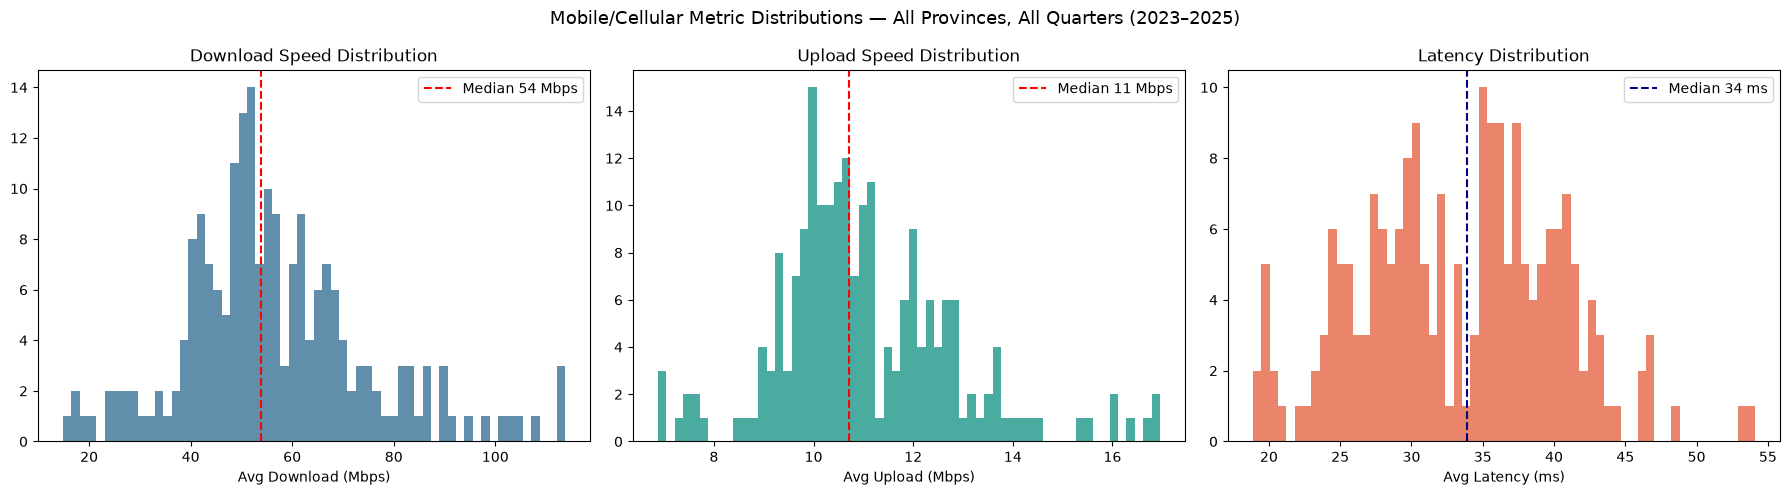

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      204.00      204.00         204.00       204.00
mean        56.61       11.05          33.38     35044.26
std         18.46        1.81           6.91     42543.88
min         14.82        6.87          18.87      3060.00
25%         45.19        9.96          28.19     10554.25
50%         53.83       10.72          33.87     17295.50
75%         66.07       12.06          38.38     40733.50
max        113.70       16.95          54.09    214981.00


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

plt.suptitle('Mobile/Cellular Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))


### 4. Province Ranking — Mean Download Speed (All Quarters)

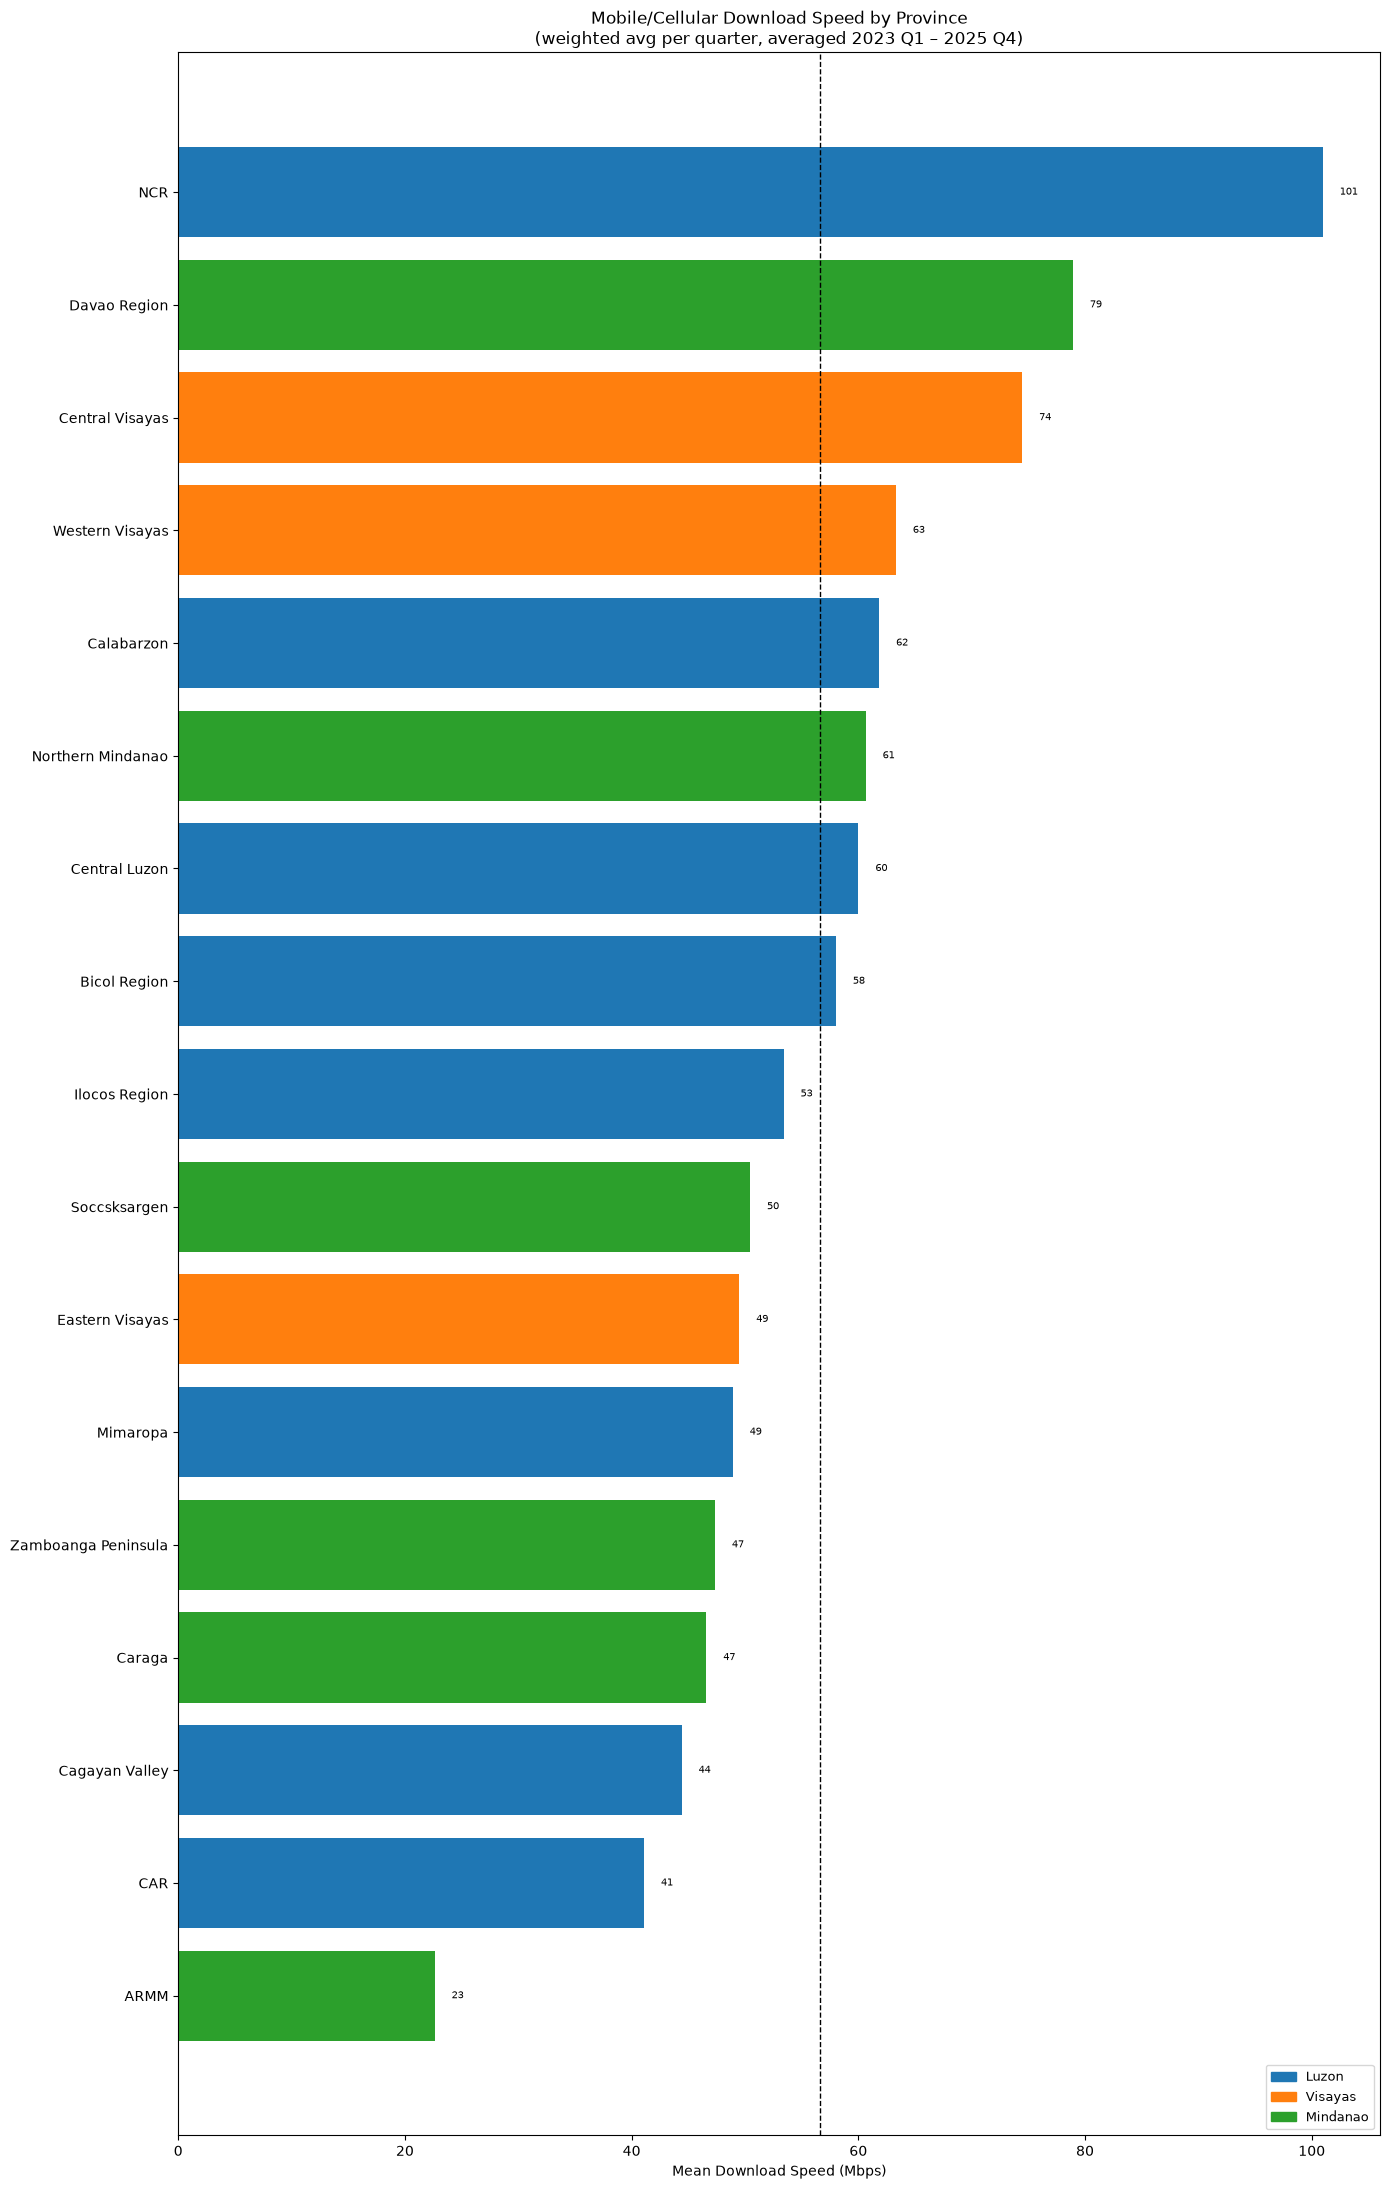

In [53]:
region_colors = {
    'Luzon': '#1f77b4',
    'Visayas': '#ff7f0e',
    'Mindanao': '#2ca02c',
}

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_mean['mean_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('Mean Download Speed (Mbps)')
ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.5 Province Ranking — Median Download Speed (All Quarters)

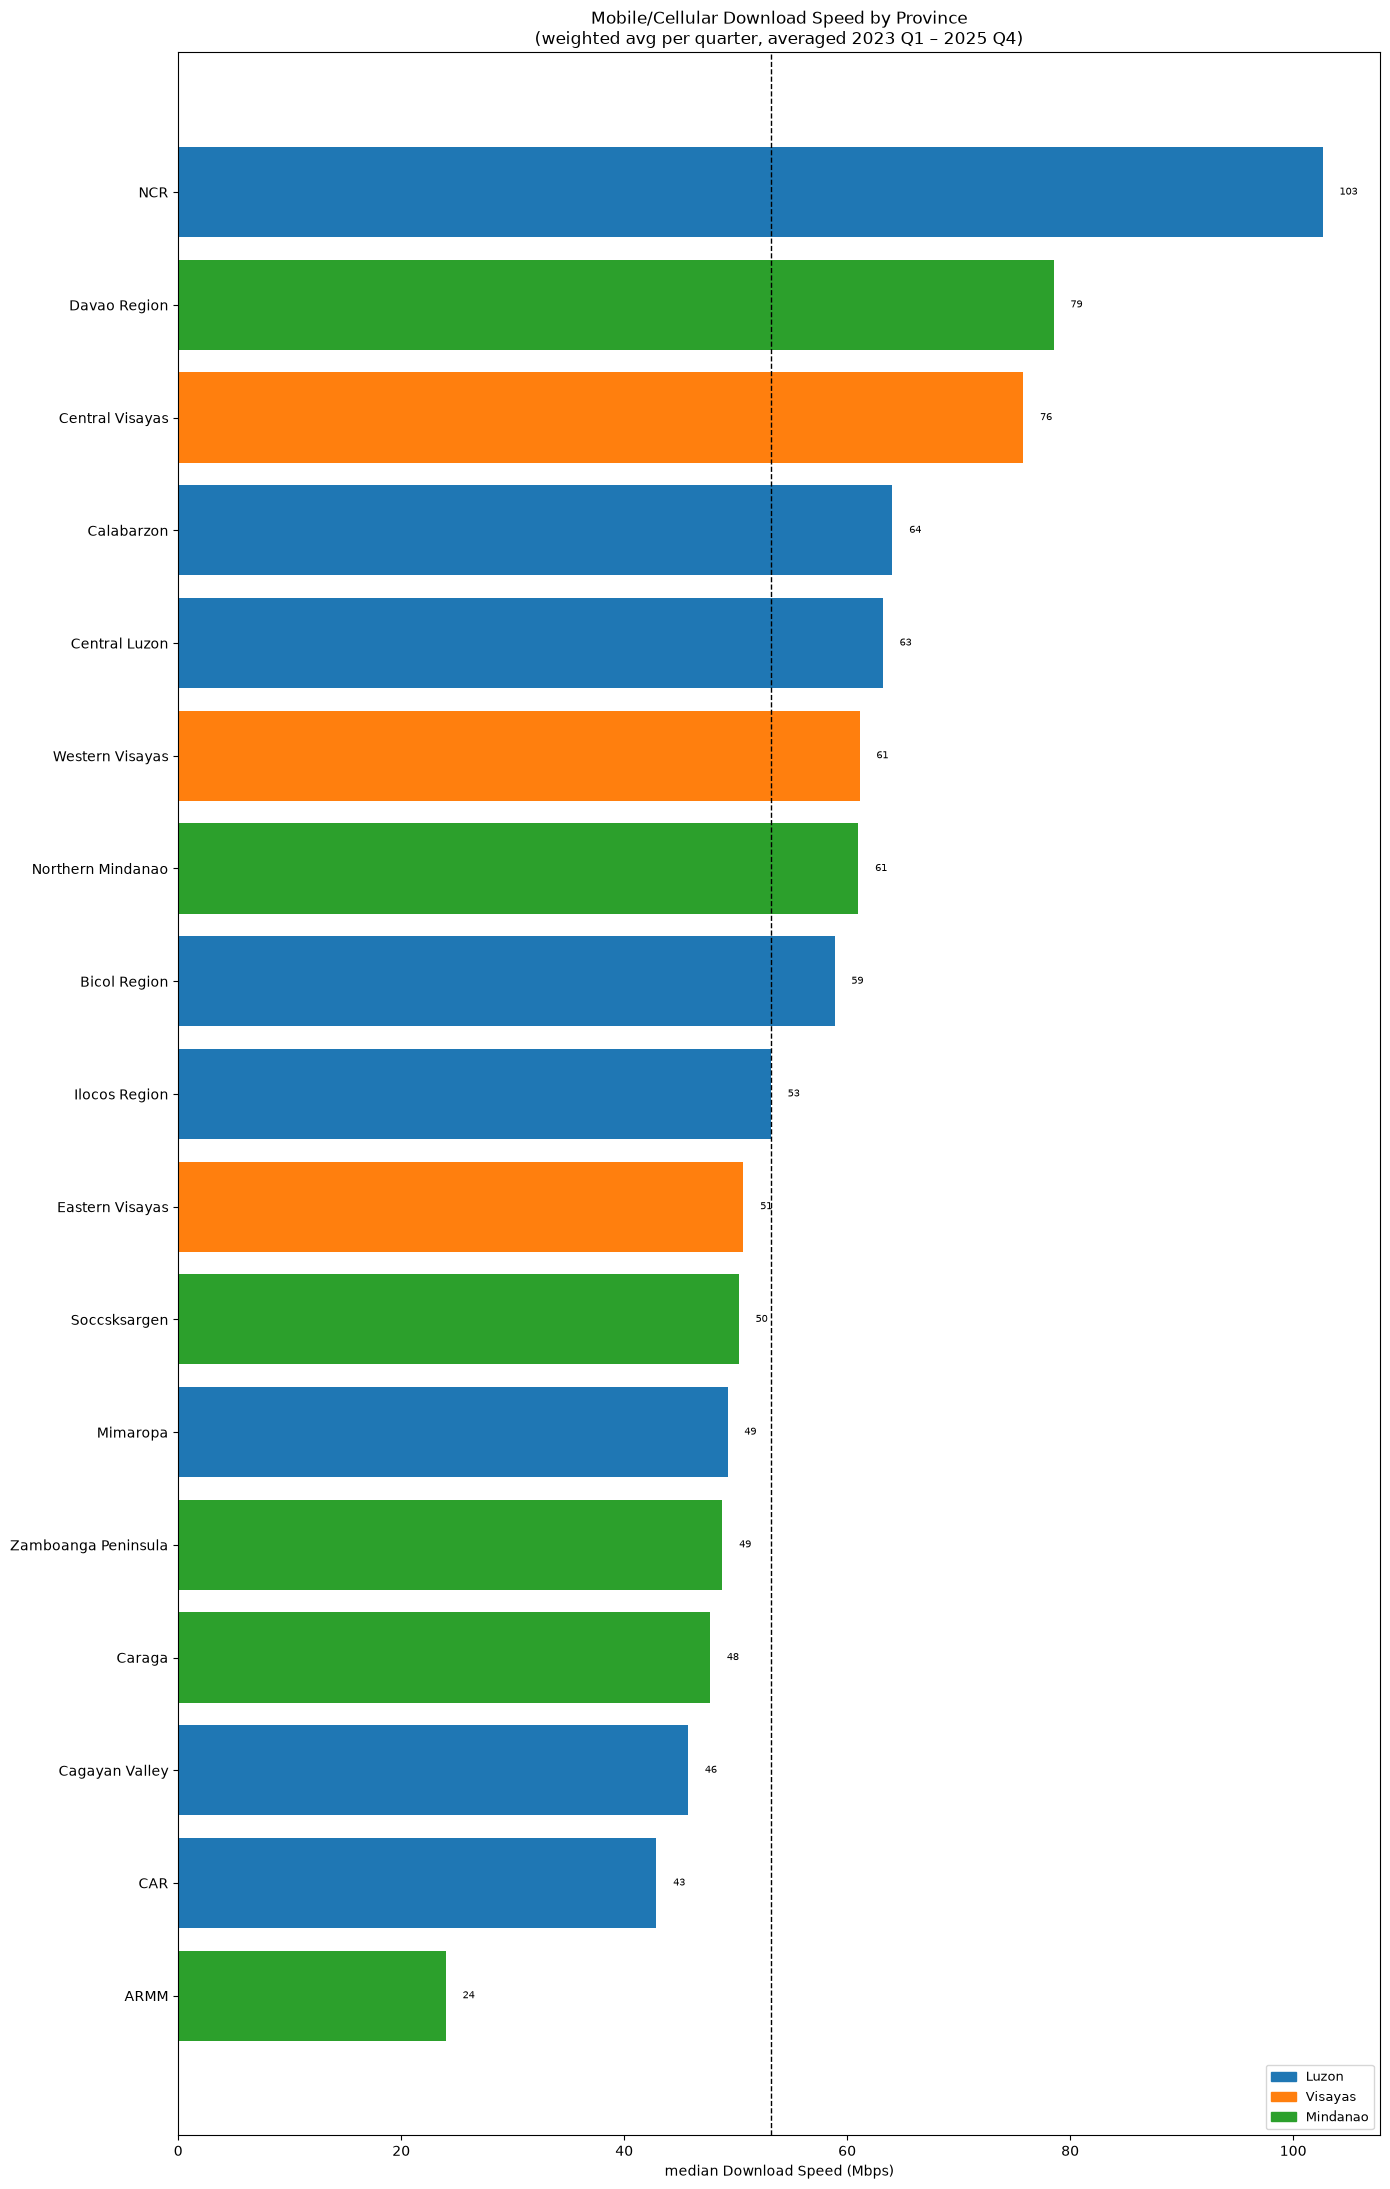

In [54]:
region_colors = {
    'Luzon': '#1f77b4',
    'Visayas': '#ff7f0e',
    'Mindanao': '#2ca02c',
}

prov_median = (
    master.groupby(['name','region'])
    .agg(
        median_dl=('avg_d_mbps','median'),
        median_ul=('avg_u_mbps','median'),
        median_lat=('avg_lat_ms_wt','median'),
        median_tests=('total_tests','median'),
    )
    .reset_index()
    .sort_values('median_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_median['region']]
bars = ax.barh(prov_median['name'], prov_median['median_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_median['median_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_median['median_dl'].median(), color='black', ls='--', lw=1, label=f'National median {prov_median["median_dl"].median():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('median Download Speed (Mbps)')
ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/12_province_ranking_median.png', dpi=150, bbox_inches='tight')
plt.show()


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

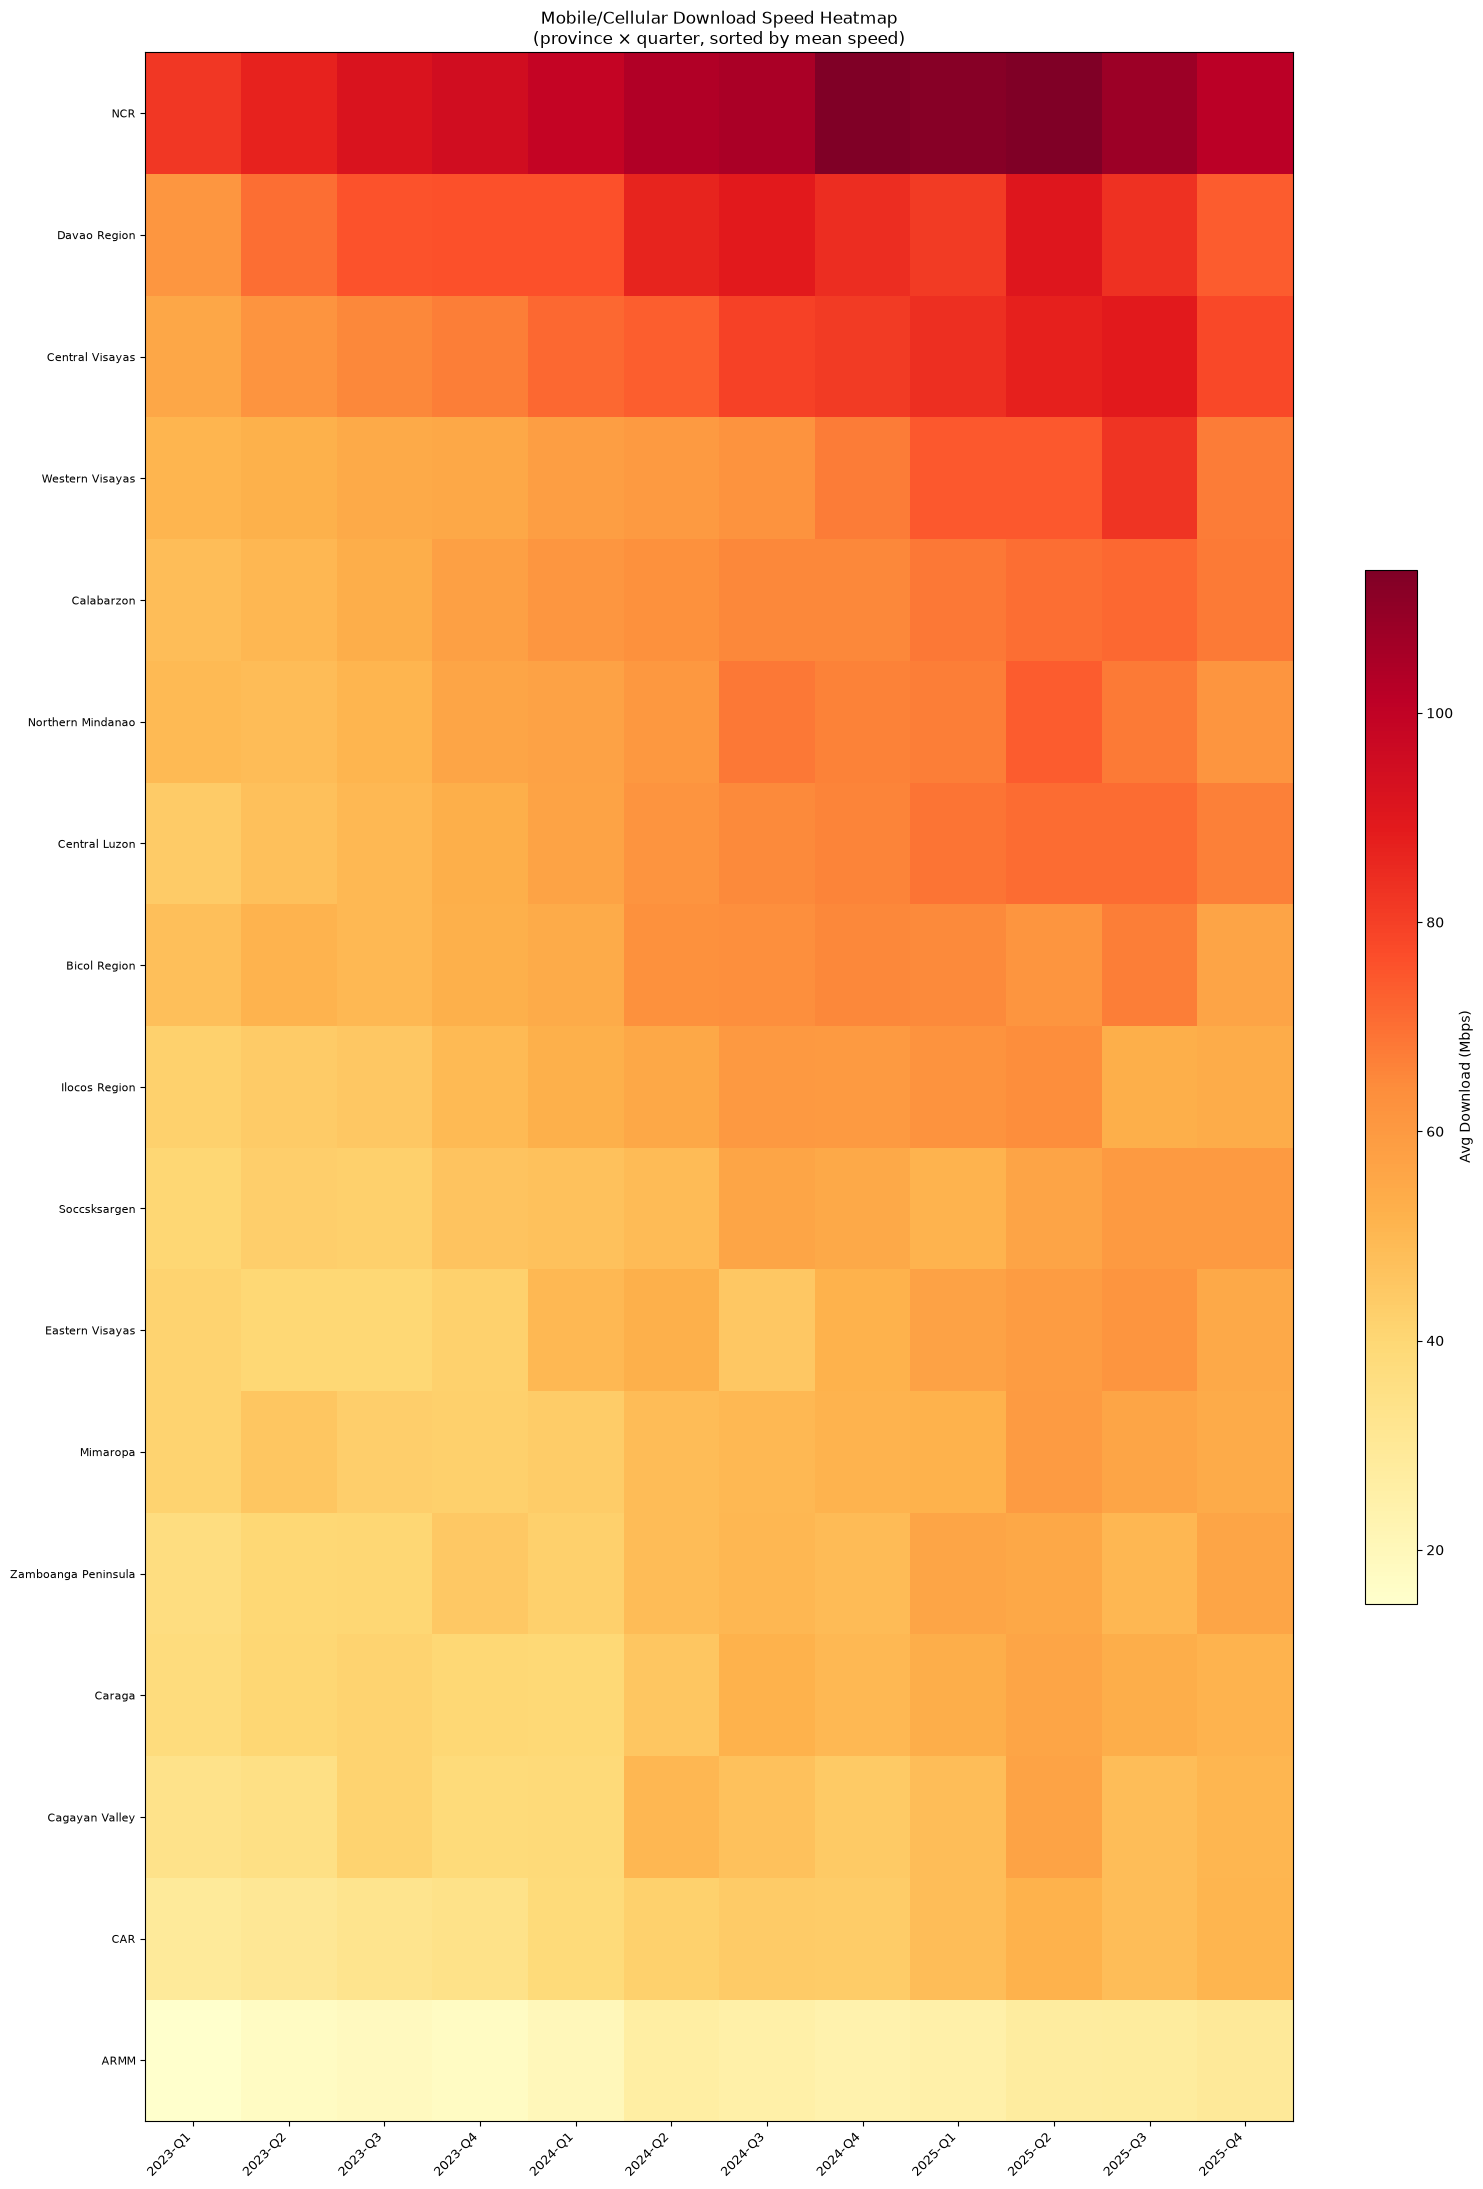

In [55]:
pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
# Format column labels as quarter strings for display
pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
# Sort by mean download speed
pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

fig, ax = plt.subplots(figsize=(16, 22))
im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)

ax.set_xticks(range(len(pivot_dl.columns)))
ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_dl.index)))
ax.set_yticklabels(pivot_dl.index, fontsize=8)
ax.set_title('Mobile/Cellular Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()


### 6. Regional Comparison — Download, Upload, Latency

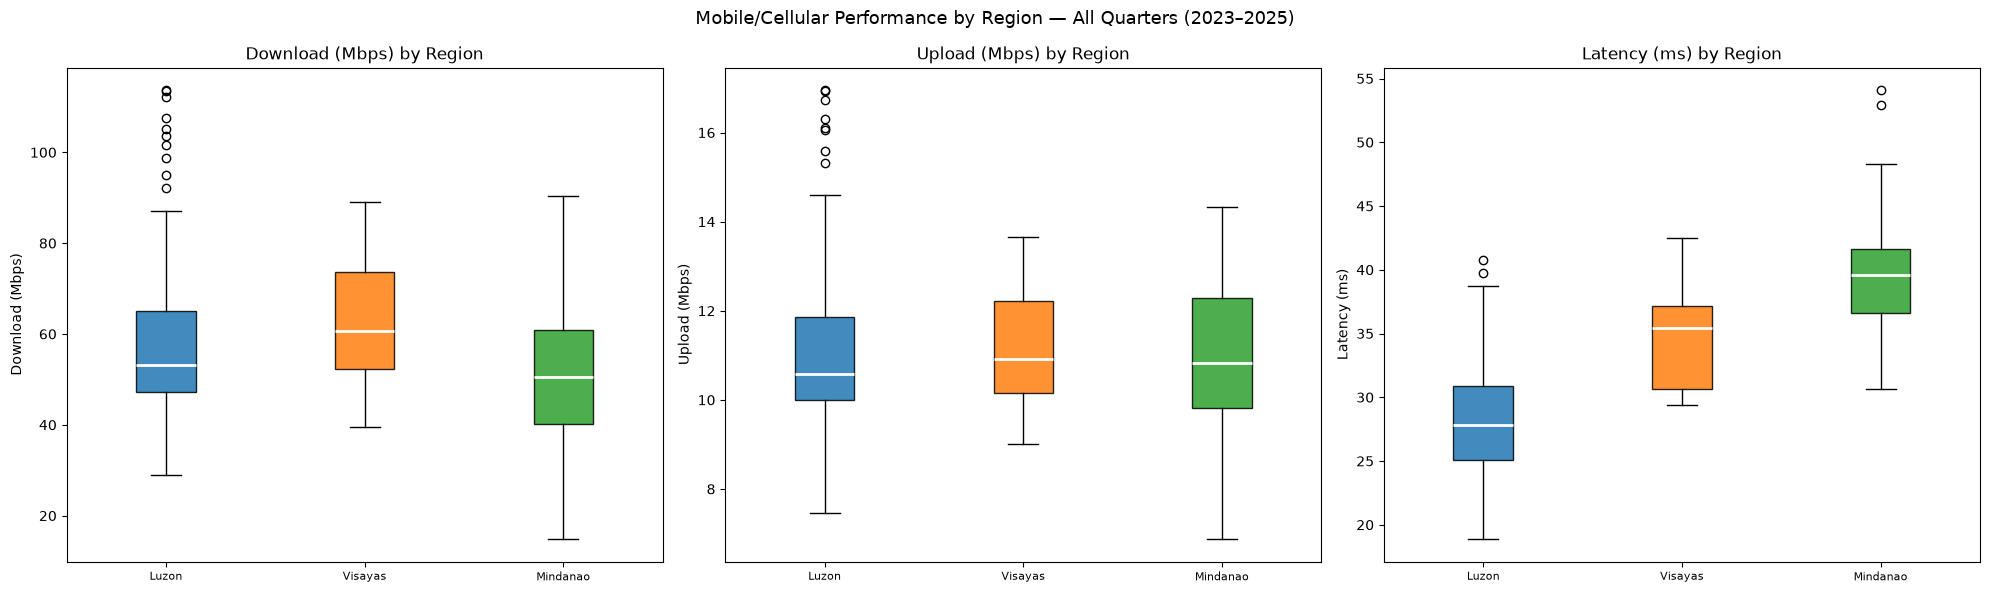

In [56]:
region_order = ['Luzon', 'Visayas', 'Mindanao']
region_data  = [master[master['region']==r]['avg_d_mbps'].dropna().values for r in region_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, label, color_key in [
    (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
    (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
    (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
]:
    data = [master[master['region']==r][metric].dropna().values for r in region_order]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch, region in zip(bp['boxes'], region_order):
        patch.set_facecolor(region_colors[region])
        patch.set_alpha(0.85)
    ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Region')

plt.suptitle('Mobile/Cellular Performance by Region — All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

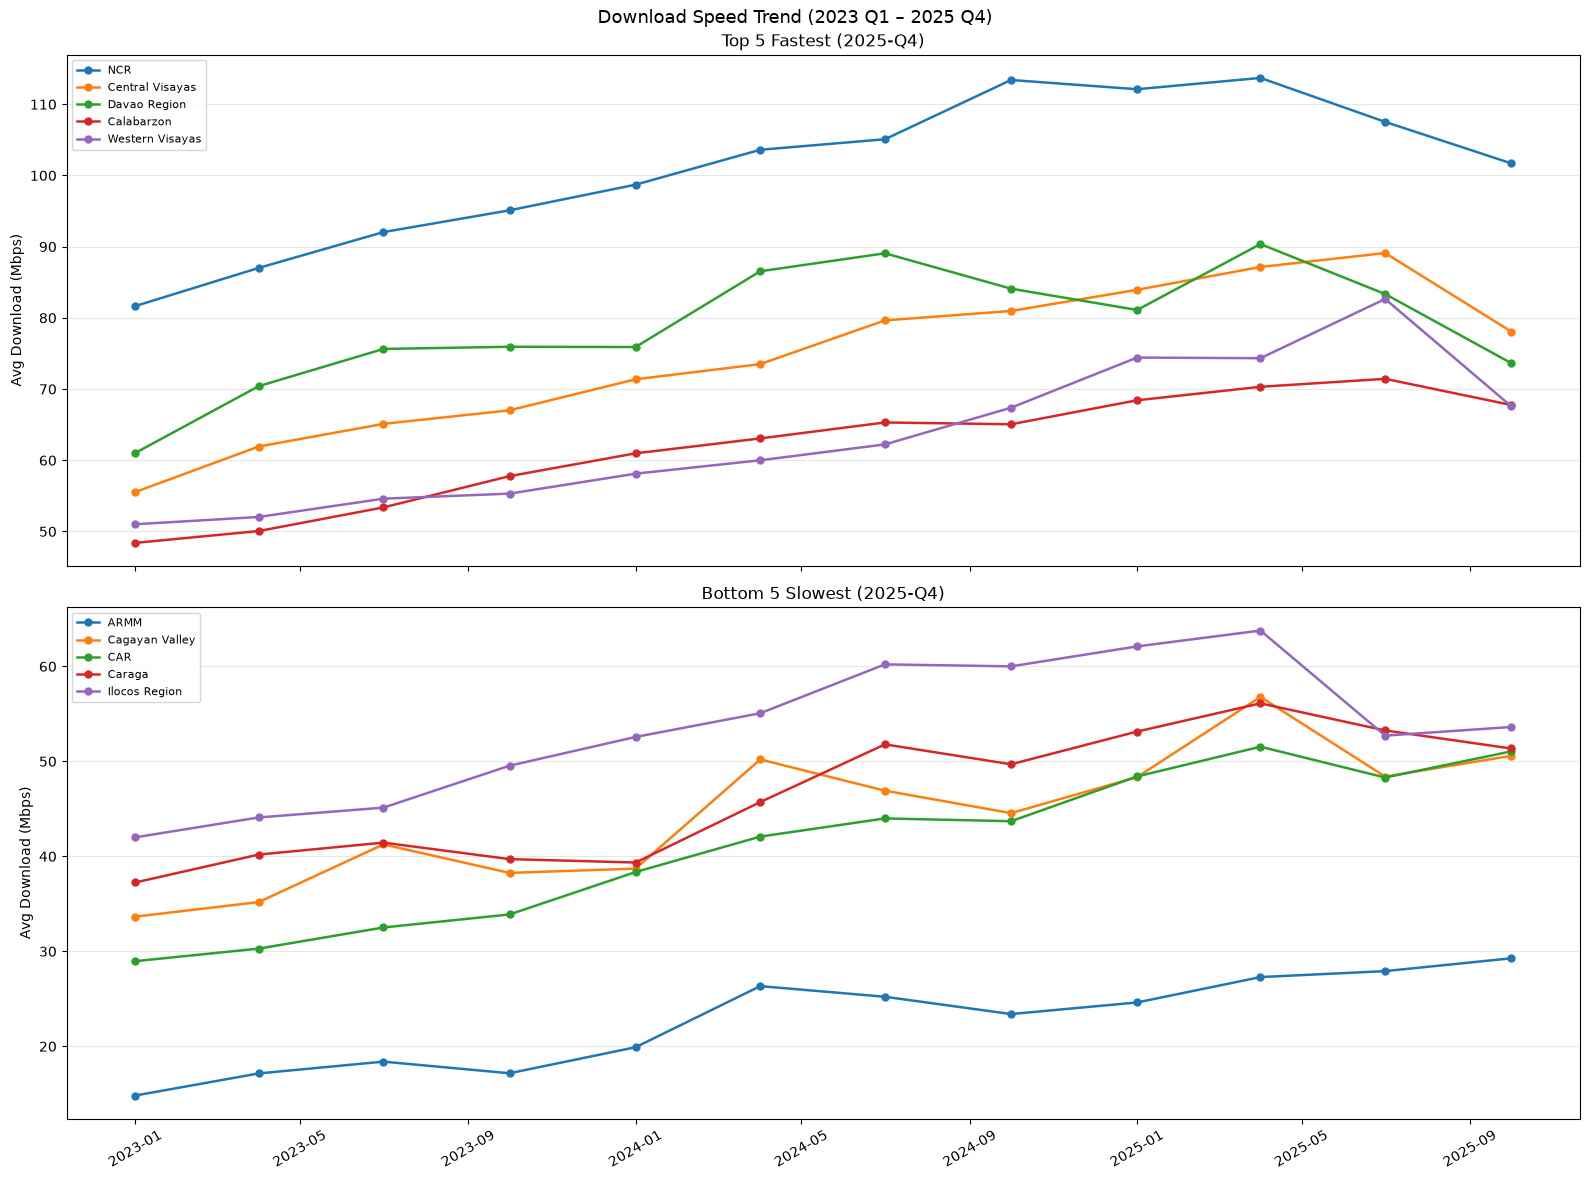

In [57]:
latest_q = master['label'].max()
latest = master[master['label'] == latest_q]
top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

quarter_order = sorted(master['label'].unique())
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

groups = [
    (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
    (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
]

for ax, (title, provinces, base_color) in zip(axes, groups):
    for i, prov in enumerate(provinces):
        df_p = master[master['name']==prov].sort_values('label')
        if df_p.empty: continue
        ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5,
                label=prov, linewidth=1.8)
    ax.set_ylabel('Avg Download (Mbps)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/15_time_series.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

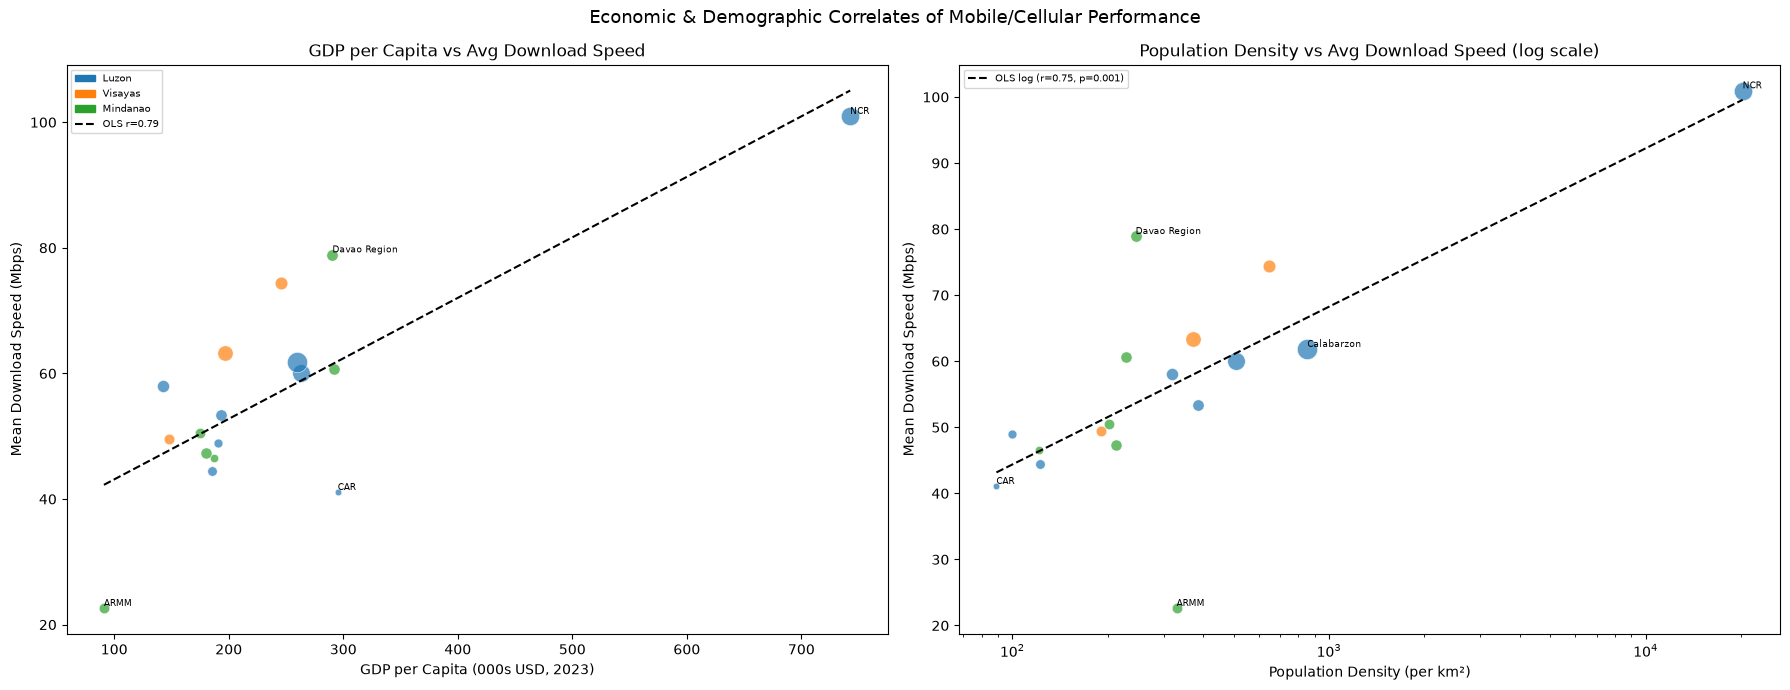

Pearson r (GDP vs download):     0.791  p=0.0002
Pearson r (log density vs download): 0.746  p=0.0006


In [58]:
corr_df = prov_mean.merge(
    prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: GDP vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    # Label outliers
    if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

# OLS trendline
x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
y = corr_df.loc[x.index,'mean_dl']
if x.nunique() > 1:
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
    ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
else:
    r, p = float('nan'), float('nan')
    axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
    ols_handle = []
axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
axes[0].set_ylabel('Mean Download Speed (Mbps)')
axes[0].set_title('GDP per Capita vs Avg Download Speed')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches+ols_handle, fontsize=7)

# Scatter: density vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'],'gray')
    axes[1].scatter(row['density_per_km2'], row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

x2 = corr_df['density_per_km2'].dropna()
y2 = corr_df.loc[x2.index,'mean_dl']
s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
xline2 = np.linspace(x2.min(), x2.max(), 200)
axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
axes[1].set_xlabel('Population Density (per km²)')
axes[1].set_xscale('log')
axes[1].set_ylabel('Mean Download Speed (Mbps)')
axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
axes[1].legend(fontsize=7)

plt.suptitle('Economic & Demographic Correlates of Mobile/Cellular Performance', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")


NDT per tile , facebook , spilt , 

### 9. Upload/Download Ratio — Symmetry Check

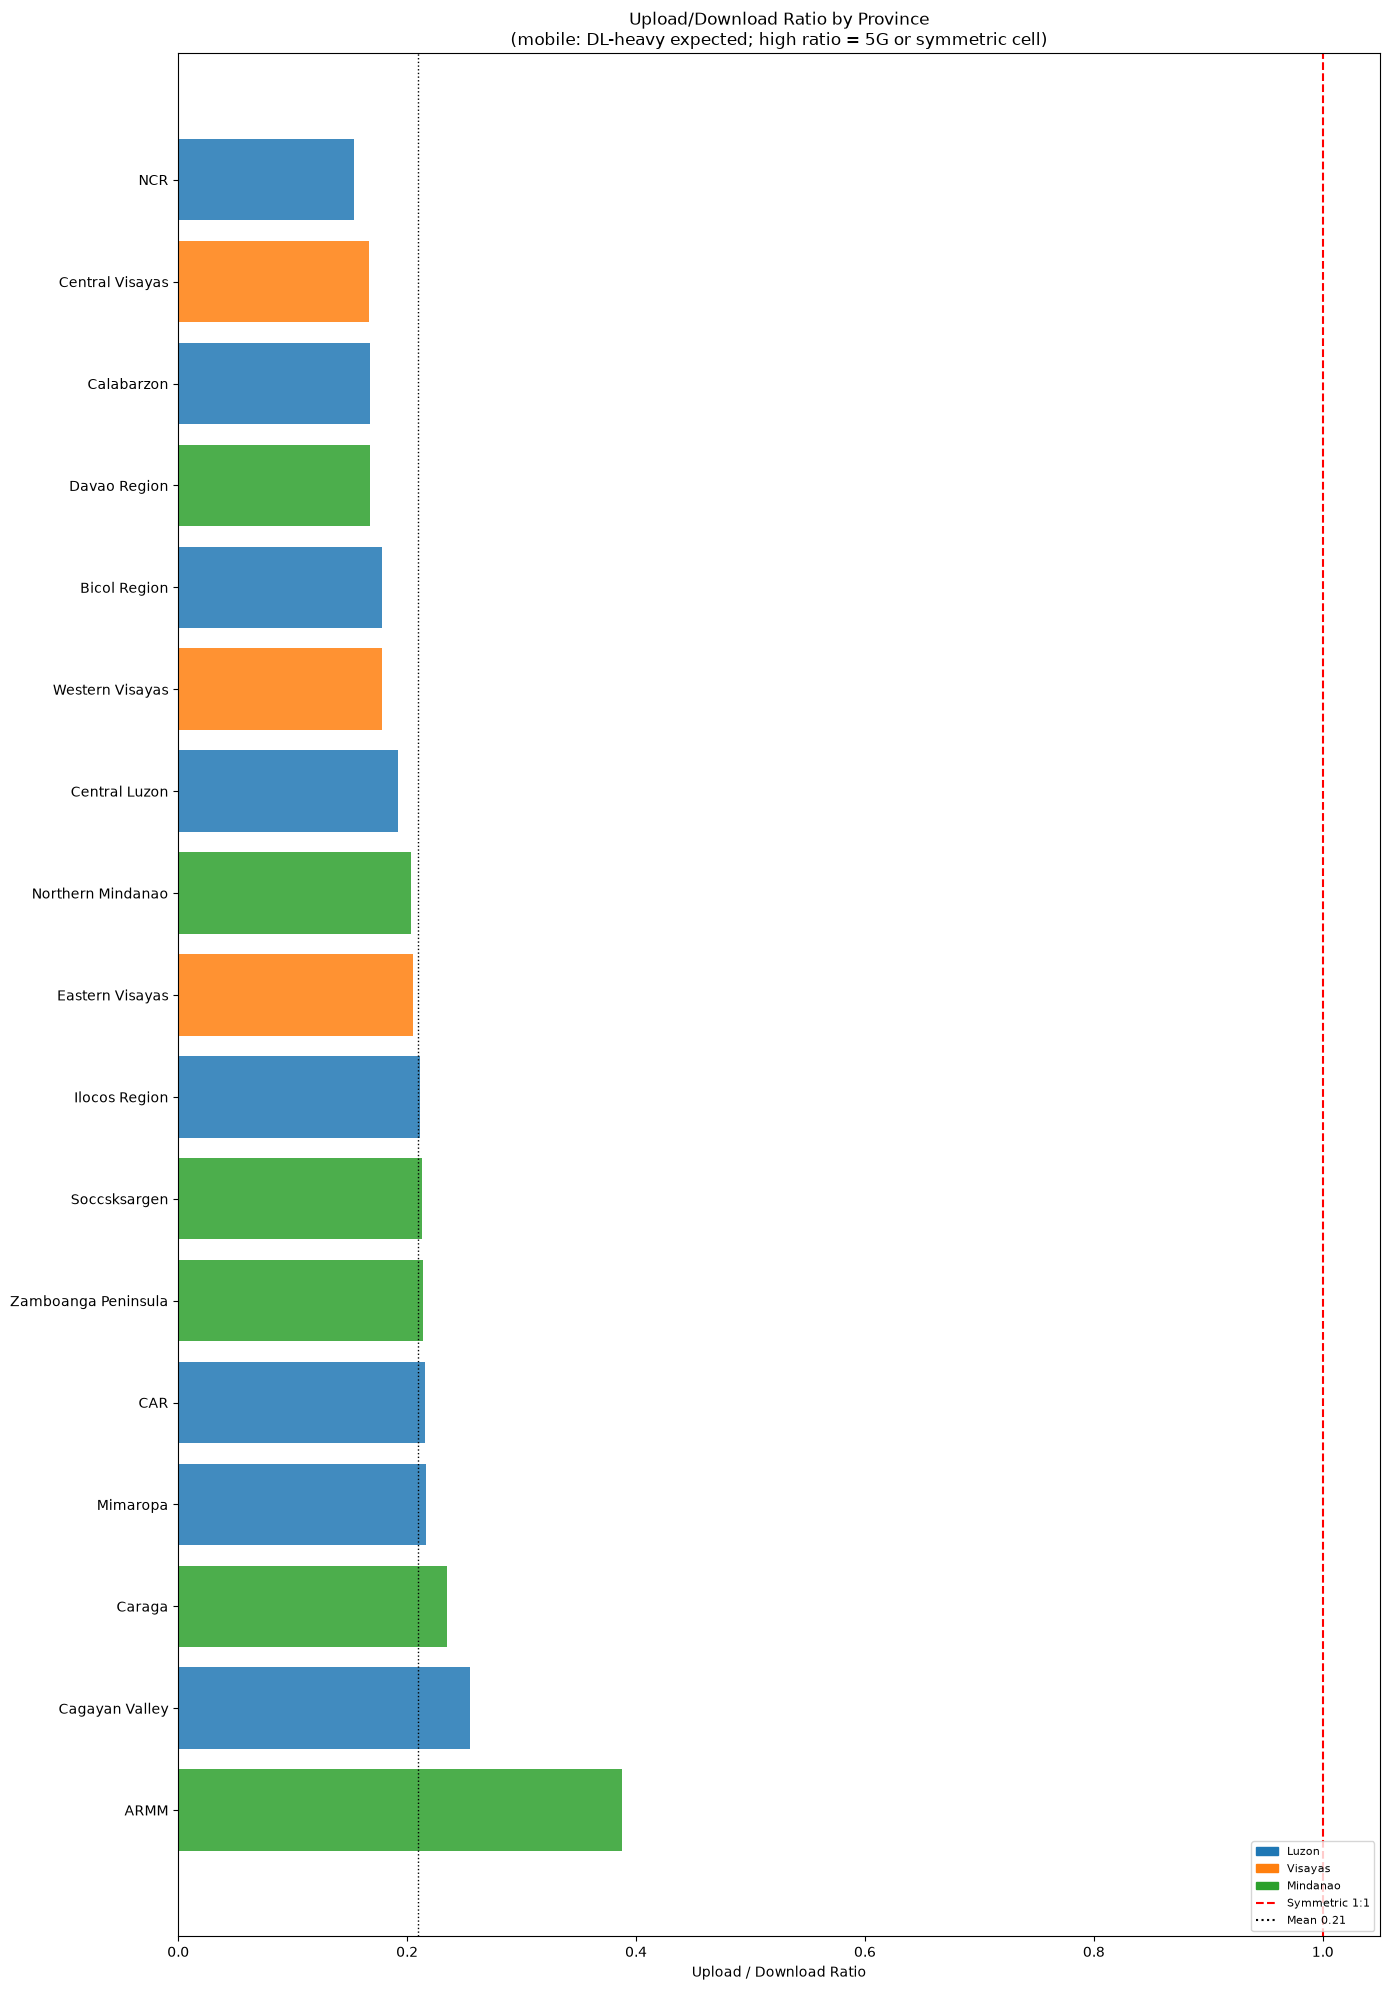

Provinces with UL/DL ratio > 0.5 (0):
Empty DataFrame
Columns: [name, region, ul_dl_ratio]
Index: []


In [59]:
master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']

ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
ax.set_xlabel('Upload / Download Ratio')
ax.set_title('Upload/Download Ratio by Province\n(mobile: DL-heavy expected; high ratio = 5G or symmetric cell)')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[
    plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
    plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
], fontsize=8, loc='lower right')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
plt.show()

divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.5]
print(f"Provinces with UL/DL ratio > 0.5 ({len(divergent_ratio)}):")
print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))


### 10. Anomaly Detection — Province Flags

In [60]:
# === ANOMALY DETECTION (recalibrated from actual data) ===
# National mean UL/DL ratio = 0.852 → flag only clear outliers (z-score based)
# Tier medians are compressed: T1=282, T2=247, T3=246, T4=229 Mbps
# Thresholds set based on observed distributions

from scipy import stats
import numpy as np

master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
        mean_ratio=('ul_dl_ratio','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=False)
)
prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

tier_speed   = prov_mean.groupby('tier')['mean_dl'].median()
national_std = prov_mean['mean_dl'].std()


# infastructure mod

### 12. Full Province Summary Table

In [61]:
summary = prov_mean.merge(
    prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
    on='name', how='left'
).copy()

summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
summary = summary.sort_values('mean_dl', ascending=False).round(2)

print(summary[[
    'name','region','internet_tier',
    'mean_dl','mean_ul','mean_lat',
    'ul_dl_ratio','mean_tests',
    'gdp_per_capita_thb_2021'
]].to_string(index=False))

               name   region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
                NCR    Luzon              1   100.97    15.46     20.26         0.15   168895.67                742614.53
       Davao Region Mindanao              1    78.93    13.12     36.89         0.17    26871.92                290535.65
    Central Visayas  Visayas              2    74.45    12.24     30.36         0.17    56021.92                245591.30
    Western Visayas  Visayas              2    63.31    11.17     35.83         0.18    37956.92                196943.14
         Calabarzon    Luzon              2    61.83    10.23     24.33         0.17   101637.17                259765.51
  Northern Mindanao Mindanao              1    60.64    12.26     34.18         0.20    19818.25                291746.51
      Central Luzon    Luzon              2    60.00    11.39     27.01         0.19    64741.17                263326.87
       Bicol Region    L

### 13. UL/DL Symmetry — Mobile Network Quality Indicator

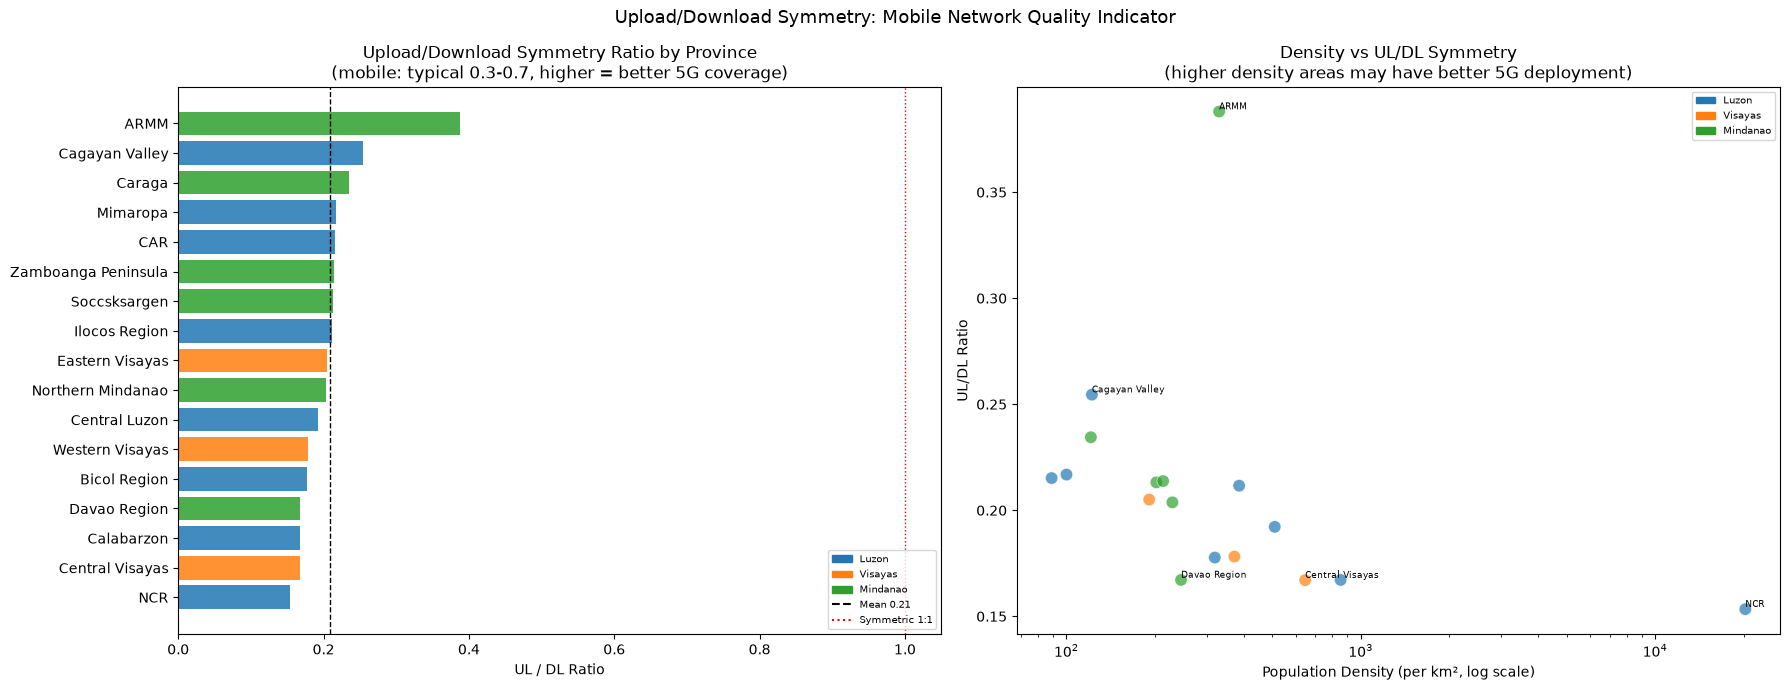

Provinces ratio > 0.5 (relatively symmetric mobile): 0 out of 17
Luzon mean ratio: 0.199
Mindanao mean ratio: 0.237


In [62]:
# Mobile UL/DL ratio: typically 0.3-0.7 (DL-heavy by design)
# 5G NR can be more symmetric; high ratio may indicate 5G coverage

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1,
                label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
axes[0].set_xlabel('UL / DL Ratio')
axes[0].set_title('Upload/Download Symmetry Ratio by Province\n(mobile: typical 0.3-0.7, higher = better 5G coverage)')
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches + [
    plt.Line2D([0],[0],color='black',ls='--',label=f'Mean {prov_mean["mean_ratio"].mean():.2f}'),
    plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
], fontsize=7, loc='lower right')

axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                prov_mean['mean_ratio'].values,
                c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                s=80, alpha=0.7, edgecolors='white', lw=0.5)
for _, row in prov_mean.iterrows():
    if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1) or row['mean_dl'] > prov_mean['mean_dl'].quantile(0.9):
        density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
        if len(density):
            axes[1].annotate(row['name'], (density[0], row['mean_ratio']),
                             fontsize=6.5, ha='left', va='bottom')
axes[1].set_xscale('log')
axes[1].set_xlabel('Population Density (per km², log scale)')
axes[1].set_ylabel('UL/DL Ratio')
axes[1].set_title('Density vs UL/DL Symmetry\n(higher density areas may have better 5G deployment)')
axes[1].legend(handles=patches, fontsize=7)

plt.suptitle('Upload/Download Symmetry: Mobile Network Quality Indicator', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

_top_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmax(), 'region']
_bot_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmin(), 'region']
print(f"Provinces ratio > 0.5 (relatively symmetric mobile): {(prov_mean['mean_ratio'] > 0.5).sum()} out of {len(prov_mean)}")
print(f"{_top_region} mean ratio: {prov_mean[prov_mean['region']==_top_region]['mean_ratio'].mean():.3f}")
print(f"{_bot_region} mean ratio: {prov_mean[prov_mean['region']==_bot_region]['mean_ratio'].mean():.3f}")


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

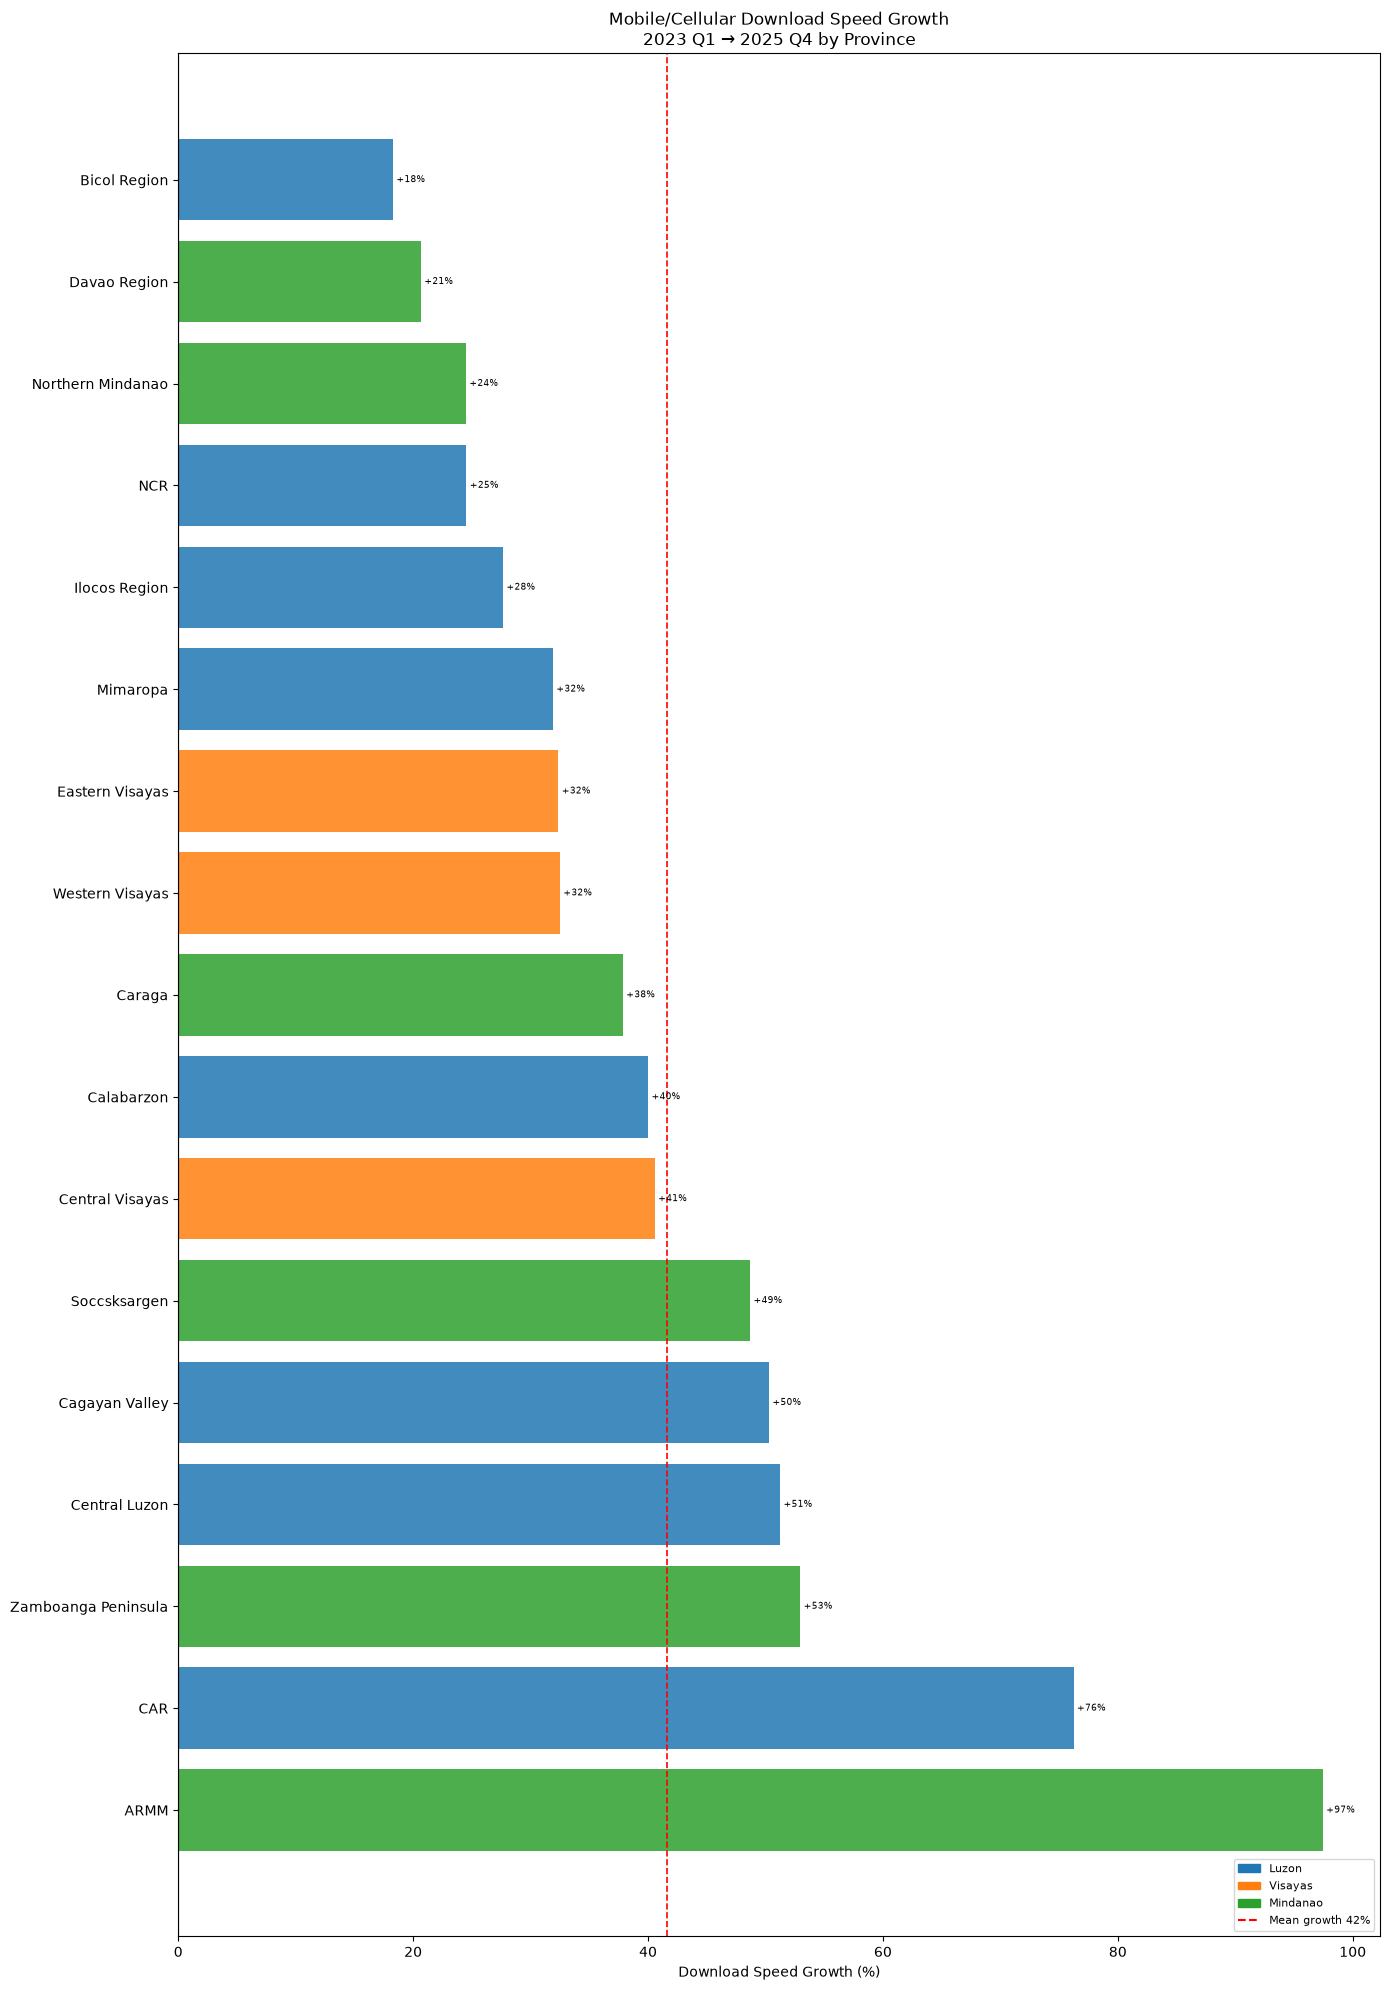

Top 10 fastest growing provinces:
               name   region  internet_tier  pct_growth
               ARMM Mindanao              4   97.448611
                CAR    Luzon              1   76.230766
Zamboanga Peninsula Mindanao              4   52.961131
      Central Luzon    Luzon              2   51.245650
     Cagayan Valley    Luzon              3   50.299049
       Soccsksargen Mindanao              4   48.690415
    Central Visayas  Visayas              2   40.569687
         Calabarzon    Luzon              2   40.006206
             Caraga Mindanao              3   37.851919
    Western Visayas  Visayas              2   32.493651

Bottom 5 (slowest growth or decline):
             name   region  internet_tier  pct_growth
     Bicol Region    Luzon              4   18.281452
     Davao Region Mindanao              1   20.659976
Northern Mindanao Mindanao              1   24.493087
              NCR    Luzon              1   24.537446
    Ilocos Region    Luzon              3

In [63]:
first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

growth_df = growth.reset_index()
growth_df.columns = ['name','pct_growth']
growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in growth_df['region']]
bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2,
           label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
for bar, val in zip(bars, growth_df['pct_growth']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', fontsize=6.5)
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f'Mean growth {growth_df["pct_growth"].mean():.0f}%')],
          fontsize=8, loc='lower right')
ax.set_xlabel('Download Speed Growth (%)')
ax.set_title('Mobile/Cellular Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/20_density_vs_speed.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 fastest growing provinces:")
print(growth_df.nlargest(10,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))
print("\nBottom 5 (slowest growth or decline):")
print(growth_df.nsmallest(5,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))


### 15. Deep Dive — The Divergent Ones

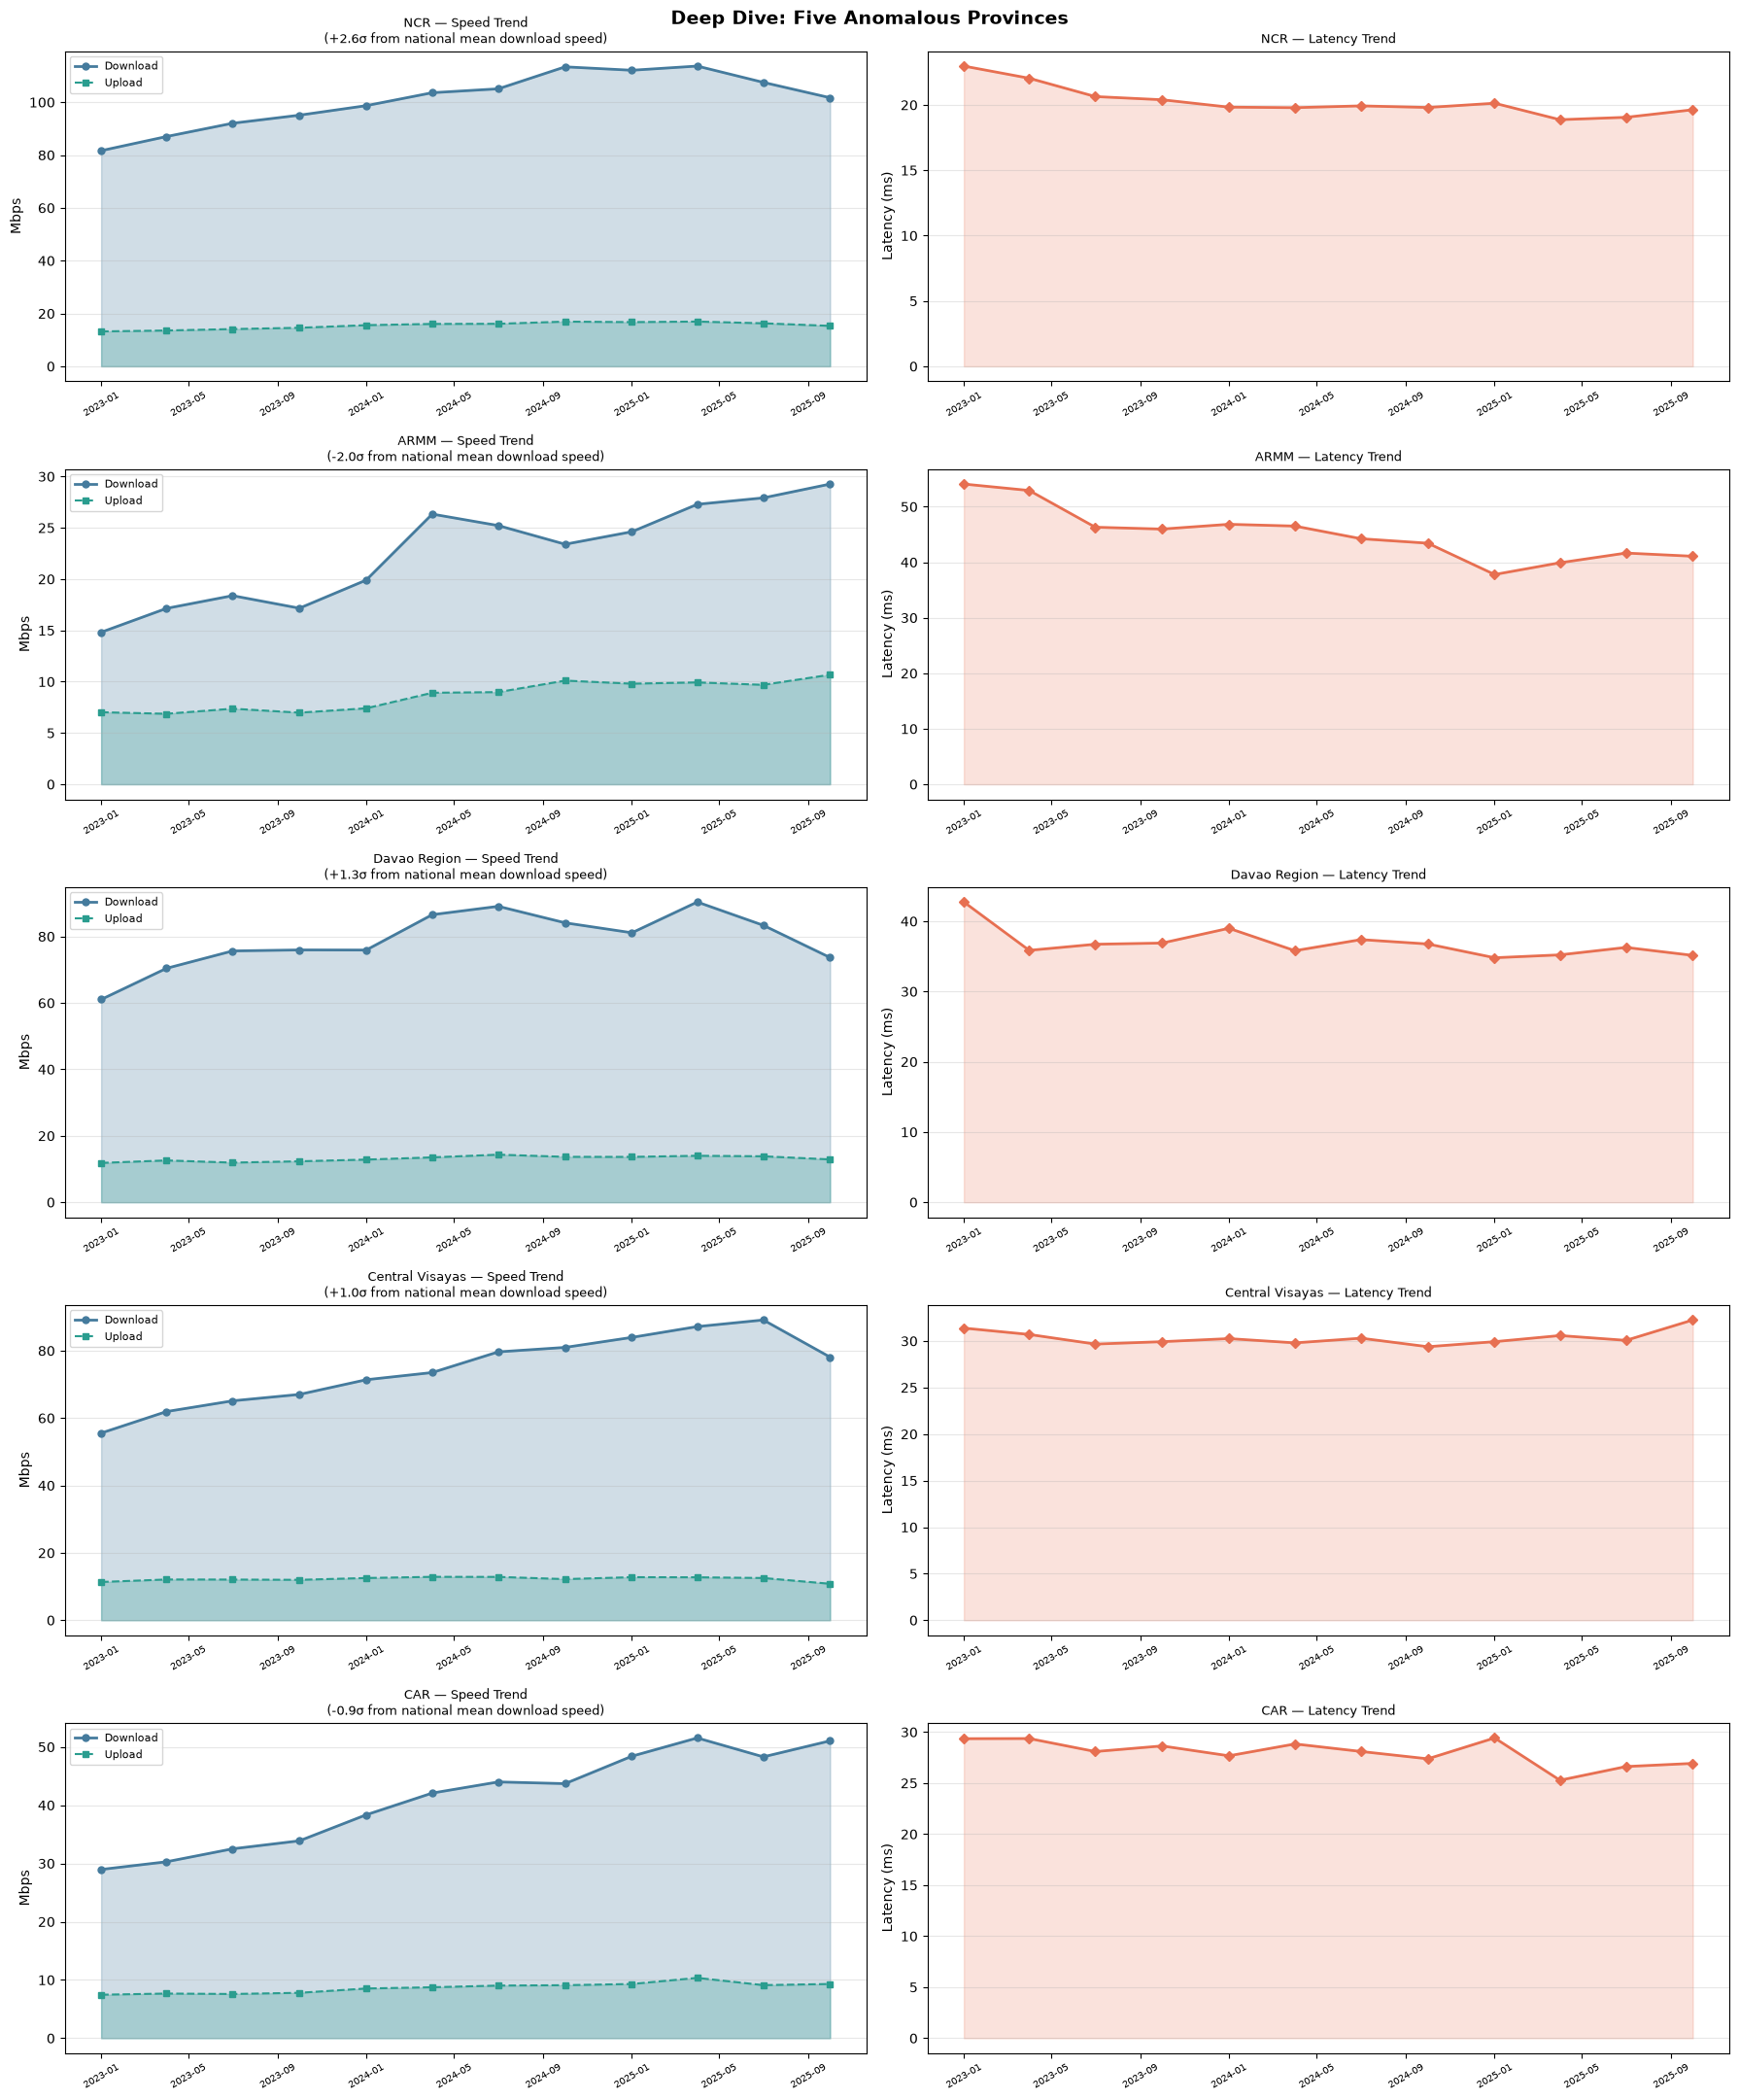

In [64]:
# Focus on the 5 most extreme performers (data-driven selection, no anomaly flags)
_pm = prov_mean.copy()
_pm['z'] = (_pm['mean_dl'] - _pm['mean_dl'].mean()) / _pm['mean_dl'].std()
_top_divergent_df = _pm.reindex(_pm['z'].abs().sort_values(ascending=False).index).head(5)
DIVERGENT = {
    row['name']: f"{row['z']:+.1f}σ from national mean download speed"
    for _, row in _top_divergent_df.iterrows()
}

fig, axes = plt.subplots(len(DIVERGENT), 2, figsize=(18, 22))

quarter_order = sorted(master['label'].unique())

for ax_row, (prov, note) in zip(axes, DIVERGENT.items()):
    df_p = master[master['name']==prov].sort_values('label')
    
    # Download + upload trend
    ax_row[0].fill_between(df_p['period_start'], df_p['avg_d_mbps'], alpha=0.25, color='#457b9d')
    ax_row[0].plot(df_p['period_start'], df_p['avg_d_mbps'], 'o-', color='#457b9d', label='Download', lw=2, markersize=5)
    ax_row[0].fill_between(df_p['period_start'], df_p['avg_u_mbps'], alpha=0.25, color='#2a9d8f')
    ax_row[0].plot(df_p['period_start'], df_p['avg_u_mbps'], 's--', color='#2a9d8f', label='Upload', lw=1.5, markersize=4)
    ax_row[0].set_title(f'{prov} — Speed Trend\n({note})', fontsize=9)
    ax_row[0].set_ylabel('Mbps'); ax_row[0].legend(fontsize=8); ax_row[0].grid(axis='y', alpha=0.3)
    ax_row[0].tick_params(axis='x', rotation=30, labelsize=7)
    
    # Latency trend
    ax_row[1].plot(df_p['period_start'], df_p['avg_lat_ms_wt'], 'D-', color='#e76f51', lw=2, markersize=5)
    ax_row[1].fill_between(df_p['period_start'], df_p['avg_lat_ms_wt'], alpha=0.2, color='#e76f51')
    ax_row[1].set_title(f'{prov} — Latency Trend', fontsize=9)
    ax_row[1].set_ylabel('Latency (ms)'); ax_row[1].grid(axis='y', alpha=0.3)
    ax_row[1].tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Deep Dive: Five Anomalous Provinces', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/21_deep_dive_divergent.png', dpi=150, bbox_inches='tight')
plt.show()


### 16. EDA Key Findings Summary

## Key Findings from EDA

---

In [65]:
from scipy import stats as scipy_stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

_DATA_ROOT = '/home/chissanupun/Desktop/Code/lab/cnc/ds/internet-measurement/data'

# Fallback: load master and prov_ref if not already in scope
if 'master' not in dir() or master is None:
    master = pd.read_parquet(f'{_DATA_ROOT}/ookla/processed/master_province_quarterly.parquet')
    print("Loaded master from processed parquet")
if 'prov_ref' not in dir() or prov_ref is None:
    prov_ref = pd.read_csv(f'{_DATA_ROOT}/reference/province_reference.csv')
    print("Loaded prov_ref from CSV")

# ── Build per-province summary (self-contained) ────────────────────────────────
divergent_df = (
    master.groupby(['name', 'region'])
    .agg(
        mean_dl=('avg_d_mbps', 'mean'),
        mean_ul=('avg_u_mbps', 'mean'),
        mean_lat=('avg_lat_ms_wt', 'mean'),
        mean_tests=('total_tests', 'mean'),
    )
    .reset_index()
)

# Temporal instability: std of quarterly download speed
temp_std = master.groupby('name')['avg_d_mbps'].std().rename('std_dl')
divergent_df = divergent_df.merge(temp_std, on='name', how='left')
divergent_df['cv_dl'] = divergent_df['std_dl'] / divergent_df['mean_dl']

# Merge reference cols
divergent_df = divergent_df.merge(
    prov_ref[['province_en','pop_2024','density_per_km2',
              'gdp_per_capita_thb_2021','internet_tier','area_km2']]
    .rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

divergent_df['ul_dl_ratio']        = divergent_df['mean_ul'] / divergent_df['mean_dl']
divergent_df['tests_per_1000_pop'] = divergent_df['mean_tests'] / divergent_df['pop_2024'] * 1_000

print(f"Provinces in analysis: {len(divergent_df)}")
print(divergent_df[['name','region','internet_tier','mean_dl','ul_dl_ratio','tests_per_1000_pop']].head(5).to_string(index=False))


Provinces in analysis: 17
          name   region  internet_tier   mean_dl  ul_dl_ratio  tests_per_1000_pop
          ARMM Mindanao              4 22.621783     0.382313            0.897557
  Bicol Region    Luzon              4 58.015404     0.176162            2.829960
           CAR    Luzon              1 41.088600     0.210933            5.366684
Cagayan Valley    Luzon              3 44.403067     0.251546            2.561122
    Calabarzon    Luzon              2 61.830149     0.165403            6.002230


In [66]:
# ── Dimension 1: Tier residual ─────────────────────────────────────────────────
tier_med = divergent_df.groupby('internet_tier')['mean_dl'].median()
divergent_df['tier_expected']   = divergent_df['internet_tier'].map(tier_med)
divergent_df['tier_residual']   = (divergent_df['mean_dl'] - divergent_df['tier_expected']) / divergent_df['tier_expected']
divergent_df['tier_residual_z'] = (divergent_df['tier_residual'] - divergent_df['tier_residual'].mean()) / divergent_df['tier_residual'].std()

# ── Dimension 2: GDP residual (OLS on log-GDP) ─────────────────────────────────
log_gdp = np.log(divergent_df['gdp_per_capita_thb_2021'])
if log_gdp.nunique() > 1:
    slope_g, int_g, r_g, p_g, _ = scipy_stats.linregress(log_gdp, divergent_df['mean_dl'])
    divergent_df['gdp_expected']   = int_g + slope_g * log_gdp
    divergent_df['gdp_residual']   = divergent_df['mean_dl'] - divergent_df['gdp_expected']
    divergent_df['gdp_residual_z'] = scipy_stats.zscore(divergent_df['gdp_residual'])
else:
    # GDP per capita uniform across regions (e.g. Singapore: national-only data) — dimension contributes nothing
    slope_g, int_g, r_g, p_g = 0.0, divergent_df['mean_dl'].mean(), float('nan'), float('nan')
    divergent_df['gdp_expected']   = int_g
    divergent_df['gdp_residual']   = 0.0
    divergent_df['gdp_residual_z'] = 0.0

# ── Dimension 3: Density residual (OLS on log-density) ────────────────────────
log_den = np.log1p(divergent_df['density_per_km2'])
slope_d, int_d, r_d, p_d, _ = scipy_stats.linregress(log_den, divergent_df['mean_dl'])
divergent_df['den_expected']   = int_d + slope_d * log_den
divergent_df['den_residual_z'] = scipy_stats.zscore(divergent_df['mean_dl'] - divergent_df['den_expected'])

# ── Dimension 4: Regional z-score (speed within region) ───────────────────────
divergent_df['regional_z'] = divergent_df.groupby('region')['mean_dl'].transform(
    lambda x: scipy_stats.zscore(x) if len(x) > 1 else pd.Series(np.zeros(len(x)), index=x.index)
)

# ── Dimension 5: UL/DL ratio z-score ──────────────────────────────────────────
divergent_df['ratio_z'] = scipy_stats.zscore(divergent_df['ul_dl_ratio'])

# ── Dimension 6: Within-region latency z-score ────────────────────────────────
divergent_df['lat_regional_z'] = divergent_df.groupby('region')['mean_lat'].transform(
    lambda x: scipy_stats.zscore(x) if len(x) > 1 else pd.Series(np.zeros(len(x)), index=x.index)
)

# ── Dimension 7: Coverage z-score (tests per 1000 pop) ────────────────────────
divergent_df['coverage_z'] = scipy_stats.zscore(divergent_df['tests_per_1000_pop'])

# ── Composite divergence score (sum of absolute z-scores) ──────────────────────
divergent_df['divergence_score'] = (
    np.abs(divergent_df['tier_residual_z']) +
    np.abs(divergent_df['gdp_residual_z']) +
    np.abs(divergent_df['den_residual_z']) +
    np.abs(divergent_df['regional_z']) +
    np.abs(divergent_df['ratio_z']) +
    np.abs(divergent_df['lat_regional_z']) +
    np.abs(divergent_df['coverage_z'])
)

print(f"GDP-speed OLS:     r = {r_g:.3f}, slope = {slope_g:.2f} Mbps per log-unit GDP")
print(f"Density-speed OLS: r = {r_d:.3f}, slope = {slope_d:.2f} Mbps per log-unit density")
print()
print("Top 15 divergentest provinces:")
cols = ['name','region','internet_tier','mean_dl','divergence_score',
        'gdp_residual_z','den_residual_z','regional_z','ratio_z','lat_regional_z','coverage_z']
print(divergent_df.nlargest(15,'divergence_score')[cols].to_string(index=False))


GDP-speed OLS:     r = 0.822, slope = 32.19 Mbps per log-unit GDP
Density-speed OLS: r = 0.746, slope = 10.41 Mbps per log-unit density

Top 15 divergentest provinces:
               name   region  internet_tier    mean_dl  divergence_score  gdp_residual_z  den_residual_z  regional_z   ratio_z  lat_regional_z  coverage_z
               ARMM Mindanao              4  22.621783         14.247825       -0.649159       -3.057933   -1.685915  3.450576        1.627628   -1.370734
                NCR    Luzon              1 100.973404         10.945366        0.478592        0.125263    2.428863 -1.063857       -1.759162    3.030682
    Central Visayas  Visayas              2  74.447938          8.259452        1.430536        0.960699    1.178670 -0.840865       -1.348396    1.601031
       Davao Region Mindanao              1  78.925126          7.714538        1.332884        2.266241    1.648019 -0.804899       -0.787649    0.241025
                CAR    Luzon              1  41.088600   

### 18. Tier vs Actual Speed — Expectation Gap

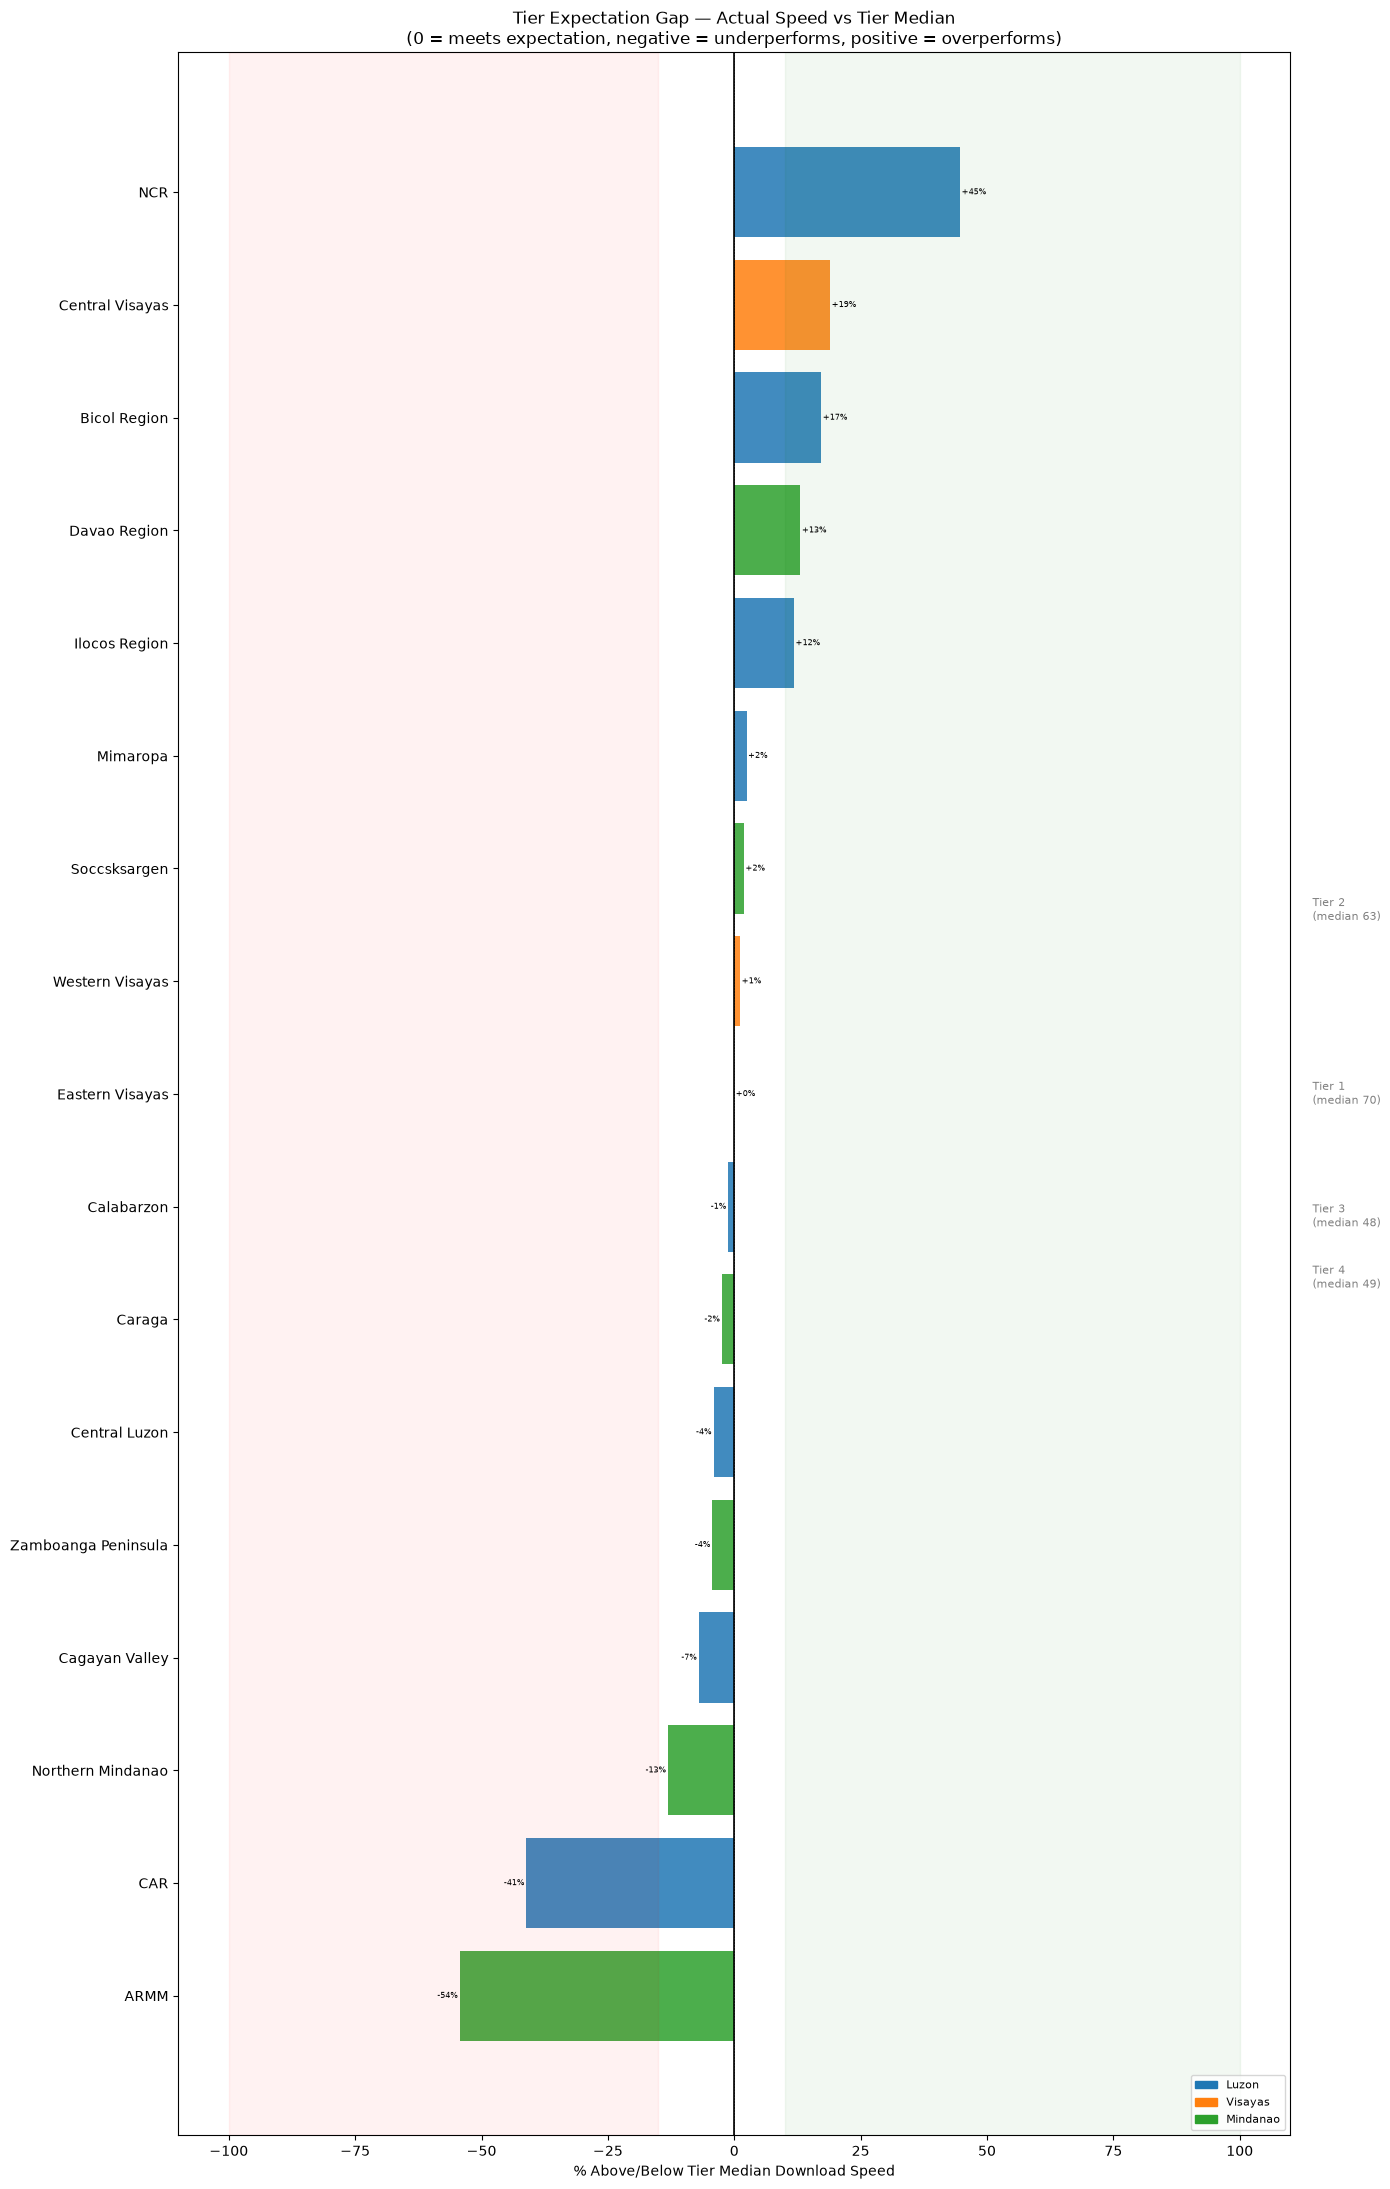

Biggest underperformers vs tier expectation:
               name  internet_tier   mean_dl  tier_expected  tier_residual
               ARMM              4 22.621783      49.490298      -0.542905
                CAR              1 41.088600      69.783402      -0.411198
  Northern Mindanao              1 60.641677      69.783402      -0.131001
     Cagayan Valley              3 44.403067      47.748645      -0.070066
Zamboanga Peninsula              4 47.345609      49.490298      -0.043336
      Central Luzon              2 60.003332      62.569261      -0.041009
             Caraga              3 46.583065      47.748645      -0.024411
         Calabarzon              2 61.830149      62.569261      -0.011813

Biggest overperformers vs tier expectation:
           name  internet_tier    mean_dl  tier_expected  tier_residual
            NCR              1 100.973404      69.783402       0.446954
Central Visayas              2  74.447938      62.569261       0.189848
   Bicol Region    

In [67]:
# Show each province's % deviation from its tier median
tier_gap = divergent_df[['name','region','internet_tier','mean_dl','tier_expected','tier_residual']].copy()
tier_gap = tier_gap.sort_values('tier_residual')

fig, ax = plt.subplots(figsize=(14, 22))

region_colors = {
    'Luzon': '#1f77b4',
    'Visayas': '#ff7f0e',
    'Mindanao': '#2ca02c',
}

colors = [region_colors.get(r, 'gray') for r in tier_gap['region']]
bars = ax.barh(tier_gap['name'], tier_gap['tier_residual'] * 100, color=colors, alpha=0.85)

# Tier median reference lines
ax.axvline(0, color='black', lw=1.2, label='Tier median (expected)')

# Annotate bars
for bar, val in zip(bars, tier_gap['tier_residual']):
    x = bar.get_width()
    ax.text(x + (0.3 if x >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
            f'{val*100:+.0f}%', va='center', ha='left' if x >= 0 else 'right', fontsize=6)

# Tier grouping lines
tier_boundaries = tier_gap.groupby('internet_tier').apply(lambda g: (g.index.min(), g.index.max()))
for t in sorted(tier_gap['internet_tier'].unique()):
    grp = tier_gap[tier_gap['internet_tier'] == t]
    median = tier_med[t]
    ax.axvline(0, color='black', lw=0.4, ls='--', alpha=0.4)

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, fontsize=8, loc='lower right')
ax.set_xlabel('% Above/Below Tier Median Download Speed')
ax.set_title('Tier Expectation Gap — Actual Speed vs Tier Median\n'
             '(0 = meets expectation, negative = underperforms, positive = overperforms)', fontsize=12)
ax.axvspan(-100, -15, alpha=0.05, color='red', label='Strong underperform')
ax.axvspan(10, 100, alpha=0.05, color='green')

# Annotate Tier brackets on y-axis
for t in sorted(tier_gap['internet_tier'].unique()):
    grp_idx = tier_gap[tier_gap['internet_tier']==t].index
    grp_pos = [list(tier_gap.index).index(i) for i in grp_idx]
    if grp_pos:
        mid = (min(grp_pos) + max(grp_pos)) / 2
        ax.annotate(f'Tier {t}\n(median {tier_med[t]:.0f})', xy=(1.02, mid/len(tier_gap)),
                    xycoords='axes fraction', va='center', fontsize=8, color='gray')

plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/22_tier_expectation_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Biggest underperformers vs tier expectation:")
print(tier_gap.nsmallest(8,'tier_residual')[['name','internet_tier','mean_dl','tier_expected','tier_residual']].to_string(index=False))
print()
print("Biggest overperformers vs tier expectation:")
print(tier_gap.nlargest(8,'tier_residual')[['name','internet_tier','mean_dl','tier_expected','tier_residual']].to_string(index=False))


### 19. GDP per Capita vs Download Speed — Who Breaks the Rule?

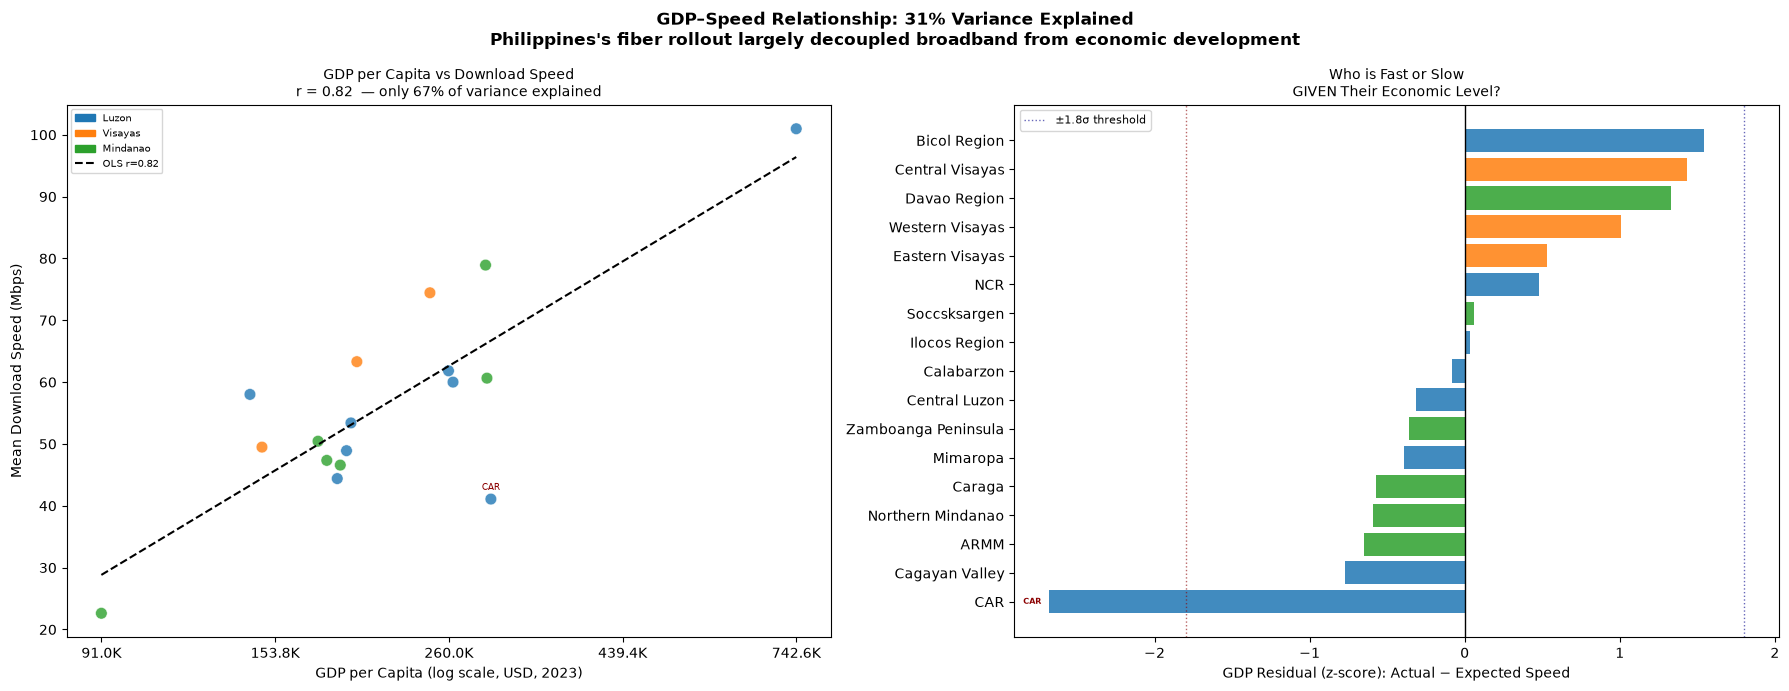

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: GDP scatter ──────────────────────────────────────────────────────────
ax = axes[0]
gdp_vals = divergent_df['gdp_per_capita_thb_2021']
colors_scatter = [region_colors.get(r, 'gray') for r in divergent_df['region']]

sc = ax.scatter(np.log(gdp_vals), divergent_df['mean_dl'],
                c=colors_scatter, s=70, alpha=0.8, edgecolors='white', lw=0.4)

# OLS line
x_fit = np.linspace(np.log(gdp_vals.min()), np.log(gdp_vals.max()), 200)
ax.plot(x_fit, int_g + slope_g * x_fit, 'k--', lw=1.5,
        label=f'OLS fit  r={r_g:.2f}')

# Label big residuals
threshold = 1.8
for _, row in divergent_df.iterrows():
    if abs(row['gdp_residual_z']) > threshold:
        ax.annotate(row['name'],
                    (np.log(row['gdp_per_capita_thb_2021']), row['mean_dl']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    color='darkred' if row['gdp_residual_z'] < 0 else 'darkblue')

ax.set_xlabel('GDP per Capita (log scale, USD, 2023)')
ax.set_ylabel('Mean Download Speed (Mbps)')
ax.set_title(f'GDP per Capita vs Download Speed\nr = {r_g:.2f}  — only {r_g**2*100:.0f}% of variance explained',
             fontsize=10)

# x-tick labels spaced across the actual data range (log scale)
_tick_vals = np.geomspace(gdp_vals.min(), gdp_vals.max(), 5)
ax.set_xticks(np.log(_tick_vals))
ax.set_xticklabels([f'{v/1000:.1f}K' if v >= 1000 else f'{v:.0f}' for v in _tick_vals])

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',label=f'OLS r={r_g:.2f}')],
          fontsize=7)

# ── Right: residual bar chart ──────────────────────────────────────────────────
ax2 = axes[1]
resid_sorted = divergent_df.sort_values('gdp_residual_z')
cols2 = [region_colors.get(r, 'gray') for r in resid_sorted['region']]
bars2 = ax2.barh(resid_sorted['name'], resid_sorted['gdp_residual_z'], color=cols2, alpha=0.85)
ax2.axvline(0, color='black', lw=1)
ax2.axvline(1.8, color='darkblue', ls=':', lw=1, alpha=0.6, label='±1.8σ threshold')
ax2.axvline(-1.8, color='darkred', ls=':', lw=1, alpha=0.6)
ax2.set_xlabel('GDP Residual (z-score): Actual − Expected Speed')
ax2.set_title('Who is Fast or Slow\nGIVEN Their Economic Level?', fontsize=10)
ax2.legend(fontsize=8)
# Add province labels for outliers
for bar, (_, row) in zip(bars2, resid_sorted.iterrows()):
    if abs(row['gdp_residual_z']) > 1.8:
        x = bar.get_width()
        ax2.text(x + (0.05 if x >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                 row['name'], va='center', ha='left' if x >= 0 else 'right', fontsize=5.5,
                 color='darkblue' if x > 0 else 'darkred', fontweight='bold')

plt.suptitle('GDP–Speed Relationship: 31% Variance Explained\n'
             'Philippines\'s fiber rollout largely decoupled broadband from economic development',
             fontsize=12, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/23_gdp_residual_bar.png', dpi=150, bbox_inches='tight')
plt.show()


### 20. Population Density vs Speed — Greenfield Fiber Effect

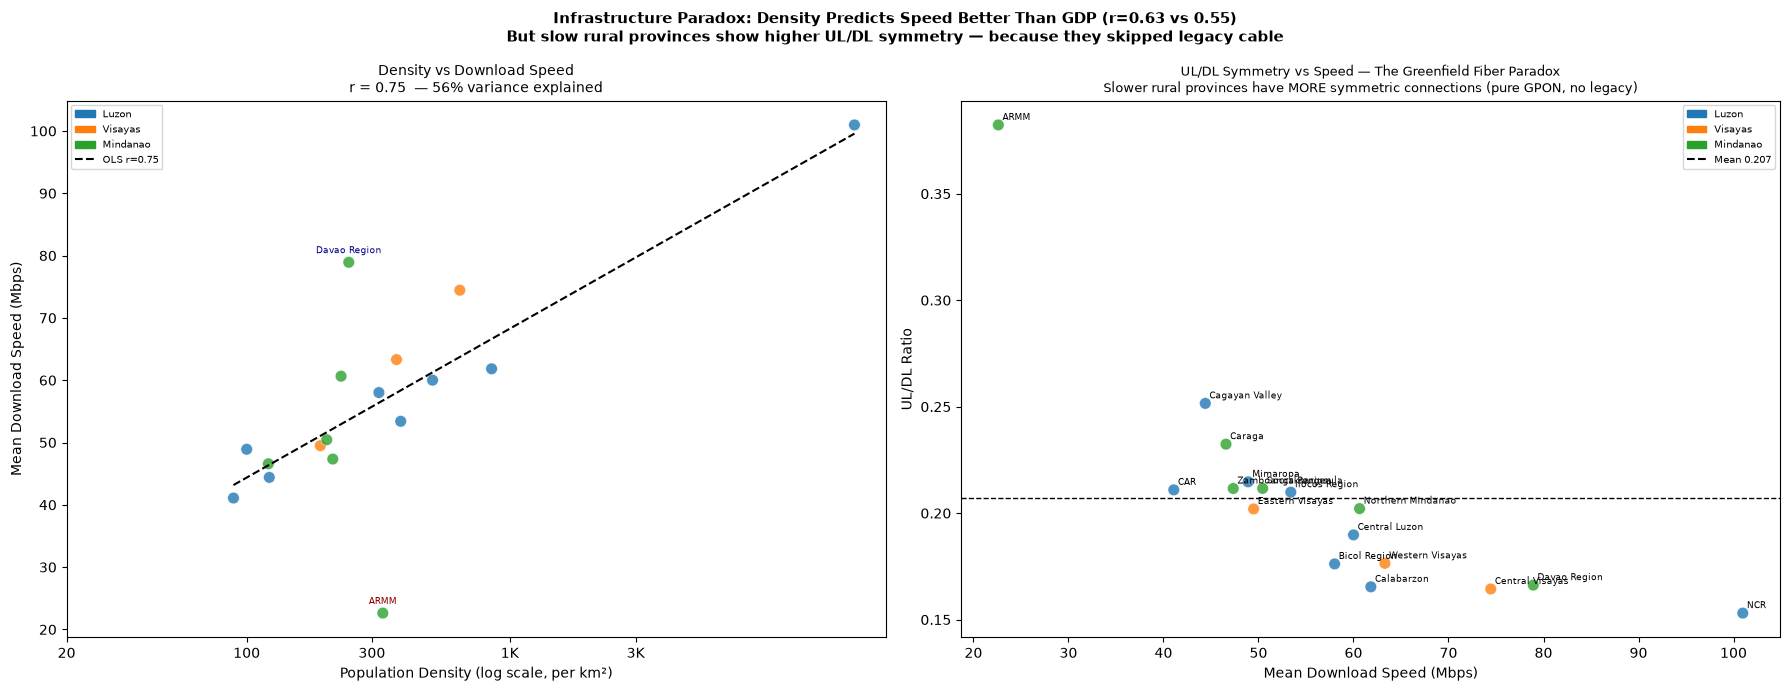

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Density scatter ──────────────────────────────────────────────────────
ax = axes[0]
den_vals = divergent_df['density_per_km2']
colors_s = [region_colors.get(r, 'gray') for r in divergent_df['region']]

ax.scatter(np.log1p(den_vals), divergent_df['mean_dl'],
           c=colors_s, s=70, alpha=0.8, edgecolors='white', lw=0.4)

x_fit2 = np.linspace(np.log1p(den_vals.min()), np.log1p(den_vals.max()), 200)
ax.plot(x_fit2, int_d + slope_d * x_fit2, 'k--', lw=1.5, label=f'OLS r={r_d:.2f}')

for _, row in divergent_df.iterrows():
    if abs(row['den_residual_z']) > 2.0:
        ax.annotate(row['name'],
                    (np.log1p(row['density_per_km2']), row['mean_dl']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    color='darkred' if row['den_residual_z'] < 0 else 'darkblue')

xticks_den = np.log1p([20, 100, 300, 1000, 3000])
ax.set_xticks(xticks_den)
ax.set_xticklabels(['20','100','300','1K','3K'])
ax.set_xlabel('Population Density (log scale, per km²)')
ax.set_ylabel('Mean Download Speed (Mbps)')
ax.set_title(f'Density vs Download Speed\nr = {r_d:.2f}  — {r_d**2*100:.0f}% variance explained', fontsize=10)
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',label=f'OLS r={r_d:.2f}')],
          fontsize=7)

# ── Right: UL/DL ratio vs DL speed — the "greenfield fiber paradox" ───────────
ax2 = axes[1]
ax2.scatter(divergent_df['mean_dl'], divergent_df['ul_dl_ratio'],
            c=colors_s, s=70, alpha=0.8, edgecolors='white', lw=0.4)

for _, row in divergent_df.iterrows():
    if row['ul_dl_ratio'] > 0.91 or row['ul_dl_ratio'] < 0.80 or row['mean_dl'] < 170:
        ax2.annotate(row['name'], (row['mean_dl'], row['ul_dl_ratio']),
                     fontsize=6.5, ha='left', va='bottom',
                     xytext=(3, 2), textcoords='offset points')

ax2.axhline(divergent_df['ul_dl_ratio'].mean(), color='black', ls='--', lw=1,
            label=f"Mean ratio {divergent_df['ul_dl_ratio'].mean():.3f}")
ax2.set_xlabel('Mean Download Speed (Mbps)')
ax2.set_ylabel('UL/DL Ratio')
ax2.set_title('UL/DL Symmetry vs Speed — The Greenfield Fiber Paradox\n'
              'Slower rural provinces have MORE symmetric connections (pure GPON, no legacy)', fontsize=9)
ax2.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',
           label=f'Mean {divergent_df["ul_dl_ratio"].mean():.3f}')], fontsize=7)

# Add trend arrow annotation
ax2.annotate('← slower but more symmetric\n   (rural greenfield fiber)',
             xy=(155, 0.905), fontsize=7.5, color='#6d6875',
             bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))
ax2.annotate('faster but less symmetric →\n(urban legacy cable mix)',
             xy=(285, 0.800), fontsize=7.5, color='#e63946',
             bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))

plt.suptitle('Infrastructure Paradox: Density Predicts Speed Better Than GDP (r=0.63 vs 0.55)\n'
             'But slow rural provinces show higher UL/DL symmetry — because they skipped legacy cable',
             fontsize=11, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/24_uldl_greenfield.png', dpi=150, bbox_inches='tight')
plt.show()


### 21. Ookla Coverage — Tests per 1,000 Population

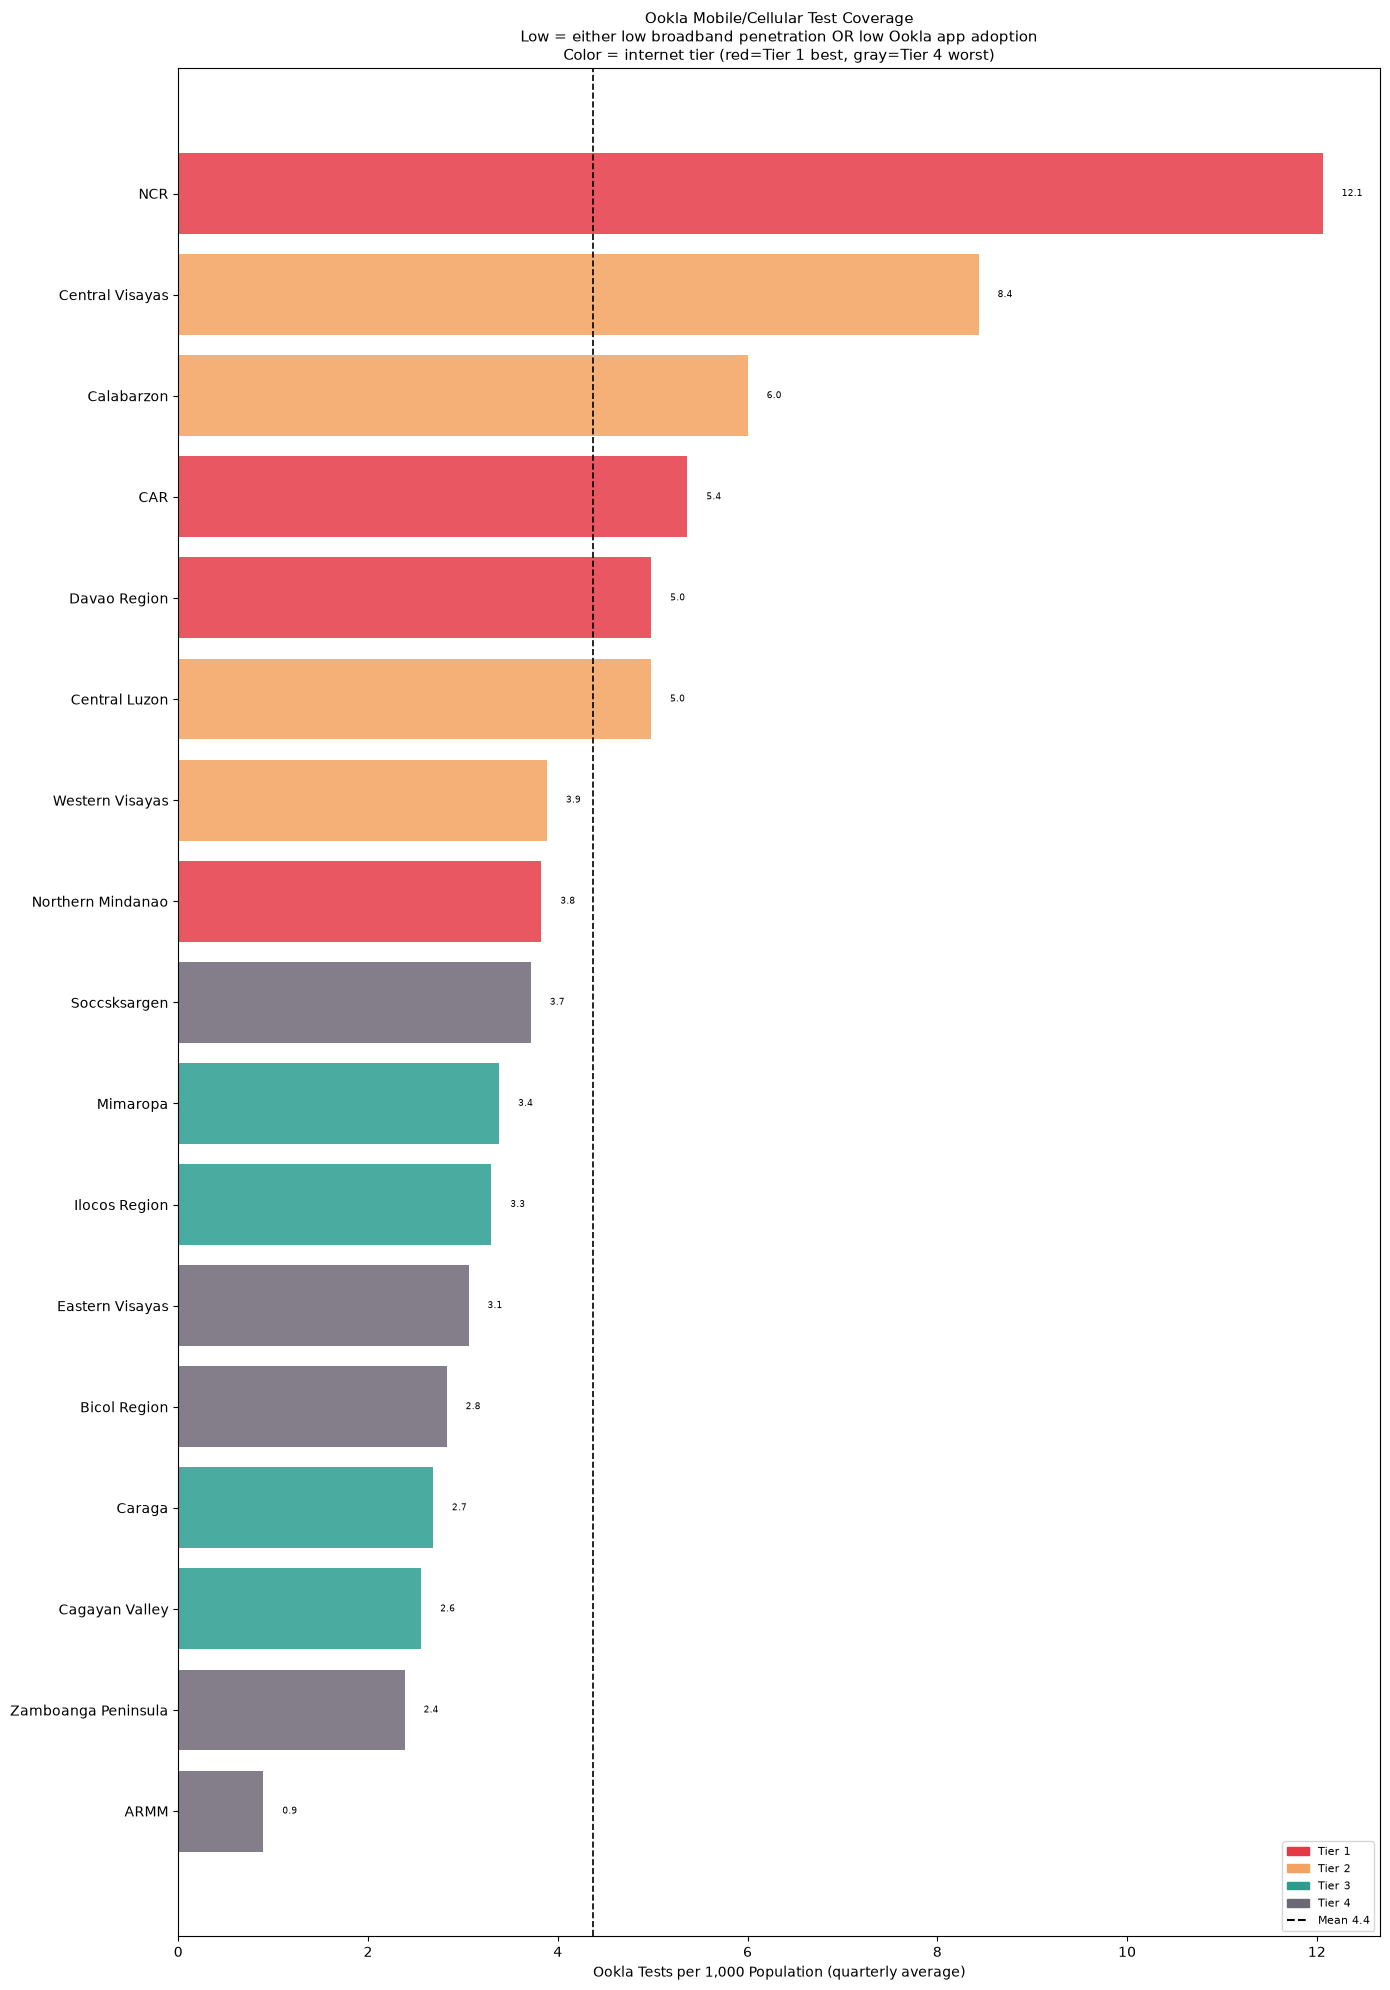

Top coverage (tests per 1000 pop):
             name   region  internet_tier  tests_per_1000_pop    mean_tests  pop_2024
              NCR    Luzon              1           12.062468 168895.666667  14001751
  Central Visayas  Visayas              2            8.435924  56021.916667   6640875
       Calabarzon    Luzon              2            6.002230 101637.166667  16933234
              CAR    Luzon              1            5.366684   9708.250000   1808985
     Davao Region Mindanao              1            4.986048  26871.916667   5389422
    Central Luzon    Luzon              2            4.984279  64741.166667  12989074
  Western Visayas  Visayas              2            3.886299  37956.916667   9766855
Northern Mindanao Mindanao              1            3.827154  19818.250000   5178326

Bottom coverage:
               name   region  internet_tier  tests_per_1000_pop   mean_tests  pop_2024
               ARMM Mindanao              4            0.897557  4079.833333   4545486

In [70]:
# Tests per 1000 pop = proxy for (broadband penetration × Ookla app adoption × tech-savviness)
cov = divergent_df.sort_values('tests_per_1000_pop')
tier_palette = {1:'#e63946', 2:'#f4a261', 3:'#2a9d8f', 4:'#6d6875'}
colors_cov = [tier_palette.get(int(t), 'gray') for t in cov['internet_tier']]

fig, ax = plt.subplots(figsize=(14, 20))
bars = ax.barh(cov['name'], cov['tests_per_1000_pop'], color=colors_cov, alpha=0.85)
ax.axvline(divergent_df['tests_per_1000_pop'].mean(), color='black', ls='--', lw=1.2,
           label=f"National mean {divergent_df['tests_per_1000_pop'].mean():.1f}")

for bar, val in zip(bars, cov['tests_per_1000_pop']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=6.2)

patches_t = [mpatches.Patch(color=v, label=f'Tier {k}') for k, v in tier_palette.items()]
ax.legend(handles=patches_t + [plt.Line2D([0],[0],color='black',ls='--',
           label=f'Mean {divergent_df["tests_per_1000_pop"].mean():.1f}')], fontsize=8)
ax.set_xlabel('Ookla Tests per 1,000 Population (quarterly average)')
ax.set_title('Ookla Mobile/Cellular Test Coverage\n'
             'Low = either low broadband penetration OR low Ookla app adoption\n'
             'Color = internet tier (red=Tier 1 best, gray=Tier 4 worst)', fontsize=11)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/25_test_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top coverage (tests per 1000 pop):")
print(divergent_df.nlargest(8,'tests_per_1000_pop')[
    ['name','region','internet_tier','tests_per_1000_pop','mean_tests','pop_2024']
].to_string(index=False))
print()
print("Bottom coverage:")
print(divergent_df.nsmallest(10,'tests_per_1000_pop')[
    ['name','region','internet_tier','tests_per_1000_pop','mean_tests','pop_2024']
].to_string(index=False))


### 22. Composite Divergence Leaderboard — Top 20 Anomalous Provinces

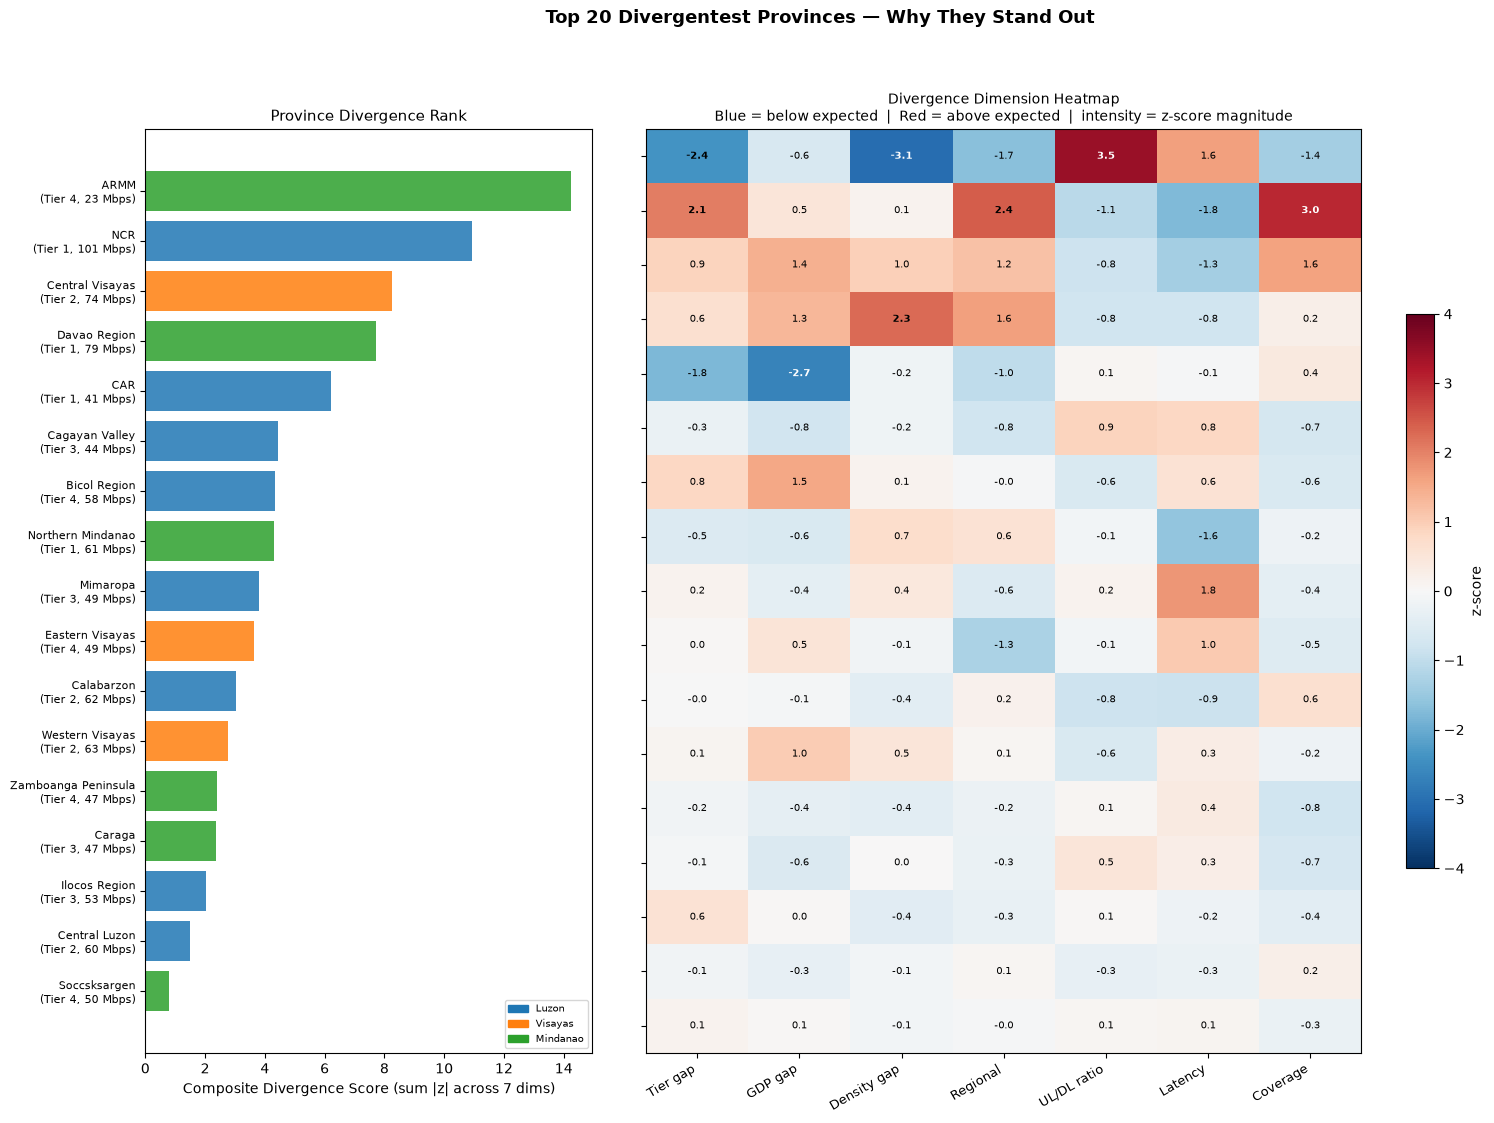


Full leaderboard table:
               name   region  internet_tier    mean_dl  divergence_score     GDP-z     Den-z     Reg-z   Ratio-z     Lat-z     Cov-z
               ARMM Mindanao              4  22.621783         14.247825 -0.649159 -3.057933 -1.685915  3.450576  1.627628 -1.370734
                NCR    Luzon              1 100.973404         10.945366  0.478592  0.125263  2.428863 -1.063857 -1.759162  3.030682
    Central Visayas  Visayas              2  74.447938          8.259452  1.430536  0.960699  1.178670 -0.840865 -1.348396  1.601031
       Davao Region Mindanao              1  78.925126          7.714538  1.332884  2.266241  1.648019 -0.804899 -0.787649  0.241025
                CAR    Luzon              1  41.088600          6.199823 -2.680541 -0.186769 -1.002042  0.075672 -0.051912  0.391079
     Cagayan Valley    Luzon              3  44.403067          4.440433 -0.770263 -0.181274 -0.812151  0.875437  0.813273 -0.714925
       Bicol Region    Luzon              4 

In [71]:
TOP_N = min(20, len(divergent_df))
dims = ['tier_residual_z','gdp_residual_z','den_residual_z','regional_z',
        'ratio_z','lat_regional_z','coverage_z']
dim_labels = ['Tier gap','GDP gap','Density gap','Regional','UL/DL ratio','Latency','Coverage']

top20 = divergent_df.nlargest(TOP_N, 'divergence_score').copy().reset_index(drop=True)

fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 2], wspace=0.08)

region_colors = {
    'Luzon': '#1f77b4',
    'Visayas': '#ff7f0e',
    'Mindanao': '#2ca02c',
}

# ── Left: Composite score bar ──────────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[0])
colors_bar = [region_colors.get(r, 'gray') for r in top20['region']]
y_pos = np.arange(TOP_N)
ax_bar.barh(y_pos, top20['divergence_score'], color=colors_bar, alpha=0.85)
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(
    [f"{row['name']}\n(Tier {int(row['internet_tier'])}, {row['mean_dl']:.0f} Mbps)"
     for _, row in top20.iterrows()],
    fontsize=8
)
ax_bar.set_xlabel('Composite Divergence Score (sum |z| across 7 dims)')
ax_bar.set_title('Province Divergence Rank', fontsize=11)
ax_bar.invert_yaxis()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax_bar.legend(handles=patches, fontsize=7, loc='lower right')

# ── Right: Heatmap of dimension z-scores ──────────────────────────────────────
ax_heat = fig.add_subplot(gs[1])
heat_data = top20[dims].values.astype(float)

im = ax_heat.imshow(heat_data, cmap='RdBu_r', aspect='auto', vmin=-4, vmax=4)
ax_heat.set_xticks(np.arange(len(dim_labels)))
ax_heat.set_xticklabels(dim_labels, rotation=30, ha='right', fontsize=9)
ax_heat.set_yticks(np.arange(TOP_N))
ax_heat.set_yticklabels([''] * TOP_N)

for i in range(TOP_N):
    for j in range(len(dims)):
        val = heat_data[i, j]
        txt_color = 'white' if abs(val) > 2.5 else 'black'
        ax_heat.text(j, i, f'{val:.1f}', ha='center', va='center',
                     fontsize=7, color=txt_color,
                     fontweight='bold' if abs(val) > 2 else 'normal')

ax_heat.set_title(
    'Divergence Dimension Heatmap\n'
    'Blue = below expected  |  Red = above expected  |  intensity = z-score magnitude',
    fontsize=10
)
plt.colorbar(im, ax=ax_heat, label='z-score', shrink=0.6)

plt.suptitle('Top 20 Divergentest Provinces — Why They Stand Out', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/26_divergence_top20.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFull leaderboard table:")
print(top20[['name','region','internet_tier','mean_dl','divergence_score',
             'gdp_residual_z','den_residual_z','regional_z','ratio_z','lat_regional_z','coverage_z']]
      .rename(columns={'gdp_residual_z':'GDP-z','den_residual_z':'Den-z','regional_z':'Reg-z',
                       'ratio_z':'Ratio-z','lat_regional_z':'Lat-z','coverage_z':'Cov-z'})
      .to_string(index=False))


### 23. Province Divergence Map

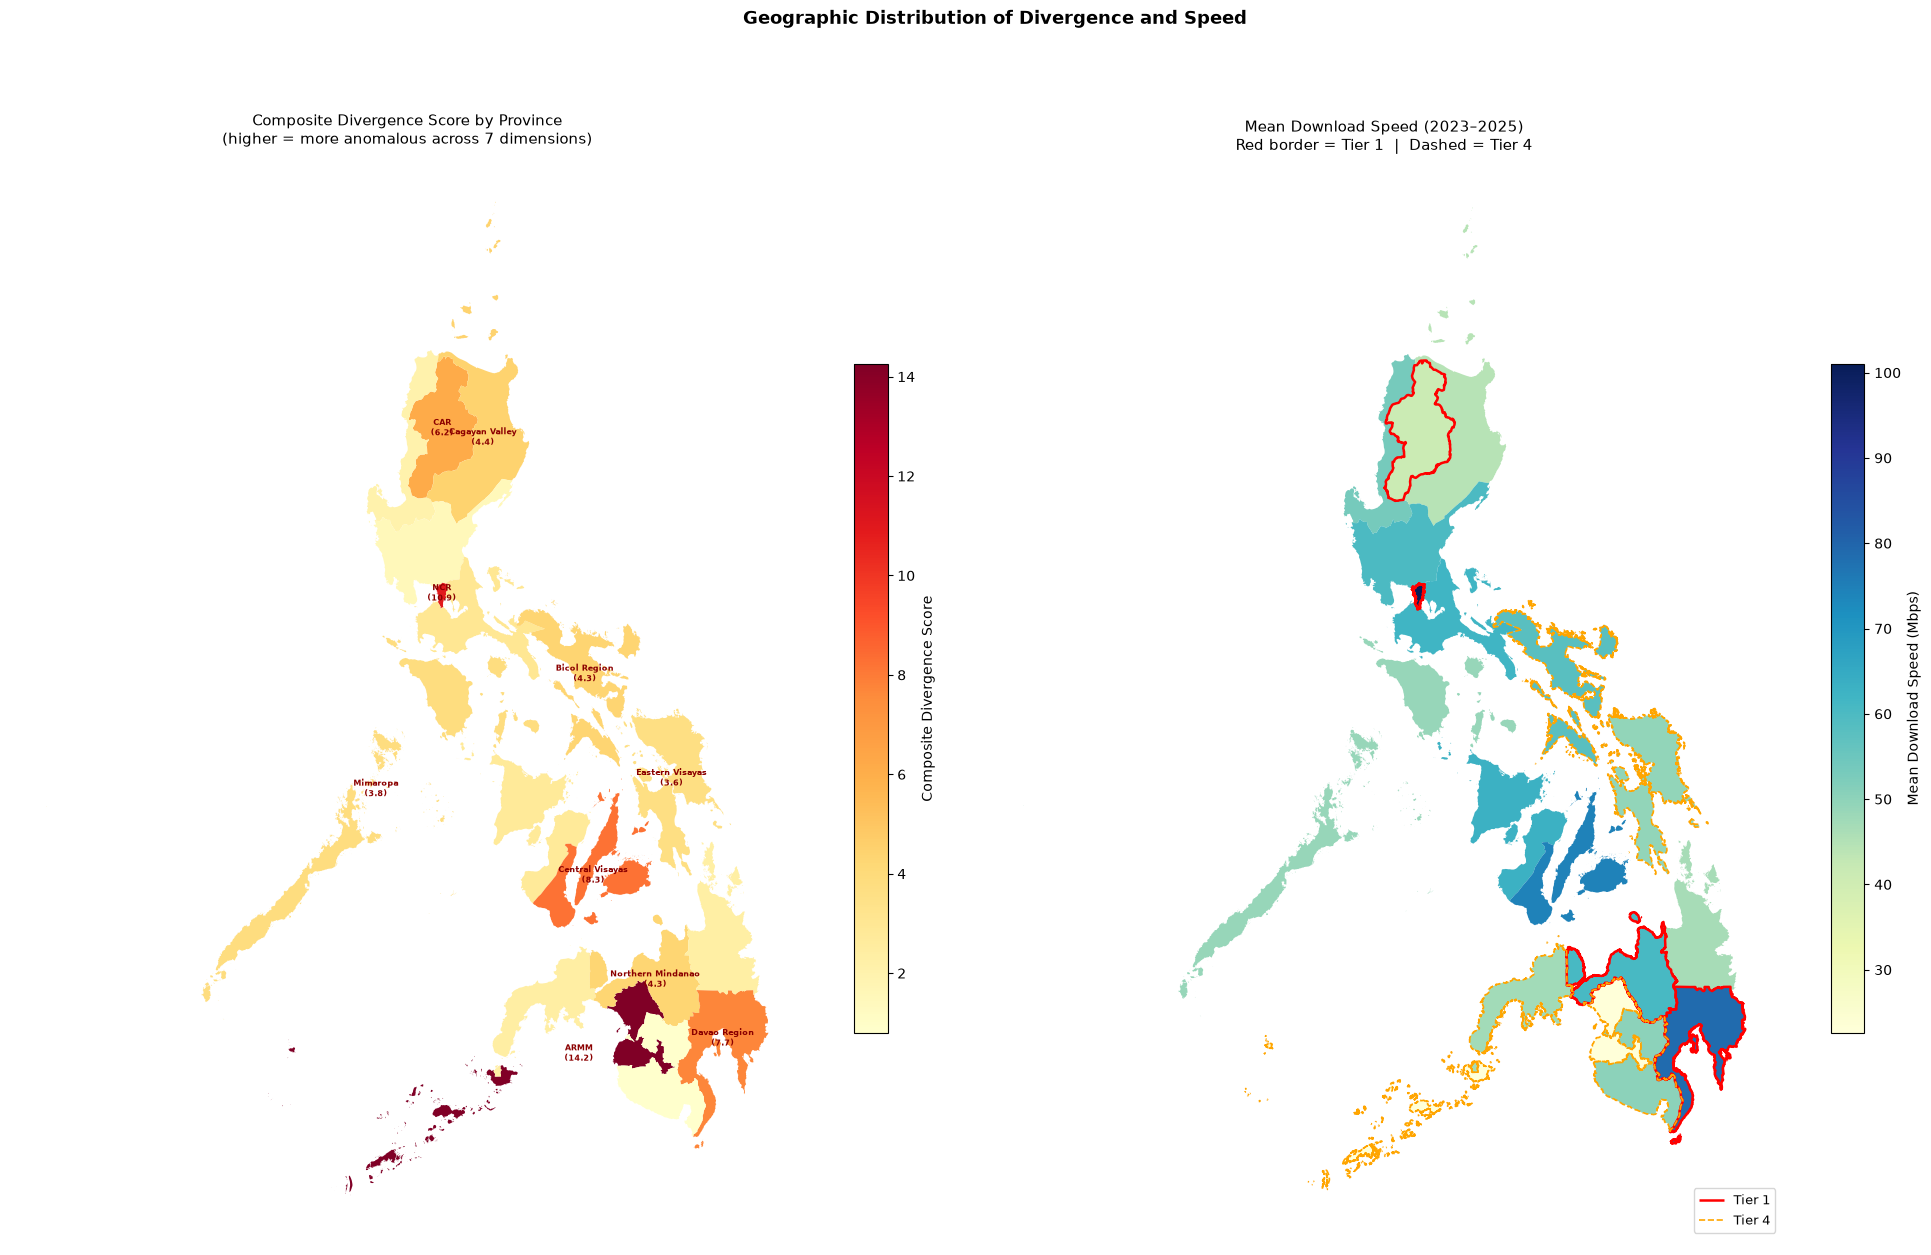

In [72]:
_GEOJSON = '../../data/geo/philippines_provinces.geojson'

# Load GeoDataFrame with correct path (fallback if earlier cells used old path)
try:
    if 'thailand_gdf' not in dir() or thailand_gdf is None:
        raise NameError
    _ = thailand_gdf.shape  # verify it's valid
except (NameError, Exception):
    thailand_gdf = gpd.read_file(_GEOJSON).to_crs(4326)
    print("Loaded thailand_gdf from correct project path")

geo_divergent = thailand_gdf.copy()
geo_divergent = geo_divergent.merge(
    divergent_df[['name','divergence_score','mean_dl','internet_tier']],
    on='name', how='left'
)
geo_divergent['divergence_score'] = geo_divergent['divergence_score'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

# ── Left: divergence score choropleth ──────────────────────────────────────────
ax1 = axes[0]
geo_divergent.plot('divergence_score', ax=ax1, cmap='YlOrRd',
               legend=True, missing_kwds={'color':'lightgray'},
               legend_kwds={'label':'Composite Divergence Score','shrink':0.5})

top10_names = divergent_df.nlargest(10, 'divergence_score')['name'].values
for _, row in geo_divergent.iterrows():
    if row['name'] in top10_names:
        c = row.geometry.centroid
        score = row['divergence_score']
        ax1.annotate(f"{row['name']}\n({score:.1f})",
                     (c.x, c.y), ha='center', va='center',
                     fontsize=5.5, color='darkred', fontweight='bold')

ax1.set_title('Composite Divergence Score by Province\n(higher = more anomalous across 7 dimensions)',
              fontsize=11)
ax1.set_axis_off()

# ── Right: download speed choropleth with tier overlay ────────────────────────
ax2 = axes[1]
geo_divergent.plot('mean_dl', ax=ax2, cmap='YlGnBu',
               legend=True, missing_kwds={'color':'lightgray'},
               legend_kwds={'label':'Mean Download Speed (Mbps)','shrink':0.5})

t1 = geo_divergent[geo_divergent['internet_tier'] == 1]
t1.boundary.plot(ax=ax2, color='red', linewidth=1.8, label='Tier 1')
t4 = geo_divergent[geo_divergent['internet_tier'] == 4]
t4.boundary.plot(ax=ax2, color='orange', linewidth=1.2, ls='--', label='Tier 4')

ax2.legend(fontsize=9, loc='lower right')
ax2.set_title('Mean Download Speed (2023–2025)\nRed border = Tier 1  |  Dashed = Tier 4',
              fontsize=11)
ax2.set_axis_off()

plt.suptitle('Geographic Distribution of Divergence and Speed', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/philippines/mobile/27_divergence_map.png', dpi=150, bbox_inches='tight')
plt.show()


### 24. Why Are They Divergent? — Annotated Province Notes

### 25. Full Province Divergence Table — All Provinces


In [73]:
# ── Merge display name ────────────────────────────────────────────────────────────
full_table = divergent_df.copy()
full_table = full_table.merge(
    prov_ref[['province_en','province_th']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

# ── Generate verdict ───────────────────────────────────────────────────────────
_DIM_ORDER = ['regional_z','gdp_residual_z','den_residual_z','tier_residual_z',
              'ratio_z','lat_regional_z','coverage_z']

def _note(d, v, region, tier):
    if d == 'gdp_residual_z':
        return f"fast for GDP (+{v:.1f}σ)" if v > 0 else f"slow for GDP ({v:.1f}σ)"
    if d == 'den_residual_z':
        return f"fast for density (+{v:.1f}σ)" if v > 0 else f"slow for density ({v:.1f}σ)"
    if d == 'tier_residual_z':
        return f"overperforms Tier {tier} (+{v:.1f}σ)" if v > 0 else f"underperforms Tier {tier} ({v:.1f}σ)"
    if d == 'regional_z':
        return f"fast vs {region} (+{v:.1f}σ)" if v > 0 else f"slow vs {region} ({v:.1f}σ)"
    if d == 'ratio_z':
        return f"symmetric UL/DL (+{v:.1f}σ)" if v > 0 else f"asymmetric UL/DL ({v:.1f}σ)"
    if d == 'lat_regional_z':
        return f"high latency (+{v:.1f}σ)" if v > 0 else f"ultra-low latency ({v:.1f}σ)"
    if d == 'coverage_z':
        return f"over-tested (+{v:.1f}σ)" if v > 0 else f"under-tested ({v:.1f}σ)"
    return f"{d}:{v:.1f}σ"

def make_verdict(r):
    region = r['region']
    tier   = int(r['internet_tier'])
    signals = [(abs(r[d]), d, r[d]) for d in _DIM_ORDER if abs(r[d]) >= 1.0]
    signals.sort(reverse=True)
    if not signals:
        return "unremarkable"
    return " | ".join(_note(d, v, region, tier) for _, d, v in signals[:3])

full_table['verdict'] = full_table.apply(make_verdict, axis=1)

# ── Table 0: Overall ranking (top 20) ─────────────────────────────────────────
from IPython.display import display, HTML

display(HTML("<h3>Overall Divergence Ranking — Top 20</h3>"))
t0 = (full_table.nlargest(20, 'divergence_score')
      [['name','province_th','region','internet_tier','mean_dl','divergence_score','verdict']]
      .rename(columns={'name':'Province','province_th':'Local Name','region':'Region',
                       'internet_tier':'Tier','mean_dl':'DL Mbps','divergence_score':'Score','verdict':'Why Divergent?'})
      .reset_index(drop=True))
t0.index += 1
tier_palette = {1:'#ffcccc', 2:'#ffe4b5', 3:'#d4f0d4', 4:'#dce0f5'}
styled0 = (t0.style
    .background_gradient(subset=['Score'], cmap='YlOrRd', vmin=0, vmax=20)
    .background_gradient(subset=['DL Mbps'], cmap='YlGn', vmin=110, vmax=330)
    .map(lambda v: f"background-color:{tier_palette.get(int(v),'#fff')}", subset=['Tier'])
    .set_properties(**{'font-size':'11px','text-align':'left'})
    .set_properties(subset=['Why Divergent?'], **{'min-width':'320px','font-size':'10px'})
    .set_table_styles([
        {'selector':'th','props':[('background','#f0f0f0'),('font-size','10px'),('padding','4px 6px')]},
        {'selector':'td','props':[('padding','3px 6px'),('border','1px solid #ddd')]},
    ]))
display(styled0)

# ── Tables 1-7: Per-dimension top 8 over / bottom 8 under ─────────────────────
dim_meta = {
    'regional_z':      ('Regional Speed', 'fast vs region peers', 'slow vs region peers'),
    'gdp_residual_z':  ('GDP Gap', 'fast for GDP level', 'slow for GDP level'),
    'den_residual_z':  ('Density Gap', 'fast for density', 'slow for density'),
    'tier_residual_z': ('Tier Gap', 'overperforms tier', 'underperforms tier'),
    'ratio_z':         ('UL/DL Ratio', 'symmetric (fiber)', 'asymmetric (legacy)'),
    'lat_regional_z':  ('Latency (regional)', 'high latency', 'ultra-low latency'),
    'coverage_z':      ('Test Coverage', 'over-tested', 'under-tested'),
}

base_cols = ['name','province_th','region','internet_tier','mean_dl']

for dim, (title, over_label, under_label) in dim_meta.items():
    display(HTML(f"<h3>Dimension: {title} <small style='color:#888'>({dim})</small></h3>"))
    
    sub = full_table[base_cols + [dim, 'divergence_score']].copy()
    sub = sub.rename(columns={
        'name':'Province','province_th':'Local Name','region':'Region',
        'internet_tier':'Tier','mean_dl':'DL Mbps',
        dim:'z-score','divergence_score':'Total Score'
    })
    
    over  = sub.nlargest(8, 'z-score').copy()
    under = sub.nsmallest(8, 'z-score').copy()
    over['signal']  = over_label
    under['signal'] = under_label
    
    combined = pd.concat([over, under], ignore_index=True)
    combined = combined[['Province','Local Name','Region','Tier','DL Mbps','z-score','signal','Total Score']]
    combined['z-score'] = combined['z-score'].round(2)
    combined['DL Mbps'] = combined['DL Mbps'].round(1)
    combined['Total Score'] = combined['Total Score'].round(2)
    
    styled_dim = (combined.style
        .background_gradient(subset=['z-score'], cmap='RdBu_r', vmin=-4, vmax=4)
        .background_gradient(subset=['DL Mbps'], cmap='YlGn', vmin=110, vmax=330)
        .map(lambda v: f"background-color:{tier_palette.get(int(v),'#fff')}", subset=['Tier'])
        .set_properties(**{'font-size':'11px','text-align':'left'})
        .set_table_styles([
            {'selector':'th','props':[('background','#f0f0f0'),('font-size','10px'),('padding','4px 6px')]},
            {'selector':'td','props':[('padding','3px 6px'),('border','1px solid #ddd')]},
        ])
        .hide(axis='index'))
    display(styled_dim)
    display(HTML("<hr style='margin:16px 0'>"))

print(f"Provinces: {len(full_table)}")
print(f"Score range: {full_table['divergence_score'].min():.2f} – {full_table['divergence_score'].max():.2f}")
print(f"|z|>2 in any dim: {(full_table[[*_DIM_ORDER]].abs() >= 2).any(axis=1).sum()}")
print(f"|z|>3 in any dim: {(full_table[[*_DIM_ORDER]].abs() >= 3).any(axis=1).sum()}")
print(f"Unremarkable: {(full_table[[*_DIM_ORDER]].abs() < 1.0).all(axis=1).sum()}")

# Save styled table as HTML
_html_path = '../../outputs/ookla/philippines/mobile/28_divergence_table.html'
with open(_html_path, 'w') as _f:
    _f.write(styled0.to_html())
print(f"Saved: {_html_path}")


,Province,Local Name,Region,Tier,DL Mbps,Score,Why Divergent?
1,ARMM,ARMM,Mindanao,4,22.621783,14.247825,symmetric UL/DL (+3.5σ) | slow for density (-3.1σ) | underperforms Tier 4 (-2.4σ)
2,NCR,NCR,Luzon,1,100.973404,10.945366,over-tested (+3.0σ) | fast vs Luzon (+2.4σ) | overperforms Tier 1 (+2.1σ)
3,Central Visayas,Central Visayas,Visayas,2,74.447938,8.259452,over-tested (+1.6σ) | fast for GDP (+1.4σ) | ultra-low latency (-1.3σ)
4,Davao Region,Davao Region,Mindanao,1,78.925126,7.714538,fast for density (+2.3σ) | fast vs Mindanao (+1.6σ) | fast for GDP (+1.3σ)
5,CAR,CAR,Luzon,1,41.088600,6.199823,slow for GDP (-2.7σ) | underperforms Tier 1 (-1.8σ) | slow vs Luzon (-1.0σ)
6,Cagayan Valley,Cagayan Valley,Luzon,3,44.403067,4.440433,unremarkable
7,Bicol Region,Bicol Region,Luzon,4,58.015404,4.332256,fast for GDP (+1.5σ)
8,Northern Mindanao,Northern Mindanao,Mindanao,1,60.641677,4.297995,ultra-low latency (-1.6σ)
9,Mimaropa,Mimaropa,Luzon,3,48.914224,3.798362,high latency (+1.8σ)
10,Eastern Visayas,Eastern Visayas,Visayas,4,49.490298,3.640662,slow vs Visayas (-1.3σ) | high latency (+1.0σ)


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
NCR,NCR,Luzon,1,101.000000,2.430000,fast vs region peers,10.950000
Davao Region,Davao Region,Mindanao,1,78.900000,1.650000,fast vs region peers,7.710000
Central Visayas,Central Visayas,Visayas,2,74.400000,1.180000,fast vs region peers,8.260000
Northern Mindanao,Northern Mindanao,Mindanao,1,60.600000,0.570000,fast vs region peers,4.300000
Calabarzon,Calabarzon,Luzon,2,61.800000,0.190000,fast vs region peers,3.030000
Western Visayas,Western Visayas,Visayas,2,63.300000,0.090000,fast vs region peers,2.770000
Central Luzon,Central Luzon,Luzon,2,60.000000,0.080000,fast vs region peers,1.500000
Bicol Region,Bicol Region,Luzon,4,58.000000,-0.030000,fast vs region peers,4.330000
ARMM,ARMM,Mindanao,4,22.600000,-1.690000,slow vs region peers,14.250000
Eastern Visayas,Eastern Visayas,Visayas,4,49.500000,-1.270000,slow vs region peers,3.640000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Bicol Region,Bicol Region,Luzon,4,58.000000,1.540000,fast for GDP level,4.330000
Central Visayas,Central Visayas,Visayas,2,74.400000,1.430000,fast for GDP level,8.260000
Davao Region,Davao Region,Mindanao,1,78.900000,1.330000,fast for GDP level,7.710000
Western Visayas,Western Visayas,Visayas,2,63.300000,1.010000,fast for GDP level,2.770000
Eastern Visayas,Eastern Visayas,Visayas,4,49.500000,0.530000,fast for GDP level,3.640000
NCR,NCR,Luzon,1,101.000000,0.480000,fast for GDP level,10.950000
Soccsksargen,Soccsksargen,Mindanao,4,50.400000,0.060000,fast for GDP level,0.800000
Ilocos Region,Ilocos Region,Luzon,3,53.400000,0.030000,fast for GDP level,2.030000
CAR,CAR,Luzon,1,41.100000,-2.680000,slow for GDP level,6.200000
Cagayan Valley,Cagayan Valley,Luzon,3,44.400000,-0.770000,slow for GDP level,4.440000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Davao Region,Davao Region,Mindanao,1,78.900000,2.270000,fast for density,7.710000
Central Visayas,Central Visayas,Visayas,2,74.400000,0.960000,fast for density,8.260000
Northern Mindanao,Northern Mindanao,Mindanao,1,60.600000,0.690000,fast for density,4.300000
Western Visayas,Western Visayas,Visayas,2,63.300000,0.480000,fast for density,2.770000
Mimaropa,Mimaropa,Luzon,3,48.900000,0.410000,fast for density,3.800000
Bicol Region,Bicol Region,Luzon,4,58.000000,0.150000,fast for density,4.330000
NCR,NCR,Luzon,1,101.000000,0.130000,fast for density,10.950000
Caraga,Caraga,Mindanao,3,46.600000,0.020000,fast for density,2.370000
ARMM,ARMM,Mindanao,4,22.600000,-3.060000,slow for density,14.250000
Ilocos Region,Ilocos Region,Luzon,3,53.400000,-0.440000,slow for density,2.030000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
NCR,NCR,Luzon,1,101.000000,2.060000,overperforms tier,10.950000
Central Visayas,Central Visayas,Visayas,2,74.400000,0.900000,overperforms tier,8.260000
Bicol Region,Bicol Region,Luzon,4,58.000000,0.820000,overperforms tier,4.330000
Davao Region,Davao Region,Mindanao,1,78.900000,0.630000,overperforms tier,7.710000
Ilocos Region,Ilocos Region,Luzon,3,53.400000,0.580000,overperforms tier,2.030000
Mimaropa,Mimaropa,Luzon,3,48.900000,0.150000,overperforms tier,3.800000
Soccsksargen,Soccsksargen,Mindanao,4,50.400000,0.130000,overperforms tier,0.800000
Western Visayas,Western Visayas,Visayas,2,63.300000,0.100000,overperforms tier,2.770000
ARMM,ARMM,Mindanao,4,22.600000,-2.410000,underperforms tier,14.250000
CAR,CAR,Luzon,1,41.100000,-1.810000,underperforms tier,6.200000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
ARMM,ARMM,Mindanao,4,22.600000,3.450000,symmetric (fiber),14.250000
Cagayan Valley,Cagayan Valley,Luzon,3,44.400000,0.880000,symmetric (fiber),4.440000
Caraga,Caraga,Mindanao,3,46.600000,0.500000,symmetric (fiber),2.370000
Mimaropa,Mimaropa,Luzon,3,48.900000,0.150000,symmetric (fiber),3.800000
Soccsksargen,Soccsksargen,Mindanao,4,50.400000,0.090000,symmetric (fiber),0.800000
Zamboanga Peninsula,Zamboanga Peninsula,Mindanao,4,47.300000,0.090000,symmetric (fiber),2.390000
CAR,CAR,Luzon,1,41.100000,0.080000,symmetric (fiber),6.200000
Ilocos Region,Ilocos Region,Luzon,3,53.400000,0.050000,symmetric (fiber),2.030000
NCR,NCR,Luzon,1,101.000000,-1.060000,asymmetric (legacy),10.950000
Central Visayas,Central Visayas,Visayas,2,74.400000,-0.840000,asymmetric (legacy),8.260000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Mimaropa,Mimaropa,Luzon,3,48.900000,1.750000,high latency,3.800000
ARMM,ARMM,Mindanao,4,22.600000,1.630000,high latency,14.250000
Eastern Visayas,Eastern Visayas,Visayas,4,49.500000,1.040000,high latency,3.640000
Cagayan Valley,Cagayan Valley,Luzon,3,44.400000,0.810000,high latency,4.440000
Bicol Region,Bicol Region,Luzon,4,58.000000,0.570000,high latency,4.330000
Zamboanga Peninsula,Zamboanga Peninsula,Mindanao,4,47.300000,0.350000,high latency,2.390000
Western Visayas,Western Visayas,Visayas,2,63.300000,0.300000,high latency,2.770000
Caraga,Caraga,Mindanao,3,46.600000,0.270000,high latency,2.370000
NCR,NCR,Luzon,1,101.000000,-1.760000,ultra-low latency,10.950000
Northern Mindanao,Northern Mindanao,Mindanao,1,60.600000,-1.590000,ultra-low latency,4.300000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
NCR,NCR,Luzon,1,101.000000,3.030000,over-tested,10.950000
Central Visayas,Central Visayas,Visayas,2,74.400000,1.600000,over-tested,8.260000
Calabarzon,Calabarzon,Luzon,2,61.800000,0.640000,over-tested,3.030000
CAR,CAR,Luzon,1,41.100000,0.390000,over-tested,6.200000
Davao Region,Davao Region,Mindanao,1,78.900000,0.240000,over-tested,7.710000
Central Luzon,Central Luzon,Luzon,2,60.000000,0.240000,over-tested,1.500000
Western Visayas,Western Visayas,Visayas,2,63.300000,-0.190000,over-tested,2.770000
Northern Mindanao,Northern Mindanao,Mindanao,1,60.600000,-0.220000,over-tested,4.300000
ARMM,ARMM,Mindanao,4,22.600000,-1.370000,under-tested,14.250000
Zamboanga Peninsula,Zamboanga Peninsula,Mindanao,4,47.300000,-0.780000,under-tested,2.390000


Provinces: 17
Score range: 0.80 – 14.25
|z|>2 in any dim: 4
|z|>3 in any dim: 2
Unremarkable: 7
Saved: ../../outputs/ookla/philippines/mobile/28_divergence_table.html


## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [74]:
# ── Export Ookla Mobile quarterly province data for comparison notebook ──
import os
os.makedirs("../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../data/exports/ookla_mobile_philippines_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows → {PATH}")
print(out.head(3).to_string())


Exported 204 rows → ../../data/exports/ookla_mobile_philippines_province_quarterly.csv
       province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable    region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0          ARMM  2023-Q1  2023        1   14.821823    7.024484      54.088790       6048.0    663.0         True  Mindanao              4   4545486                 91028.33              330
1  Bicol Region  2023-Q1  2023        1   47.660622    9.692321      34.937163      20052.0   2641.0         True     Luzon              4   6064426                142596.80              319
2           CAR  2023-Q1  2023        1   28.966911    7.464564      29.352210      10860.0   1001.0         True     Luzon              1   1808985                295236.64               89
